# Knowledge Tracing Model Comparison on the Riiid Dataset

This notebook builds and evaluates Bayesian Knowledge Tracing (BKT), canonical Deep Knowledge Tracing (DKT), and canonical Self-Attentive Knowledge Tracing (SAKT) on a reproducible sample of the Riiid Answer Correctness Prediction dataset. DKT selects the output associated with the next skill, while SAKT uses the next skill as its attention query. The workflow uses learner-separated data partitions and next-response targets throughout.


In [6]:
import gc
import itertools
import os
import random
import shutil
import sys
import warnings
from importlib.metadata import version
from pathlib import Path
from zipfile import ZipFile

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import seaborn as sns
import sklearn
import tensorflow as tf
from kaggle.api.kaggle_api_extended import KaggleApi
from pyBKT.fit import E_step
from pyBKT.models import Model as BKTModel
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import (
    Add,
    Dense,
    Dropout,
    Embedding,
    Input,
    Layer,
    LayerNormalization,
    LSTM,
    MultiHeadAttention,
)
from tensorflow.keras.models import Model as KerasModel
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.sequence import pad_sequences


In [7]:
warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 42
TARGET_STUDENTS = 20_000
FINAL_MODEL_SEEDS = [42, 43, 44]

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

expected_versions = {
    "numpy": "1.26.4",
    "pandas": "2.2.3",
    "scipy": "1.13.1",
    "scikit-learn": "1.6.1",
    "pyBKT": "1.4.2",
}

installed_versions = {
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scipy": scipy.__version__,
    "scikit-learn": sklearn.__version__,
    "pyBKT": version("pyBKT"),
    "tensorflow": tf.__version__,
}

incorrect_versions = {
    package: (expected, installed_versions[package])
    for package, expected in expected_versions.items()
    if installed_versions[package] != expected
}

if incorrect_versions:
    raise RuntimeError(f"Unexpected package versions: {incorrect_versions}")

if Path(E_step.__file__).suffix != ".so":
    raise RuntimeError("The compiled pyBKT backend is required.")

PROJECT_ROOT = (
    Path.cwd().parent
    if Path.cwd().name == "notebooks"
    else Path.cwd()
)
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
TABLES_DIR = RESULTS_DIR / "tables"
PREDICTIONS_DIR = RESULTS_DIR / "predictions"
MODELS_DIR = PROJECT_ROOT / "models"

for directory in (
    RAW_DATA_DIR,
    PROCESSED_DATA_DIR,
    FIGURES_DIR,
    TABLES_DIR,
    PREDICTIONS_DIR,
    MODELS_DIR,
):
    directory.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = RAW_DATA_DIR / "train.csv"
QUESTIONS_PATH = RAW_DATA_DIR / "questions.csv"

print("Environment validated and project directories configured.")
print("Results directory:", RESULTS_DIR)
print("pyBKT backend:", Path(E_step.__file__).name)


Environment validated and project directories configured.
Results directory: /Users/tolulopesoetan/Desktop/msc_kt_ednet/results
pyBKT backend: E_step.cpython-312-darwin.so


## Data Access

The competition files are downloaded only when they are absent from `data/raw`. Kaggle credentials must be stored in `~/.kaggle/kaggle.json` or downloaded to the user's Downloads directory.


In [3]:
downloaded_kaggle_json = Path.home() / "Downloads" / "kaggle.json"
kaggle_directory = Path.home() / ".kaggle"
kaggle_json_path = kaggle_directory / "kaggle.json"

kaggle_directory.mkdir(exist_ok=True)

if downloaded_kaggle_json.exists() and not kaggle_json_path.exists():
    shutil.copy2(downloaded_kaggle_json, kaggle_json_path)

if not kaggle_json_path.exists():
    raise FileNotFoundError(
        "Download kaggle.json from Kaggle Settings and rerun this cell."
    )

os.chmod(kaggle_json_path, 0o600)

print("Kaggle API credentials configured.")


Kaggle API credentials configured.


In [4]:
if not TRAIN_PATH.exists() or not QUESTIONS_PATH.exists():
    api = KaggleApi()
    api.authenticate()

    api.competition_download_files(
        "riiid-test-answer-prediction",
        path=RAW_DATA_DIR,
        quiet=False,
    )

    archive_path = RAW_DATA_DIR / "riiid-test-answer-prediction.zip"

    if not archive_path.exists():
        raise FileNotFoundError("The Kaggle archive was not downloaded.")

    with ZipFile(archive_path, "r") as archive:
        archive.extractall(RAW_DATA_DIR)

print(f"Raw data available in: {RAW_DATA_DIR}")


Raw data available in: /Users/tolulopesoetan/Desktop/msc_kt_ednet/data/raw


In [5]:
required_files = {
    "training interactions": TRAIN_PATH,
    "question metadata": QUESTIONS_PATH,
}

missing_files = {
    name: path
    for name, path in required_files.items()
    if not path.exists()
}

if missing_files:
    for name, path in missing_files.items():
        print(f"Missing {name}: {path}")

    raise FileNotFoundError(
        "Required Riiid files are missing from data/raw."
    )

print("Environment and data paths configured.")


Environment and data paths configured.


## Data Preparation


In [6]:
print("Scanning unique students.")

all_users = (
    pd.read_csv(TRAIN_PATH, usecols=["user_id"])
    .squeeze("columns")
    .unique()
)

rng = np.random.default_rng(SEED)

sampled_users = rng.choice(
    all_users,
    size=TARGET_STUDENTS,
    replace=False,
)

print(f"Successfully sampled {len(sampled_users):,} students.")


Scanning unique students.
Successfully sampled 20,000 students.


In [7]:
print("Extracting interactions for the selected students.")

columns_to_load = [
    "user_id",
    "content_id",
    "answered_correctly",
    "content_type_id",
    "timestamp",
]

filtered_chunks = []

for chunk in pd.read_csv(
    TRAIN_PATH,
    usecols=columns_to_load,
    chunksize=1_000_000,
):
    filtered_chunk = chunk[
        (chunk["content_type_id"] == 0)
        & (chunk["user_id"].isin(sampled_users))
    ]

    filtered_chunks.append(filtered_chunk)

final_df = pd.concat(filtered_chunks, ignore_index=True)
final_df = final_df.drop(columns=["content_type_id"])

del filtered_chunks, all_users
gc.collect()

print(f"Total interactions loaded: {len(final_df):,}")


Extracting interactions for the selected students.
Total interactions loaded: 5,033,866


In [8]:
questions_raw = pd.read_csv(
    QUESTIONS_PATH,
    usecols=["question_id", "tags", "part"],
)

questions_raw["tags"] = questions_raw["tags"].fillna("-1")
questions_raw["tag_list"] = (
    questions_raw["tags"]
    .astype(str)
    .str.split(" ")
)

exploded_tags = questions_raw.explode("tag_list")
exploded_tags = exploded_tags[
    exploded_tags["tag_list"] != "-1"
]

exploded_tags["tag_list"] = (
    exploded_tags["tag_list"].astype(int)
)

unique_tags = exploded_tags["tag_list"].nunique()

questions_raw["tag_count"] = (
    questions_raw["tag_list"].apply(len)
)

print(f"Unique skill tags in Riiid questions.csv: {unique_tags}")
print()
print("Tags per question:")
print(
    questions_raw["tag_count"]
    .value_counts()
    .sort_index()
    .to_string()
)


Unique skill tags in Riiid questions.csv: 188

Tags per question:
tag_count
1    6561
2     171
3    3976
4    2021
5     686
6     108


In [9]:
questions_df = questions_raw[
    ["question_id", "part", "tags"]
].copy()

questions_df["tag_1"] = (
    questions_df["tags"]
    .astype(str)
    .str.split(" ")
    .str[0]
)

questions_df = questions_df.drop(columns=["tags"])

print("Question metadata prepared.")


Question metadata prepared.


In [10]:
print("Merging skill metadata into student interactions.")

final_df = final_df.merge(
    questions_df,
    left_on="content_id",
    right_on="question_id",
    how="left",
)

final_df = final_df.drop(columns=["question_id"])

del questions_df, questions_raw, exploded_tags
gc.collect()

print("Metadata merge complete.")


Merging skill metadata into student interactions.
Metadata merge complete.


In [11]:
print("Sorting student sequences chronologically.")

final_df = final_df.sort_values(
    by=["user_id", "timestamp"]
).reset_index(drop=True)

label_encoder = LabelEncoder()

final_df["skill"] = label_encoder.fit_transform(
    final_df["tag_1"]
)

num_skills = final_df["skill"].nunique()

print(f"Total unique skills to model: {num_skills}")


Sorting student sequences chronologically.
Total unique skills to model: 117


In [12]:
print("\n--- Pipeline Data Summary ---")
print(f"Total Students: {final_df['user_id'].nunique():,}")
print(f"Total Valid Interactions: {len(final_df):,}")
print(
    "Max Sequence Length Found:",
    final_df.groupby("user_id").size().max(),
)
print(f"Total Distinct Skills (tag_1): {num_skills}")
print("\nPreview:")

display(final_df.head())



--- Pipeline Data Summary ---
Total Students: 20,000
Total Valid Interactions: 5,033,866
Max Sequence Length Found: 14855
Total Distinct Skills (tag_1): 117

Preview:


,timestamp,user_id,content_id,answered_correctly,part,tag_1,skill
0,0,115,5692,1,5,151,31
1,56943,115,5716,1,5,168,42
2,118363,115,128,1,1,131,18
3,131167,115,7860,1,1,131,18
4,137965,115,7922,1,1,131,18


## Student-Level Train/Test Split


In [13]:
print("Splitting data by student.")

group_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=SEED,
)

train_idx, test_idx = next(
    group_split.split(
        final_df,
        groups=final_df["user_id"],
    )
)

train_df = final_df.iloc[train_idx].copy()
test_df = final_df.iloc[test_idx].copy()

print(f"Training students: {train_df['user_id'].nunique():,}")
print(f"Testing students: {test_df['user_id'].nunique():,}")


Splitting data by student.
Training students: 16,000
Testing students: 4,000


## Bayesian Knowledge Tracing Baseline


In [14]:
bkt_train = train_df[
    ["user_id", "tag_1", "answered_correctly"]
].rename(
    columns={
        "tag_1": "skill_name",
        "answered_correctly": "correct",
    }
)

bkt_model = BKTModel(seed=SEED)

print("Training BKT baseline model.")
bkt_model.fit(data=bkt_train)
print("BKT training complete.")


Training BKT baseline model.
BKT training complete.


In [15]:
bkt_test = test_df[
    ["user_id", "tag_1", "answered_correctly"]
].rename(
    columns={
        "tag_1": "skill_name",
        "answered_correctly": "correct",
    }
)

print("Predicting with BKT on the test set.")

bkt_preds = bkt_model.predict(data=bkt_test)

missing_predictions = (
    bkt_preds["correct_predictions"].isna().sum()
)

if missing_predictions:
    raise RuntimeError(
        f"BKT produced {missing_predictions:,} missing predictions."
    )

bkt_auc = roc_auc_score(
    bkt_preds["correct"],
    bkt_preds["correct_predictions"],
)

print(f"BKT Test AUC: {bkt_auc:.4f}")


Predicting with BKT on the test set.
BKT Test AUC: 0.6300


## Canonical Deep Knowledge Tracing Baseline

Each timestep contains a completed skill-response interaction and the skill of the response being predicted. The LSTM produces a probability for every skill, and the probability associated with the next skill is selected as the next-response prediction. Sequences retain the 100 most recent interactions.


In [16]:
MAX_SEQ_LEN = 100


def create_sequence_data(data, max_length):
    skills = []
    correctness = []
    users = []

    for user_id, user_data in data.groupby("user_id", sort=False):
        skill_sequence = user_data["skill"].to_numpy()
        response_sequence = user_data["answered_correctly"].to_numpy()

        if len(skill_sequence) < 2:
            continue

        skill_sequence = skill_sequence[-max_length:]
        response_sequence = response_sequence[-max_length:]

        skills.append(skill_sequence)
        correctness.append(response_sequence)
        users.append(user_id)

    return skills, correctness, users


def masked_binary_crossentropy(y_true, y_pred):
    y_true_float = tf.cast(y_true, y_pred.dtype)
    valid_targets = tf.maximum(y_true_float, 0.0)
    loss = tf.keras.losses.binary_crossentropy(
        valid_targets,
        y_pred,
    )
    mask = tf.cast(
        tf.not_equal(y_true_float, -1.0),
        dtype=tf.float32,
    )
    mask = tf.squeeze(mask, axis=-1)
    return tf.reduce_sum(loss * mask) / (
        tf.reduce_sum(mask) + 1e-8
    )


class SelectSkillProbability(Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.supports_masking = True

    def call(self, inputs):
        all_skill_probabilities, target_skill_tokens = inputs
        target_skill_indices = tf.maximum(
            target_skill_tokens - 1,
            0,
        )
        selected_probabilities = tf.gather(
            all_skill_probabilities,
            target_skill_indices,
            axis=2,
            batch_dims=2,
        )
        return tf.expand_dims(selected_probabilities, axis=-1)

    def compute_mask(self, inputs, mask=None):
        # The custom loss excludes targets padded with -1. The upstream mask
        # has already protected the recurrent states and is intentionally
        # consumed at this final selection layer.
        return None


print("Sequence extraction and masked objective configured.")


Sequence extraction and masked objective configured.


In [17]:
print("Building historical interactions, target skills and responses.")

sequence_skills, sequence_responses, sequence_users = create_sequence_data(
    final_df,
    MAX_SEQ_LEN,
)

interaction_sequences = []
target_skill_sequences = []
target_response_sequences = []

for skill_sequence, response_sequence in zip(
    sequence_skills,
    sequence_responses,
):
    historical_skills = skill_sequence[:-1]
    historical_responses = response_sequence[:-1]

    interaction_tokens = (
        historical_skills * 2
        + historical_responses
        + 1
    )

    interaction_sequences.append(interaction_tokens)
    target_skill_sequences.append(skill_sequence[1:] + 1)
    target_response_sequences.append(response_sequence[1:])

X = pad_sequences(
    interaction_sequences,
    maxlen=MAX_SEQ_LEN,
    padding="pre",
    value=0,
)

Q = pad_sequences(
    target_skill_sequences,
    maxlen=MAX_SEQ_LEN,
    padding="pre",
    value=0,
)

y = pad_sequences(
    target_response_sequences,
    maxlen=MAX_SEQ_LEN,
    padding="pre",
    value=-1,
)

if not np.array_equal(X != 0, Q != 0):
    raise ValueError("Historical and target-skill padding is not aligned.")

print(f"Interaction tensor shape: {X.shape}")
print(f"Target-skill tensor shape: {Q.shape}")
print(f"Target-response tensor shape: {y.shape}")


Building historical interactions, target skills and responses.
Interaction tensor shape: (19999, 100)
Target-skill tensor shape: (19999, 100)
Target-response tensor shape: (19999, 100)


In [18]:
sequence_users = np.asarray(sequence_users)

training_users = train_df["user_id"].unique()
testing_users = test_df["user_id"].unique()

train_mask = np.isin(sequence_users, training_users)
test_mask = np.isin(sequence_users, testing_users)

X_train = X[train_mask]
Q_train = Q[train_mask]
y_train = y[train_mask]

X_test = X[test_mask]
Q_test = Q[test_mask]
y_test = y[test_mask]

print(f"Neural training learners: {X_train.shape[0]:,}")
print(f"Neural testing learners: {X_test.shape[0]:,}")


Neural training learners: 15,999
Neural testing learners: 4,000


In [19]:
vocab_size = (num_skills * 2) + 1
target_skill_vocab_size = num_skills + 1


def build_dkt_model(
    configuration,
    sequence_length,
    number_of_skills,
    interaction_vocab_size,
    name_prefix="dkt",
):
    interaction_inputs = Input(
        shape=(sequence_length,),
        dtype="int32",
        name=f"{name_prefix}_interactions",
    )
    target_skill_inputs = Input(
        shape=(sequence_length,),
        dtype="int32",
        name=f"{name_prefix}_target_skills",
    )

    interaction_embeddings = Embedding(
        input_dim=interaction_vocab_size,
        output_dim=configuration["embedding_dimension"],
        mask_zero=True,
        name=f"{name_prefix}_interaction_embedding",
    )(interaction_inputs)

    knowledge_states = LSTM(
        units=configuration["lstm_units"],
        return_sequences=True,
        name=f"{name_prefix}_knowledge_state",
    )(interaction_embeddings)

    all_skill_probabilities = Dense(
        units=number_of_skills,
        activation="sigmoid",
        name=f"{name_prefix}_all_skill_probabilities",
    )(knowledge_states)

    selected_probabilities = SelectSkillProbability(
        name=f"{name_prefix}_selected_skill_probability"
    )([
        all_skill_probabilities,
        target_skill_inputs,
    ])

    model = KerasModel(
        inputs=[interaction_inputs, target_skill_inputs],
        outputs=selected_probabilities,
        name=f"{name_prefix}_canonical_dkt",
    )
    model.compile(
        optimizer=Adam(
            learning_rate=configuration["learning_rate"]
        ),
        loss=masked_binary_crossentropy,
    )
    return model


baseline_dkt_configuration = {
    "embedding_dimension": 64,
    "lstm_units": 64,
    "learning_rate": 1e-3,
}

dkt_model = build_dkt_model(
    baseline_dkt_configuration,
    sequence_length=MAX_SEQ_LEN,
    number_of_skills=num_skills,
    interaction_vocab_size=vocab_size,
    name_prefix="preliminary_dkt",
)
dkt_model.summary()


Model: "preliminary_dkt_canonical_dkt"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ preliminary_dkt_in… │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ preliminary_dkt_in… │ (None, 100, 64)   │     15,040 │ preliminary_dkt_… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 100)       │          0 │ preliminary_dkt_… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ preliminary_dkt_kn… │ (None, 100, 64)   │     33,024 │ preliminary_dkt_… │
│ (LSTM)              │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ preliminary_dkt_al… │ (None, 100, 117)  │      7,605 │ preliminary_dkt_… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ preliminary_dkt_ta… │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ preliminary_dkt_se… │ (None, 100, 1)    │          0 │ preliminary_dkt_… │
│ (SelectSkillProbab… │                   │            │ preliminary_dkt_… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 55,669 (217.46 KB)

 Trainable params: 55,669 (217.46 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
print(f"Initial y_train shape: {y_train.shape}")

if y_train.ndim == 2:
    y_train = np.expand_dims(y_train, axis=-1)
    y_test = np.expand_dims(y_test, axis=-1)

print(f"Updated y_train shape: {y_train.shape}")


Initial y_train shape: (15999, 100)
Updated y_train shape: (15999, 100, 1)


In [21]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=3,
    restore_best_weights=True,
)

print("Training canonical DKT.")

dkt_history = dkt_model.fit(
    [X_train, Q_train],
    y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stopping],
    verbose=1,
)

print("Evaluating canonical DKT.")
dkt_predictions = dkt_model.predict(
    [X_test, Q_test],
    verbose=0,
)

valid_sequence_mask = y_test[:, :, 0] != -1
y_test_clean = y_test[:, :, 0][valid_sequence_mask]
dkt_predictions_clean = dkt_predictions[:, :, 0][
    valid_sequence_mask
]

dkt_auc = roc_auc_score(
    y_test_clean,
    dkt_predictions_clean,
)

print(f"BKT baseline AUC: {bkt_auc:.4f}")
print(f"Canonical DKT AUC: {dkt_auc:.4f}")


Training canonical DKT.
Epoch 1/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - loss: 0.6420 - val_loss: 0.6307
Epoch 2/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - loss: 0.6288 - val_loss: 0.6286
Epoch 3/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - loss: 0.6271 - val_loss: 0.6277
Epoch 4/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 0.6260 - val_loss: 0.6273
Epoch 5/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 0.6251 - val_loss: 0.6273
Epoch 6/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - loss: 0.6241 - val_loss: 0.6272
Epoch 7/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - loss: 0.6232 - val_loss: 0.6267
Epoch 8/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 0.6222 - val_loss: 0.6262
Epoch 9/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - loss: 0.6214 - val_loss: 0.6258
Epoch 10/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 0.6205 - val_loss: 0.6256
Epoch 11/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 0.6197 - val_loss: 0.6255
Epoch 12/15
225/2

## Initial SAKT Mask Diagnostic

SAKT represents each completed skill-response pair as a key/value and the next skill as the query. An upper-triangular prototype is retained only to demonstrate how an incorrectly oriented attention mask exposes interactions from later positions.


In [22]:
tf.keras.backend.clear_session()
del dkt_model
gc.collect()

print("DKT model memory released.")


DKT model memory released.


In [23]:
class UpperTriangularAttentionMask(Layer):
    def call(self, interaction_tokens):
        sequence_length = tf.shape(interaction_tokens)[1]
        future_mask = tf.linalg.band_part(
            tf.ones(
                (sequence_length, sequence_length),
                dtype=tf.bool,
            ),
            0,
            -1,
        )
        valid_keys = tf.not_equal(interaction_tokens, 0)
        valid_keys = tf.expand_dims(valid_keys, axis=1)
        return tf.logical_and(
            tf.expand_dims(future_mask, axis=0),
            valid_keys,
        )


class CausalPaddingMask(Layer):
    def call(self, interaction_tokens):
        sequence_length = tf.shape(interaction_tokens)[1]
        causal_mask = tf.linalg.band_part(
            tf.ones(
                (sequence_length, sequence_length),
                dtype=tf.bool,
            ),
            -1,
            0,
        )
        valid_keys = tf.not_equal(interaction_tokens, 0)
        valid_keys = tf.expand_dims(valid_keys, axis=1)
        return tf.logical_and(
            tf.expand_dims(causal_mask, axis=0),
            valid_keys,
        )


class FeedForwardNetwork(Layer):
    def __init__(
        self,
        model_dimension,
        hidden_dimension,
        dropout_rate=0.1,
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.hidden_layer = Dense(
            hidden_dimension,
            activation="relu",
        )
        self.output_layer = Dense(model_dimension)
        self.dropout = Dropout(dropout_rate)

    def call(self, inputs, training=False):
        x = self.hidden_layer(inputs)
        x = self.dropout(x, training=training)
        return self.output_layer(x)


def build_sakt_model(
    configuration,
    sequence_length,
    number_of_skills,
    interaction_vocab_size,
    causal=True,
    name_prefix="sakt",
):
    model_dimension = configuration["embedding_dimension"]

    interaction_inputs = Input(
        shape=(sequence_length,),
        dtype="int32",
        name=f"{name_prefix}_interactions",
    )
    target_skill_inputs = Input(
        shape=(sequence_length,),
        dtype="int32",
        name=f"{name_prefix}_target_skills",
    )

    interaction_embeddings = Embedding(
        input_dim=interaction_vocab_size,
        output_dim=model_dimension,
        mask_zero=False,
        name=f"{name_prefix}_interaction_embedding",
    )(interaction_inputs)

    target_skill_embeddings = Embedding(
        input_dim=number_of_skills + 1,
        output_dim=model_dimension,
        mask_zero=False,
        name=f"{name_prefix}_target_skill_embedding",
    )(target_skill_inputs)

    positions = tf.range(sequence_length)
    position_embeddings = Embedding(
        input_dim=sequence_length,
        output_dim=model_dimension,
        name=f"{name_prefix}_position_embedding",
    )(positions)

    interaction_state = interaction_embeddings + position_embeddings
    query_state = target_skill_embeddings + position_embeddings

    mask_layer = (
        CausalPaddingMask
        if causal
        else UpperTriangularAttentionMask
    )
    attention_mask = mask_layer(
        name=f"{name_prefix}_attention_mask"
    )(interaction_inputs)

    attention_output = MultiHeadAttention(
        num_heads=configuration["attention_heads"],
        key_dim=max(
            1,
            model_dimension // configuration["attention_heads"],
        ),
        name=f"{name_prefix}_attention",
    )(
        query=query_state,
        value=interaction_state,
        key=interaction_state,
        attention_mask=attention_mask,
    )

    model_state = LayerNormalization(
        epsilon=1e-6,
        name=f"{name_prefix}_attention_normalisation",
    )(Add(name=f"{name_prefix}_attention_residual")([
        query_state,
        attention_output,
    ]))

    feedforward_output = FeedForwardNetwork(
        model_dimension=model_dimension,
        hidden_dimension=configuration["feedforward_dimension"],
        name=f"{name_prefix}_feedforward",
    )(model_state)

    model_state = LayerNormalization(
        epsilon=1e-6,
        name=f"{name_prefix}_feedforward_normalisation",
    )(Add(name=f"{name_prefix}_feedforward_residual")([
        model_state,
        feedforward_output,
    ]))

    probabilities = Dense(
        1,
        activation="sigmoid",
        name=f"{name_prefix}_correctness_probability",
    )(model_state)

    model = KerasModel(
        inputs=[interaction_inputs, target_skill_inputs],
        outputs=probabilities,
        name=(
            f"{name_prefix}_canonical_sakt"
            if causal
            else f"{name_prefix}_noncausal_sakt"
        ),
    )
    model.compile(
        optimizer=Adam(
            learning_rate=configuration["learning_rate"]
        ),
        loss=masked_binary_crossentropy,
    )
    return model


print("Canonical SAKT components defined.")


Canonical SAKT components defined.


In [24]:
baseline_sakt_configuration = {
    "embedding_dimension": 64,
    "attention_heads": 4,
    "feedforward_dimension": 128,
    "learning_rate": 1e-3,
}

initial_sakt_model = build_sakt_model(
    baseline_sakt_configuration,
    sequence_length=MAX_SEQ_LEN,
    number_of_skills=num_skills,
    interaction_vocab_size=vocab_size,
    causal=False,
    name_prefix="noncausal_diagnostic",
)
initial_sakt_model.summary()


Model: "noncausal_diagnostic_noncausal_sakt"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ noncausal_diagnost… │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ noncausal_diagnost… │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ noncausal_diagnost… │ (None, 100, 64)   │      7,552 │ noncausal_diagno… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ noncausal_diagnost… │ (None, 100, 64)   │     15,040 │ noncausal_diagno… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 100, 64)   │          0 │ noncausal_diagno… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ noncausal_diagnost… │ (None, 100, 100)  │          0 │ noncausal_diagno… │
│ (UpperTriangularAt… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 100, 64)   │          0 │ noncausal_diagno… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ noncausal_diagnost… │ (None, 100, 64)   │     16,640 │ noncausal_diagno… │
│ (MultiHeadAttentio… │                   │            │ add[0][0],        │
│                     │                   │            │ add_1[0][0],      │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ noncausal_diagnost… │ (None, 100, 64)   │          0 │ add_1[0][0],      │
│ (Add)               │                   │            │ noncausal_diagno… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ noncausal_diagnost… │ (None, 100, 64)   │        128 │ noncausal_diagno… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ noncausal_diagnost… │ (None, 100, 64)   │     16,576 │ noncausal_diagno… │
│ (FeedForwardNetwor… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ noncausal_diagnost… │ (None, 100, 64)   │          0 │ noncausal_diagno… │
│ (Add)               │                   │            │ noncausal_diagno… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ noncausal_diagnost… │ (None, 100, 64)   │        128 │ noncausal_diagno… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ noncausal_diagnost… │ (None, 100, 1)    │         65 │ noncausal_diagno… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 56,129 (219.25 KB)

 Trainable params: 56,129 (219.25 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
early_stopping_sakt = EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=3,
    restore_best_weights=True,
)

print("Training the non-causal SAKT diagnostic.")
initial_sakt_history = initial_sakt_model.fit(
    [X_train, Q_train],
    y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stopping_sakt],
    verbose=1,
)

initial_sakt_predictions = initial_sakt_model.predict(
    [X_test, Q_test],
    verbose=0,
)
initial_sakt_predictions_clean = initial_sakt_predictions[:, :, 0][
    valid_sequence_mask
]
initial_sakt_auc = roc_auc_score(
    y_test_clean,
    initial_sakt_predictions_clean,
)

print(f"Non-causal SAKT diagnostic AUC: {initial_sakt_auc:.4f}")


Training the non-causal SAKT diagnostic.
Epoch 1/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - loss: 0.5695 - val_loss: 0.4984
Epoch 2/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 0.4629 - val_loss: 0.4081
Epoch 3/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.3669 - val_loss: 0.3193
Epoch 4/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - loss: 0.2932 - val_loss: 0.2680
Epoch 5/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 0.2572 - val_loss: 0.2453
Epoch 6/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.2396 - val_loss: 0.2329
Epoch 7/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.2277 - val_loss: 0.2230
Epoch 8/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 0.2183 - val_loss: 0.2126
Epoch 9/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 0.2075 - val_loss: 0.2025
Epoch 10/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 0.1941 - val_loss: 0.1824
Epoch 11/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 0.1726 - val_loss: 0.1580


## Temporal Leakage Diagnosis and Causal SAKT Correction

Keras interprets `1` in an attention mask as permission to attend. The upper-triangular mask therefore exposes future interactions, including tokens containing the response used as the prediction target. The model is rebuilt with a lower-triangular causal mask and an explicit padding mask. This causal model replaces the invalid prototype.


In [26]:
tf.keras.backend.clear_session()
del initial_sakt_model
gc.collect()
tf.keras.utils.set_random_seed(SEED)

print(f"Initial SAKT AUC: {initial_sakt_auc:.4f}")


Initial SAKT AUC: 0.9959


In [27]:
mask_audit_tokens = tf.constant([[1, 2, 3, 0]], dtype=tf.int32)
mask_audit = CausalPaddingMask()(mask_audit_tokens).numpy()[0]

if np.triu(mask_audit, k=1).any():
    raise ValueError("The causal mask permits access to a future position.")

if mask_audit[:, -1].any():
    raise ValueError("The causal mask permits attention to padding.")

print("Causal direction and padding mask audit: PASSED")


Causal direction and padding mask audit: PASSED


In [28]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

sakt_model = build_sakt_model(
    baseline_sakt_configuration,
    sequence_length=MAX_SEQ_LEN,
    number_of_skills=num_skills,
    interaction_vocab_size=vocab_size,
    causal=True,
    name_prefix="preliminary_causal_sakt",
)
sakt_model.summary()


Model: "preliminary_causal_sakt_canonical_sakt"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ preliminary_causal… │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ preliminary_causal… │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ preliminary_causal… │ (None, 100, 64)   │      7,552 │ preliminary_caus… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ preliminary_causal… │ (None, 100, 64)   │     15,040 │ preliminary_caus… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 100, 64)   │          0 │ preliminary_caus… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ preliminary_causal… │ (None, 100, 100)  │          0 │ preliminary_caus… │
│ (CausalPaddingMask) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 100, 64)   │          0 │ preliminary_caus… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ preliminary_causal… │ (None, 100, 64)   │     16,640 │ preliminary_caus… │
│ (MultiHeadAttentio… │                   │            │ add[0][0],        │
│                     │                   │            │ add_1[0][0],      │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ preliminary_causal… │ (None, 100, 64)   │          0 │ add_1[0][0],      │
│ (Add)               │                   │            │ preliminary_caus… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ preliminary_causal… │ (None, 100, 64)   │        128 │ preliminary_caus… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ preliminary_causal… │ (None, 100, 64)   │     16,576 │ preliminary_caus… │
│ (FeedForwardNetwor… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ preliminary_causal… │ (None, 100, 64)   │          0 │ preliminary_caus… │
│ (Add)               │                   │            │ preliminary_caus… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ preliminary_causal… │ (None, 100, 64)   │        128 │ preliminary_caus… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ preliminary_causal… │ (None, 100, 1)    │         65 │ preliminary_caus… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 56,129 (219.25 KB)

 Trainable params: 56,129 (219.25 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
sakt_stopping = EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=3,
    restore_best_weights=True,
)

print("Training canonical causal SAKT.")
sakt_history = sakt_model.fit(
    [X_train, Q_train],
    y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    callbacks=[sakt_stopping],
    verbose=1,
)


Training canonical causal SAKT.
Epoch 1/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - loss: 0.6453 - val_loss: 0.6332
Epoch 2/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 0.6323 - val_loss: 0.6314
Epoch 3/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 0.6303 - val_loss: 0.6305
Epoch 4/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 0.6290 - val_loss: 0.6300
Epoch 5/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 0.6279 - val_loss: 0.6296
Epoch 6/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 0.6270 - val_loss: 0.6293
Epoch 7/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 0.6263 - val_loss: 0.6292
Epoch 8/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - loss: 0.6256 - val_loss: 0.6292
Epoch 9/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 0.6251 - val_loss: 0.6291
Epoch 10/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 0.6245 - val_loss: 0.6291
Epoch 11/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 0.6241 - val_loss: 0.6290
Epoch 12/

In [30]:
print("Evaluating canonical causal SAKT.")
sakt_predictions = sakt_model.predict(
    [X_test, Q_test],
    verbose=0,
)
sakt_predictions_clean = sakt_predictions[:, :, 0][
    valid_sequence_mask
]
sakt_auc = roc_auc_score(
    y_test_clean,
    sakt_predictions_clean,
)

baseline_sakt_test_auc = float(sakt_auc)
baseline_sakt_test_accuracy = accuracy_score(
    y_test_clean,
    sakt_predictions_clean >= 0.50,
)

print(f"BKT baseline AUC:          {bkt_auc:.4f}")
print(f"Canonical DKT AUC:         {dkt_auc:.4f}")
print(f"Canonical causal SAKT AUC: {sakt_auc:.4f}")


Evaluating canonical causal SAKT.
BKT baseline AUC:          0.6300
Canonical DKT AUC:         0.6771
Canonical causal SAKT AUC: 0.6731


## DKT Hyperparameter Tuning

Embedding dimension, LSTM hidden units, and learning rate are evaluated using a learner-held-out validation subset. Every configuration uses the canonical next-skill output selection defined above.


In [31]:
training_indices = np.arange(X_train.shape[0])

development_indices, validation_indices = train_test_split(
    training_indices,
    test_size=0.1,
    random_state=SEED,
    shuffle=True,
)

X_development = X_train[development_indices]
Q_development = Q_train[development_indices]
y_development = y_train[development_indices]

X_validation = X_train[validation_indices]
Q_validation = Q_train[validation_indices]
y_validation = y_train[validation_indices]

training_sequence_users = sequence_users[train_mask]
development_users = training_sequence_users[development_indices]
validation_users = training_sequence_users[validation_indices]

validation_mask = y_validation[:, :, 0] != -1
y_validation_clean = y_validation[:, :, 0][validation_mask]

if set(development_users).intersection(set(validation_users)):
    raise ValueError("Development and validation learners overlap.")

print(f"Development learners: {len(X_development):,}")
print(f"Validation learners:  {len(X_validation):,}")
print("Development/validation learner overlap: 0")


Development learners: 14,399
Validation learners:  1,600
Development/validation learner overlap: 0


In [32]:
MAX_TUNING_EPOCHS = 15
TUNING_PATIENCE = 3

dkt_parameter_grid = {
    "embedding_dimension": [64, 128],
    "lstm_units": [64, 128],
    "learning_rate": [1e-3, 5e-4],
}

dkt_parameter_names = list(dkt_parameter_grid)
dkt_configurations = [
    dict(zip(dkt_parameter_names, values))
    for values in itertools.product(
        *(
            dkt_parameter_grid[name]
            for name in dkt_parameter_names
        )
    )
]


def configuration_key(configuration, parameter_names):
    return tuple(
        (name, float(configuration[name]))
        for name in parameter_names
    )


print(f"DKT configurations: {len(dkt_configurations)}")
print(f"Maximum tuning epochs: {MAX_TUNING_EPOCHS}")


DKT configurations: 8
Maximum tuning epochs: 15


In [33]:
dkt_tuning_results = []
dkt_validation_prediction_cache = {}

for run_number, configuration in enumerate(
    dkt_configurations,
    start=1,
):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED)

    print(
        f"Run {run_number}/{len(dkt_configurations)}: "
        f"{configuration}"
    )

    tuning_model = build_dkt_model(
        configuration,
        sequence_length=MAX_SEQ_LEN,
        number_of_skills=num_skills,
        interaction_vocab_size=vocab_size,
        name_prefix=f"dkt_tuning_{run_number}",
    )

    tuning_stopping = EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=TUNING_PATIENCE,
        restore_best_weights=True,
    )

    tuning_history = tuning_model.fit(
        [X_development, Q_development],
        y_development,
        validation_data=(
            [X_validation, Q_validation],
            y_validation,
        ),
        epochs=MAX_TUNING_EPOCHS,
        batch_size=64,
        callbacks=[tuning_stopping],
        verbose=0,
    )

    best_epoch = int(
        np.argmin(tuning_history.history["val_loss"])
    ) + 1

    validation_prediction_matrix = tuning_model.predict(
        [X_validation, Q_validation],
        verbose=0,
    )
    validation_predictions_clean = (
        validation_prediction_matrix[:, :, 0][validation_mask]
    )
    validation_auc = roc_auc_score(
        y_validation_clean,
        validation_predictions_clean,
    )

    cache_key = configuration_key(
        configuration,
        dkt_parameter_names,
    )
    dkt_validation_prediction_cache[cache_key] = (
        validation_predictions_clean.copy()
    )

    dkt_tuning_results.append({
        **configuration,
        "epochs_trained": len(tuning_history.history["loss"]),
        "best_epoch": best_epoch,
        "best_validation_loss": float(
            np.min(tuning_history.history["val_loss"])
        ),
        "Validation AUC": validation_auc,
    })

    print(f"Best epoch: {best_epoch}")
    print(f"Validation AUC: {validation_auc:.4f}")

    del tuning_model
    del validation_prediction_matrix
    gc.collect()


Run 1/8: {'embedding_dimension': 64, 'lstm_units': 64, 'learning_rate': 0.001}
Best epoch: 10
Validation AUC: 0.6765
Run 2/8: {'embedding_dimension': 64, 'lstm_units': 64, 'learning_rate': 0.0005}
Best epoch: 15
Validation AUC: 0.6765
Run 3/8: {'embedding_dimension': 64, 'lstm_units': 128, 'learning_rate': 0.001}
Best epoch: 8
Validation AUC: 0.6766
Run 4/8: {'embedding_dimension': 64, 'lstm_units': 128, 'learning_rate': 0.0005}
Best epoch: 14
Validation AUC: 0.6769
Run 5/8: {'embedding_dimension': 128, 'lstm_units': 64, 'learning_rate': 0.001}
Best epoch: 8
Validation AUC: 0.6764
Run 6/8: {'embedding_dimension': 128, 'lstm_units': 64, 'learning_rate': 0.0005}
Best epoch: 12
Validation AUC: 0.6774
Run 7/8: {'embedding_dimension': 128, 'lstm_units': 128, 'learning_rate': 0.001}
Best epoch: 8
Validation AUC: 0.6764
Run 8/8: {'embedding_dimension': 128, 'lstm_units': 128, 'learning_rate': 0.0005}
Best epoch: 9
Validation AUC: 0.6767


In [34]:
dkt_tuning_df = (
    pd.DataFrame(dkt_tuning_results)
    .sort_values("Validation AUC", ascending=False)
    .reset_index(drop=True)
)
best_dkt_configuration = dkt_tuning_df.iloc[0]

best_dkt_key = configuration_key(
    best_dkt_configuration,
    dkt_parameter_names,
)
selected_dkt_validation_predictions = (
    dkt_validation_prediction_cache[best_dkt_key]
)

display(dkt_tuning_df.round(5))
print("Best DKT validation configuration:")
print(best_dkt_configuration.to_dict())

dkt_tuning_df.to_csv(
    TABLES_DIR / "dkt_hyperparameter_tuning.csv",
    index=False,
)


,embedding_dimension,lstm_units,learning_rate,epochs_trained,best_epoch,best_validation_loss,Validation AUC
0,128,64,0.00050,15,12,0.62637,0.67736
1,64,128,0.00050,15,14,0.62636,0.67689
2,128,128,0.00050,12,9,0.62673,0.67668
3,64,128,0.00100,11,8,0.62675,0.67658
4,64,64,0.00100,13,10,0.62680,0.67654
5,64,64,0.00050,15,15,0.62677,0.67650
6,128,128,0.00100,11,8,0.62665,0.67638
7,128,64,0.00100,11,8,0.62690,0.67638


Best DKT validation configuration:
{'embedding_dimension': 128.0, 'lstm_units': 64.0, 'learning_rate': 0.0005, 'epochs_trained': 15.0, 'best_epoch': 12.0, 'best_validation_loss': 0.6263686418533325, 'Validation AUC': 0.677360773600291}


## SAKT Hyperparameter Tuning

Embedding dimension, attention-head count, feed-forward dimension, and learning rate are evaluated on the same held-out learners. Every configuration uses the next skill as its query and completed interactions as causally masked keys and values.


In [35]:
sakt_parameter_grid = {
    "embedding_dimension": [64, 128],
    "attention_heads": [4, 8],
    "feedforward_dimension": [64, 128],
    "learning_rate": [1e-3, 5e-4],
}

sakt_parameter_names = list(sakt_parameter_grid)
sakt_configurations = [
    dict(zip(sakt_parameter_names, values))
    for values in itertools.product(
        *(
            sakt_parameter_grid[name]
            for name in sakt_parameter_names
        )
    )
]

print(f"SAKT configurations: {len(sakt_configurations)}")
print(f"Maximum tuning epochs: {MAX_TUNING_EPOCHS}")


SAKT configurations: 16
Maximum tuning epochs: 15


In [36]:
sakt_tuning_results = []
sakt_validation_prediction_cache = {}

for run_number, configuration in enumerate(
    sakt_configurations,
    start=1,
):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED)

    print(
        f"Run {run_number}/{len(sakt_configurations)}: "
        f"{configuration}"
    )

    tuning_model = build_sakt_model(
        configuration,
        sequence_length=MAX_SEQ_LEN,
        number_of_skills=num_skills,
        interaction_vocab_size=vocab_size,
        causal=True,
        name_prefix=f"sakt_tuning_{run_number}",
    )

    tuning_stopping = EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=TUNING_PATIENCE,
        restore_best_weights=True,
    )

    tuning_history = tuning_model.fit(
        [X_development, Q_development],
        y_development,
        validation_data=(
            [X_validation, Q_validation],
            y_validation,
        ),
        epochs=MAX_TUNING_EPOCHS,
        batch_size=64,
        callbacks=[tuning_stopping],
        verbose=0,
    )

    best_epoch = int(
        np.argmin(tuning_history.history["val_loss"])
    ) + 1

    validation_prediction_matrix = tuning_model.predict(
        [X_validation, Q_validation],
        verbose=0,
    )
    validation_predictions_clean = (
        validation_prediction_matrix[:, :, 0][validation_mask]
    )
    validation_auc = roc_auc_score(
        y_validation_clean,
        validation_predictions_clean,
    )

    cache_key = configuration_key(
        configuration,
        sakt_parameter_names,
    )
    sakt_validation_prediction_cache[cache_key] = (
        validation_predictions_clean.copy()
    )

    sakt_tuning_results.append({
        **configuration,
        "epochs_trained": len(tuning_history.history["loss"]),
        "best_epoch": best_epoch,
        "best_validation_loss": float(
            np.min(tuning_history.history["val_loss"])
        ),
        "Validation AUC": validation_auc,
    })

    print(f"Best epoch: {best_epoch}")
    print(f"Validation AUC: {validation_auc:.4f}")

    del tuning_model
    del validation_prediction_matrix
    gc.collect()


Run 1/16: {'embedding_dimension': 64, 'attention_heads': 4, 'feedforward_dimension': 64, 'learning_rate': 0.001}
Best epoch: 15
Validation AUC: 0.6721
Run 2/16: {'embedding_dimension': 64, 'attention_heads': 4, 'feedforward_dimension': 64, 'learning_rate': 0.0005}
Best epoch: 14
Validation AUC: 0.6717
Run 3/16: {'embedding_dimension': 64, 'attention_heads': 4, 'feedforward_dimension': 128, 'learning_rate': 0.001}
Best epoch: 9
Validation AUC: 0.6709
Run 4/16: {'embedding_dimension': 64, 'attention_heads': 4, 'feedforward_dimension': 128, 'learning_rate': 0.0005}
Best epoch: 12
Validation AUC: 0.6712
Run 5/16: {'embedding_dimension': 64, 'attention_heads': 8, 'feedforward_dimension': 64, 'learning_rate': 0.001}
Best epoch: 14
Validation AUC: 0.6720
Run 6/16: {'embedding_dimension': 64, 'attention_heads': 8, 'feedforward_dimension': 64, 'learning_rate': 0.0005}
Best epoch: 14
Validation AUC: 0.6717
Run 7/16: {'embedding_dimension': 64, 'attention_heads': 8, 'feedforward_dimension': 128, 

In [37]:
sakt_tuning_df = (
    pd.DataFrame(sakt_tuning_results)
    .sort_values("Validation AUC", ascending=False)
    .reset_index(drop=True)
)
best_sakt_configuration = sakt_tuning_df.iloc[0]

best_sakt_key = configuration_key(
    best_sakt_configuration,
    sakt_parameter_names,
)
selected_sakt_validation_predictions = (
    sakt_validation_prediction_cache[best_sakt_key]
)

display(sakt_tuning_df.round(5))
print("Best SAKT validation configuration:")
print(best_sakt_configuration.to_dict())

sakt_tuning_df.to_csv(
    TABLES_DIR / "sakt_hyperparameter_tuning.csv",
    index=False,
)


,embedding_dimension,attention_heads,feedforward_dimension,learning_rate,epochs_trained,best_epoch,best_validation_loss,Validation AUC
0,128,4,128,0.00050,15,13,0.62869,0.67300
1,128,8,64,0.00100,15,13,0.62853,0.67276
2,128,4,64,0.00100,15,13,0.62861,0.67270
3,128,8,128,0.00050,15,13,0.62885,0.67266
4,128,8,64,0.00050,15,13,0.62868,0.67251
5,128,8,128,0.00100,15,13,0.62906,0.67234
6,128,4,64,0.00050,15,13,0.62873,0.67229
7,128,4,128,0.00100,15,13,0.62906,0.67228
8,64,4,64,0.00100,15,15,0.62890,0.67213
9,64,8,64,0.00100,15,14,0.62884,0.67205


Best SAKT validation configuration:
{'embedding_dimension': 128.0, 'attention_heads': 4.0, 'feedforward_dimension': 128.0, 'learning_rate': 0.0005, 'epochs_trained': 15.0, 'best_epoch': 13.0, 'best_validation_loss': 0.6286900043487549, 'Validation AUC': 0.6730046230048476}


## Multi-Seed Final Training and Validation-Selected Thresholds

The highest-validation-AUC DKT and SAKT configurations are trained from scratch with three predetermined random seeds. Per-seed results quantify initialization sensitivity, while the mean probability across seeds supplies a stable final prediction. Decision thresholds are selected only from validation predictions using Youden's (J) statistic.


In [38]:
selected_dkt_configuration = {
    "embedding_dimension": int(best_dkt_configuration["embedding_dimension"]),
    "lstm_units": int(best_dkt_configuration["lstm_units"]),
    "learning_rate": float(best_dkt_configuration["learning_rate"]),
    "best_epoch": int(best_dkt_configuration["best_epoch"]),
    "validation_auc": float(best_dkt_configuration["Validation AUC"]),
}

selected_sakt_configuration = {
    "embedding_dimension": int(best_sakt_configuration["embedding_dimension"]),
    "attention_heads": int(best_sakt_configuration["attention_heads"]),
    "feedforward_dimension": int(
        best_sakt_configuration["feedforward_dimension"]
    ),
    "learning_rate": float(best_sakt_configuration["learning_rate"]),
    "best_epoch": int(best_sakt_configuration["best_epoch"]),
    "validation_auc": float(best_sakt_configuration["Validation AUC"]),
}


def select_youden_threshold(y_true, probabilities):
    false_positive_rate, true_positive_rate, thresholds = roc_curve(
        y_true,
        probabilities,
    )
    finite = np.isfinite(thresholds)
    valid_thresholds = thresholds[finite]
    youden_j = (
        true_positive_rate[finite]
        - false_positive_rate[finite]
    )
    return float(valid_thresholds[np.argmax(youden_j)])


dkt_threshold_validation_predictions = []
sakt_threshold_validation_predictions = []

for model_seed in FINAL_MODEL_SEEDS:
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(model_seed)

    validation_dkt_model = build_dkt_model(
        selected_dkt_configuration,
        sequence_length=MAX_SEQ_LEN,
        number_of_skills=num_skills,
        interaction_vocab_size=vocab_size,
        name_prefix=f"threshold_dkt_seed_{model_seed}",
    )
    validation_dkt_model.fit(
        [X_development, Q_development],
        y_development,
        epochs=selected_dkt_configuration["best_epoch"],
        batch_size=64,
        shuffle=True,
        verbose=0,
    )
    dkt_validation_matrix = validation_dkt_model.predict(
        [X_validation, Q_validation],
        verbose=0,
    )
    dkt_threshold_validation_predictions.append(
        dkt_validation_matrix[:, :, 0][validation_mask]
    )

    del validation_dkt_model
    gc.collect()

    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(model_seed)

    validation_sakt_model = build_sakt_model(
        selected_sakt_configuration,
        sequence_length=MAX_SEQ_LEN,
        number_of_skills=num_skills,
        interaction_vocab_size=vocab_size,
        causal=True,
        name_prefix=f"threshold_sakt_seed_{model_seed}",
    )
    validation_sakt_model.fit(
        [X_development, Q_development],
        y_development,
        epochs=selected_sakt_configuration["best_epoch"],
        batch_size=64,
        shuffle=True,
        verbose=0,
    )
    sakt_validation_matrix = validation_sakt_model.predict(
        [X_validation, Q_validation],
        verbose=0,
    )
    sakt_threshold_validation_predictions.append(
        sakt_validation_matrix[:, :, 0][validation_mask]
    )

    del validation_sakt_model
    gc.collect()

selected_dkt_validation_predictions = np.mean(
    np.stack(dkt_threshold_validation_predictions, axis=0),
    axis=0,
)
selected_sakt_validation_predictions = np.mean(
    np.stack(sakt_threshold_validation_predictions, axis=0),
    axis=0,
)

development_user_set = set(development_users.tolist())
validation_user_set = set(validation_users.tolist())

bkt_threshold_training_data = train_df[
    train_df["user_id"].isin(development_user_set)
][["user_id", "tag_1", "answered_correctly"]].rename(
    columns={
        "tag_1": "skill_name",
        "answered_correctly": "correct",
    }
)

bkt_threshold_validation_data = train_df[
    train_df["user_id"].isin(validation_user_set)
][["user_id", "tag_1", "answered_correctly"]].rename(
    columns={
        "tag_1": "skill_name",
        "answered_correctly": "correct",
    }
)

bkt_threshold_model = BKTModel(seed=SEED)
bkt_threshold_model.fit(data=bkt_threshold_training_data)
bkt_validation_predictions = bkt_threshold_model.predict(
    data=bkt_threshold_validation_data
)

MODEL_DECISION_THRESHOLDS = {
    "BKT": select_youden_threshold(
        bkt_validation_predictions["correct"],
        bkt_validation_predictions["correct_predictions"],
    ),
    "DKT": select_youden_threshold(
        y_validation_clean,
        selected_dkt_validation_predictions,
    ),
    "Causal SAKT": select_youden_threshold(
        y_validation_clean,
        selected_sakt_validation_predictions,
    ),
}

threshold_selection_df = pd.DataFrame([
    {
        "Model": model_name,
        "Decision Threshold": threshold,
        "Selection Data": "Validation learners",
        "Selection Criterion": "Maximum Youden J",
        "Probability Source": (
            "Single fitted probabilistic model"
            if model_name == "BKT"
            else "Mean probability across three validation seeds"
        ),
    }
    for model_name, threshold in MODEL_DECISION_THRESHOLDS.items()
])

display(threshold_selection_df.round(5))
threshold_selection_df.to_csv(
    TABLES_DIR / "validation_selected_thresholds.csv",
    index=False,
)

print("Final-model seeds:", FINAL_MODEL_SEEDS)
print("Selected DKT configuration:", selected_dkt_configuration)
print("Selected SAKT configuration:", selected_sakt_configuration)


,Model,Decision Threshold,Selection Data,Selection Criterion,Probability Source
0,BKT,0.67140,Validation learners,Maximum Youden J,Single fitted probabilistic model
1,DKT,0.58882,Validation learners,Maximum Youden J,Mean probability across three validation seeds
2,Causal SAKT,0.58341,Validation learners,Maximum Youden J,Mean probability across three validation seeds


Final-model seeds: [42, 43, 44]
Selected DKT configuration: {'embedding_dimension': 128, 'lstm_units': 64, 'learning_rate': 0.0005, 'best_epoch': 12, 'validation_auc': 0.677360773600291}
Selected SAKT configuration: {'embedding_dimension': 128, 'attention_heads': 4, 'feedforward_dimension': 128, 'learning_rate': 0.0005, 'best_epoch': 13, 'validation_auc': 0.6730046230048476}


In [39]:
print("Canonical model interfaces:")
print("  DKT inputs: historical skill-response tokens and next-skill tokens")
print("  DKT output: probability selected from the next-skill output vector")
print("  SAKT query: next-skill embedding")
print("  SAKT keys/values: causally masked historical interactions")


Canonical model interfaces:
  DKT inputs: historical skill-response tokens and next-skill tokens
  DKT output: probability selected from the next-skill output vector
  SAKT query: next-skill embedding
  SAKT keys/values: causally masked historical interactions


In [40]:
dkt_seed_prediction_matrices = []
dkt_final_histories = {}
dkt_seed_records = []

for model_seed in FINAL_MODEL_SEEDS:
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(model_seed)

    final_dkt_model = build_dkt_model(
        selected_dkt_configuration,
        sequence_length=MAX_SEQ_LEN,
        number_of_skills=num_skills,
        interaction_vocab_size=vocab_size,
        name_prefix=f"final_dkt_seed_{model_seed}",
    )

    print(f"Training final DKT with seed {model_seed}.")
    history = final_dkt_model.fit(
        [X_train, Q_train],
        y_train,
        epochs=selected_dkt_configuration["best_epoch"],
        batch_size=64,
        shuffle=True,
        verbose=1,
    )
    prediction_matrix = final_dkt_model.predict(
        [X_test, Q_test],
        verbose=0,
    )
    prediction_clean = prediction_matrix[:, :, 0][
        valid_sequence_mask
    ]

    dkt_seed_prediction_matrices.append(prediction_matrix)
    dkt_final_histories[model_seed] = history.history
    dkt_seed_records.append({
        "Model": "DKT",
        "Seed": model_seed,
        "Test AUC": roc_auc_score(y_test_clean, prediction_clean),
        "Accuracy at 0.50": accuracy_score(
            y_test_clean,
            prediction_clean >= 0.50,
        ),
        "Accuracy at Validation Threshold": accuracy_score(
            y_test_clean,
            prediction_clean >= MODEL_DECISION_THRESHOLDS["DKT"],
        ),
        "Balanced Accuracy at Validation Threshold": balanced_accuracy_score(
            y_test_clean,
            prediction_clean >= MODEL_DECISION_THRESHOLDS["DKT"],
        ),
    })

    del final_dkt_model
    gc.collect()

dkt_predictions = np.mean(
    np.stack(dkt_seed_prediction_matrices, axis=0),
    axis=0,
)
dkt_predictions_clean = dkt_predictions[:, :, 0][
    valid_sequence_mask
]
final_dkt_predictions = dkt_predictions
final_dkt_predictions_clean = dkt_predictions_clean


Training final DKT with seed 42.
Epoch 1/12
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step - loss: 0.6457
Epoch 2/12
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - loss: 0.6295
Epoch 3/12
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - loss: 0.6274
Epoch 4/12
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - loss: 0.6262
Epoch 5/12
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - loss: 0.6252
Epoch 6/12
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - loss: 0.6244
Epoch 7/12
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - loss: 0.6237
Epoch 8/12
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - loss: 0.6230
Epoch 9/12
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - loss: 0.6224
Epoch 10/12
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - loss: 0.6218
Epoch 11/12
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - loss: 0.6212
Epoch 12/12
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - loss: 0.6206
Training final DKT with seed 43.
Epoch 1/12
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - loss: 0.6464
Epoch 2/12
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 

In [41]:
sakt_seed_prediction_matrices = []
sakt_final_histories = {}
sakt_seed_records = []

for model_seed in FINAL_MODEL_SEEDS:
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(model_seed)

    final_sakt_model = build_sakt_model(
        selected_sakt_configuration,
        sequence_length=MAX_SEQ_LEN,
        number_of_skills=num_skills,
        interaction_vocab_size=vocab_size,
        causal=True,
        name_prefix=f"final_sakt_seed_{model_seed}",
    )

    print(f"Training final causal SAKT with seed {model_seed}.")
    history = final_sakt_model.fit(
        [X_train, Q_train],
        y_train,
        epochs=selected_sakt_configuration["best_epoch"],
        batch_size=64,
        shuffle=True,
        verbose=1,
    )
    prediction_matrix = final_sakt_model.predict(
        [X_test, Q_test],
        verbose=0,
    )
    prediction_clean = prediction_matrix[:, :, 0][
        valid_sequence_mask
    ]

    sakt_seed_prediction_matrices.append(prediction_matrix)
    sakt_final_histories[model_seed] = history.history
    sakt_seed_records.append({
        "Model": "Causal SAKT",
        "Seed": model_seed,
        "Test AUC": roc_auc_score(y_test_clean, prediction_clean),
        "Accuracy at 0.50": accuracy_score(
            y_test_clean,
            prediction_clean >= 0.50,
        ),
        "Accuracy at Validation Threshold": accuracy_score(
            y_test_clean,
            prediction_clean >= MODEL_DECISION_THRESHOLDS["Causal SAKT"],
        ),
        "Balanced Accuracy at Validation Threshold": balanced_accuracy_score(
            y_test_clean,
            prediction_clean >= MODEL_DECISION_THRESHOLDS["Causal SAKT"],
        ),
    })

    del final_sakt_model
    gc.collect()

sakt_predictions = np.mean(
    np.stack(sakt_seed_prediction_matrices, axis=0),
    axis=0,
)
sakt_predictions_clean = sakt_predictions[:, :, 0][
    valid_sequence_mask
]
final_sakt_predictions = sakt_predictions
final_sakt_predictions_clean = sakt_predictions_clean


Training final causal SAKT with seed 42.
Epoch 1/13
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step - loss: 0.6529
Epoch 2/13
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - loss: 0.6330
Epoch 3/13
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - loss: 0.6308
Epoch 4/13
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - loss: 0.6294
Epoch 5/13
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - loss: 0.6283
Epoch 6/13
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - loss: 0.6274
Epoch 7/13
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - loss: 0.6266
Epoch 8/13
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - loss: 0.6258
Epoch 9/13
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - loss: 0.6252
Epoch 10/13
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - loss: 0.6246
Epoch 11/13
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - loss: 0.6240
Epoch 12/13
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - loss: 0.6234
Epoch 13/13
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - loss: 0.6229
Training final causal SAKT with seed 43.
Epoch 1/13
250/25

In [42]:
seed_stability_results = pd.DataFrame(
    dkt_seed_records + sakt_seed_records
)

seed_stability_summary = (
    seed_stability_results.groupby("Model", as_index=False)
    .agg(
        Seeds=("Seed", "count"),
        Mean_Test_AUC=("Test AUC", "mean"),
        SD_Test_AUC=("Test AUC", "std"),
        Minimum_Test_AUC=("Test AUC", "min"),
        Maximum_Test_AUC=("Test AUC", "max"),
    )
)

dkt_auc = roc_auc_score(y_test_clean, dkt_predictions_clean)
sakt_auc = roc_auc_score(y_test_clean, sakt_predictions_clean)

dkt_accuracy = accuracy_score(
    y_test_clean,
    dkt_predictions_clean >= MODEL_DECISION_THRESHOLDS["DKT"],
)
sakt_accuracy = accuracy_score(
    y_test_clean,
    sakt_predictions_clean
    >= MODEL_DECISION_THRESHOLDS["Causal SAKT"],
)
bkt_accuracy = accuracy_score(
    bkt_preds["correct"],
    bkt_preds["correct_predictions"]
    >= MODEL_DECISION_THRESHOLDS["BKT"],
)

final_tuned_model_results = pd.DataFrame([
    {
        "Model": "BKT",
        "Probability Source": "Single fitted probabilistic model",
        "Final Test AUC": bkt_auc,
        "Validation-Threshold Accuracy": bkt_accuracy,
    },
    {
        "Model": "DKT",
        "Probability Source": "Mean probability across three seeds",
        "Final Test AUC": dkt_auc,
        "Validation-Threshold Accuracy": dkt_accuracy,
    },
    {
        "Model": "Causal SAKT",
        "Probability Source": "Mean probability across three seeds",
        "Final Test AUC": sakt_auc,
        "Validation-Threshold Accuracy": sakt_accuracy,
    },
])

display(seed_stability_results.round(5))
display(seed_stability_summary.round(5))
display(final_tuned_model_results.round(5))

seed_stability_results.to_csv(
    TABLES_DIR / "neural_model_seed_results.csv",
    index=False,
)
seed_stability_summary.to_csv(
    TABLES_DIR / "neural_model_seed_summary.csv",
    index=False,
)
final_tuned_model_results.to_csv(
    TABLES_DIR / "final_tuned_model_results.csv",
    index=False,
)


,Model,Seed,Test AUC,Accuracy at 0.50,Accuracy at Validation Threshold,Balanced Accuracy at Validation Threshold
0,DKT,42,0.67830,0.65185,0.63221,0.62622
1,DKT,43,0.67767,0.65181,0.63010,0.62547
2,DKT,44,0.67838,0.65136,0.63149,0.62683
3,Causal SAKT,42,0.67363,0.64915,0.63735,0.62300
4,Causal SAKT,43,0.67223,0.64774,0.63132,0.62346
5,Causal SAKT,44,0.67337,0.64851,0.63781,0.62325


,Model,Seeds,Mean_Test_AUC,SD_Test_AUC,Minimum_Test_AUC,Maximum_Test_AUC
0,Causal SAKT,3,0.67307,0.00075,0.67223,0.67363
1,DKT,3,0.67812,0.00039,0.67767,0.67838


,Model,Probability Source,Final Test AUC,Validation-Threshold Accuracy
0,BKT,Single fitted probabilistic model,0.62997,0.57864
1,DKT,Mean probability across three seeds,0.68034,0.63321
2,Causal SAKT,Mean probability across three seeds,0.67625,0.63780


In [43]:
print("Final seed-averaged canonical DKT result:")
print(f"  AUC: {dkt_auc:.5f}")
print(f"  Validation-threshold accuracy: {dkt_accuracy:.5f}")

print("Final seed-averaged canonical causal SAKT result:")
print(f"  AUC: {sakt_auc:.5f}")
print(f"  Validation-threshold accuracy: {sakt_accuracy:.5f}")


Final seed-averaged canonical DKT result:
  AUC: 0.68034
  Validation-threshold accuracy: 0.63321
Final seed-averaged canonical causal SAKT result:
  AUC: 0.67625
  Validation-threshold accuracy: 0.63780


## Common Interaction-Level Evaluation

The final seed-averaged neural probabilities are aligned to their original interactions using learner ID, chronological interaction position, skill ID, and observed correctness. Model-specific metrics use every available prediction. The strict comparison uses only interactions for which BKT, canonical DKT, and canonical causal SAKT all generated a probability.


In [44]:
positioned_test_df = (
    test_df
    .sort_values(
        ["user_id", "timestamp"]
    )
    .copy()
)

positioned_test_df["interaction_position"] = (
    positioned_test_df
    .groupby(
        "user_id",
        sort=False,
    )
    .cumcount()
    .add(1)
)

test_sequence_users_for_evaluation = (
    sequence_users[test_mask]
)

test_interactions_by_user = {
    user_id: learner_data
    for user_id, learner_data in (
        positioned_test_df.groupby(
            "user_id",
            sort=False,
        )
    )
}

neural_target_metadata = []

for user_id in test_sequence_users_for_evaluation:
    learner_data = test_interactions_by_user[
        user_id
    ]

    retained_sequence = learner_data.tail(
        MAX_SEQ_LEN
    )

    if len(retained_sequence) < 2:
        continue

    # The first retained interaction is used only
    # as history. Predictions correspond to the
    # remaining next-response targets.
    target_interactions = (
        retained_sequence
        .iloc[1:]
        [
            [
                "user_id",
                "interaction_position",
                "skill",
                "answered_correctly",
            ]
        ]
        .copy()
    )

    neural_target_metadata.append(
        target_interactions
    )

neural_target_metadata = pd.concat(
    neural_target_metadata,
    ignore_index=True,
)

neural_target_metadata = (
    neural_target_metadata.rename(
        columns={
            "skill": "skill_id",
            "answered_correctly": "actual",
        }
    )
)

expected_neural_predictions = len(
    y_test_clean
)

if len(neural_target_metadata) != (
    expected_neural_predictions
):
    raise ValueError(
        "Neural target metadata does not match "
        "the number of valid predictions. "
        f"Metadata rows: {len(neural_target_metadata):,}; "
        f"predictions: {expected_neural_predictions:,}."
    )

if not np.array_equal(
    neural_target_metadata[
        "actual"
    ].astype(int).to_numpy(),
    y_test_clean.astype(int),
):
    raise ValueError(
        "Reconstructed target responses are not "
        "aligned with y_test_clean."
    )

neural_prediction_table = (
    neural_target_metadata.copy()
)

neural_prediction_table[
    "dkt_probability"
] = dkt_predictions_clean

neural_prediction_table[
    "sakt_probability"
] = sakt_predictions_clean

neural_prediction_table[
    "user_id"
] = neural_prediction_table[
    "user_id"
].astype("int64")

neural_prediction_table[
    "interaction_position"
] = neural_prediction_table[
    "interaction_position"
].astype("int64")

neural_prediction_table[
    "skill_id"
] = neural_prediction_table[
    "skill_id"
].astype("int64")

neural_prediction_table[
    "actual"
] = neural_prediction_table[
    "actual"
].astype("int64")

if neural_prediction_table[
    [
        "dkt_probability",
        "sakt_probability",
    ]
].isna().any().any():
    raise ValueError(
        "Missing neural-model probabilities were found."
    )

if neural_prediction_table.duplicated(
    ["user_id", "interaction_position"]
).any():
    raise ValueError(
        "Duplicate neural interaction identifiers found."
    )

print(
    "Neural target interactions reconstructed:",
    f"{len(neural_prediction_table):,}",
)
print(
    "Learners represented:",
    neural_prediction_table[
        "user_id"
    ].nunique(),
)
print("Neural metadata alignment: PASSED")

display(neural_prediction_table.head())

Neural target interactions reconstructed: 219,214
Learners represented: 4000
Neural metadata alignment: PASSED


,user_id,interaction_position,skill_id,actual,dkt_probability,sakt_probability
0,115,2,42,1,0.62605,0.79192
1,115,3,18,1,0.72428,0.83811
2,115,4,18,1,0.83105,0.89474
3,115,5,18,1,0.87782,0.89913
4,115,6,18,1,0.89710,0.90481


In [45]:
bkt_keyed_input = (
    positioned_test_df[
        [
            "user_id",
            "interaction_position",
            "skill",
            "tag_1",
            "answered_correctly",
        ]
    ]
    .rename(
        columns={
            "skill": "skill_id",
            "tag_1": "skill_name",
            "answered_correctly": "actual",
        }
    )
    .copy()
)

bkt_keyed_input["user_id"] = (
    bkt_keyed_input["user_id"]
    .astype("int64")
)

bkt_keyed_input["skill_id"] = (
    bkt_keyed_input["skill_id"]
    .astype("int64")
)

bkt_keyed_input["skill_name"] = (
    bkt_keyed_input["skill_name"]
    .astype(str)
)

bkt_keyed_input["actual"] = (
    bkt_keyed_input["actual"]
    .astype("int64")
)

bkt_keyed_input[
    "skill_attempt_number"
] = (
    bkt_keyed_input
    .groupby(
        ["user_id", "skill_name"],
        sort=False,
    )
    .cumcount()
    .add(1)
)

bkt_prediction_rows = (
    bkt_preds
    .copy()
    .reset_index(drop=True)
)

bkt_prediction_rows["user_id"] = (
    pd.to_numeric(
        bkt_prediction_rows["user_id"]
    )
    .astype("int64")
)

bkt_prediction_rows["skill_name"] = (
    bkt_prediction_rows["skill_name"]
    .astype(str)
)

bkt_prediction_rows["correct"] = (
    bkt_prediction_rows["correct"]
    .astype("int64")
)

bkt_prediction_rows[
    "skill_attempt_number"
] = (
    bkt_prediction_rows
    .groupby(
        ["user_id", "skill_name"],
        sort=False,
    )
    .cumcount()
    .add(1)
)

input_group_sizes = (
    bkt_keyed_input
    .groupby(
        ["user_id", "skill_name"],
        sort=True,
    )
    .size()
    .rename("input_count")
)

prediction_group_sizes = (
    bkt_prediction_rows
    .groupby(
        ["user_id", "skill_name"],
        sort=True,
    )
    .size()
    .rename("prediction_count")
)

group_size_check = pd.concat(
    [
        input_group_sizes,
        prediction_group_sizes,
    ],
    axis=1,
).fillna(0)

if not (
    group_size_check["input_count"]
    == group_size_check["prediction_count"]
).all():
    raise ValueError(
        "BKT input and prediction sequence sizes "
        "do not match."
    )

bkt_all_prediction_table = (
    bkt_keyed_input.merge(
        bkt_prediction_rows[
            [
                "user_id",
                "skill_name",
                "skill_attempt_number",
                "correct",
                "correct_predictions",
            ]
        ],
        on=[
            "user_id",
            "skill_name",
            "skill_attempt_number",
        ],
        how="inner",
        validate="one_to_one",
    )
)

if len(bkt_all_prediction_table) != len(
    bkt_keyed_input
):
    raise ValueError(
        "Not every BKT prediction was aligned "
        "to its original interaction."
    )

if not np.array_equal(
    bkt_all_prediction_table[
        "actual"
    ].to_numpy(),
    bkt_all_prediction_table[
        "correct"
    ].to_numpy(),
):
    raise ValueError(
        "BKT observed outcomes are not aligned."
    )

bkt_all_prediction_table = (
    bkt_all_prediction_table.rename(
        columns={
            "correct_predictions": (
                "bkt_probability"
            )
        }
    )
)

bkt_all_prediction_table = (
    bkt_all_prediction_table[
        [
            "user_id",
            "interaction_position",
            "skill_id",
            "actual",
            "bkt_probability",
        ]
    ]
    .sort_values(
        ["user_id", "interaction_position"]
    )
    .reset_index(drop=True)
)

if bkt_all_prediction_table[
    "bkt_probability"
].isna().any():
    raise ValueError(
        "Missing BKT probabilities were found."
    )

if bkt_all_prediction_table.duplicated(
    ["user_id", "interaction_position"]
).any():
    raise ValueError(
        "Duplicate BKT interaction identifiers found."
    )

print(
    "BKT interactions aligned:",
    f"{len(bkt_all_prediction_table):,}",
)
print(
    "Learners represented:",
    bkt_all_prediction_table[
        "user_id"
    ].nunique(),
)
print("BKT metadata alignment: PASSED")

display(bkt_all_prediction_table.head())

BKT interactions aligned: 982,533
Learners represented: 4000
BKT metadata alignment: PASSED


,user_id,interaction_position,skill_id,actual,bkt_probability
0,115,1,31,1,0.35486
1,115,2,42,1,0.68307
2,115,3,18,1,0.76666
3,115,4,18,1,0.77934
4,115,5,18,1,0.79178


In [46]:
common_evaluation_table = (
    neural_prediction_table.merge(
        bkt_all_prediction_table,
        on=[
            "user_id",
            "interaction_position",
            "skill_id",
            "actual",
        ],
        how="inner",
        validate="one_to_one",
    )
)

common_evaluation_table = (
    common_evaluation_table[
        [
            "user_id",
            "interaction_position",
            "skill_id",
            "actual",
            "bkt_probability",
            "dkt_probability",
            "sakt_probability",
        ]
    ]
    .sort_values(
        ["user_id", "interaction_position"]
    )
    .reset_index(drop=True)
)

probability_columns = [
    "bkt_probability",
    "dkt_probability",
    "sakt_probability",
]

if common_evaluation_table[
    probability_columns
].isna().any().any():
    raise ValueError(
        "The common evaluation table contains "
        "missing probabilities."
    )

if common_evaluation_table.duplicated(
    ["user_id", "interaction_position"]
).any():
    raise ValueError(
        "The common evaluation table contains "
        "duplicate interactions."
    )

if not common_evaluation_table[
    "actual"
].isin([0, 1]).all():
    raise ValueError(
        "The actual outcome must contain only 0 and 1."
    )

common_interaction_count = len(
    common_evaluation_table
)

neural_interaction_count = len(
    neural_prediction_table
)

common_neural_coverage = (
    common_interaction_count
    / neural_interaction_count
)

common_test_coverage = (
    common_interaction_count
    / len(positioned_test_df)
)

print(
    "Common evaluation interactions:",
    f"{common_interaction_count:,}",
)
print(
    "Coverage of neural predictions:",
    f"{common_neural_coverage:.2%}",
)
print(
    "Coverage of all test interactions:",
    f"{common_test_coverage:.2%}",
)
print(
    "Learners represented:",
    common_evaluation_table[
        "user_id"
    ].nunique(),
)
print("Common-table validation: PASSED")

display(common_evaluation_table.head())

Common evaluation interactions: 219,214
Coverage of neural predictions: 100.00%
Coverage of all test interactions: 22.31%
Learners represented: 4000
Common-table validation: PASSED


,user_id,interaction_position,skill_id,actual,bkt_probability,dkt_probability,sakt_probability
0,115,2,42,1,0.68307,0.62605,0.79192
1,115,3,18,1,0.76666,0.72428,0.83811
2,115,4,18,1,0.77934,0.83105,0.89474
3,115,5,18,1,0.79178,0.87782,0.89913
4,115,6,18,1,0.80361,0.89710,0.90481


In [47]:
def calculate_evaluation_metrics(
    data,
    probability_column,
    model_name,
    evaluation_population,
    total_test_interactions,
    decision_threshold,
    threshold_source,
):
    evaluated = data[
        ["actual", probability_column]
    ].dropna().copy()

    y_true = evaluated["actual"].astype(int).to_numpy()
    y_probability = (
        evaluated[probability_column]
        .astype(float)
        .clip(1e-7, 1 - 1e-7)
        .to_numpy()
    )
    y_predicted = (
        y_probability >= decision_threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_predicted,
        labels=[0, 1],
    ).ravel()

    auc = (
        roc_auc_score(y_true, y_probability)
        if np.unique(y_true).size == 2
        else np.nan
    )

    return {
        "Model": model_name,
        "Evaluation Population": evaluation_population,
        "Available Predictions": len(evaluated),
        "Coverage of All Test Interactions": (
            len(evaluated) / total_test_interactions
        ),
        "Observed Correctness Rate": y_true.mean(),
        "Decision Threshold": decision_threshold,
        "Threshold Source": threshold_source,
        "Test AUC": auc,
        "PR AUC": average_precision_score(
            y_true,
            y_probability,
        ),
        "Test Accuracy": accuracy_score(
            y_true,
            y_predicted,
        ),
        "Balanced Accuracy": balanced_accuracy_score(
            y_true,
            y_predicted,
        ),
        "Precision": precision_score(
            y_true,
            y_predicted,
            zero_division=0,
        ),
        "Recall": recall_score(
            y_true,
            y_predicted,
            zero_division=0,
        ),
        "F1 Score": f1_score(
            y_true,
            y_predicted,
            zero_division=0,
        ),
        "Brier Score": brier_score_loss(
            y_true,
            y_probability,
        ),
        "Log Loss": log_loss(
            y_true,
            y_probability,
            labels=[0, 1],
        ),
        "False Positive Rate": (
            fp / (fp + tn) if (fp + tn) else np.nan
        ),
        "False Negative Rate": (
            fn / (fn + tp) if (fn + tp) else np.nan
        ),
    }


total_test_interactions = len(positioned_test_df)

evaluation_sources = [
    (
        "BKT",
        bkt_all_prediction_table,
        "bkt_probability",
        "All available BKT predictions",
    ),
    (
        "DKT",
        neural_prediction_table,
        "dkt_probability",
        "All available seed-averaged DKT predictions",
    ),
    (
        "Causal SAKT",
        neural_prediction_table,
        "sakt_probability",
        "All available seed-averaged causal SAKT predictions",
    ),
]

model_specific_results = pd.DataFrame([
    calculate_evaluation_metrics(
        data,
        probability_column,
        model_name,
        population,
        total_test_interactions,
        MODEL_DECISION_THRESHOLDS[model_name],
        "Validation-selected Youden J",
    )
    for model_name, data, probability_column, population
    in evaluation_sources
])

common_sources = [
    ("BKT", "bkt_probability"),
    ("DKT", "dkt_probability"),
    ("Causal SAKT", "sakt_probability"),
]

like_for_like_results = pd.DataFrame([
    calculate_evaluation_metrics(
        common_evaluation_table,
        probability_column,
        model_name,
        "Strict common interaction subset",
        total_test_interactions,
        MODEL_DECISION_THRESHOLDS[model_name],
        "Validation-selected Youden J",
    )
    for model_name, probability_column in common_sources
])

like_for_like_default_threshold_results = pd.DataFrame([
    calculate_evaluation_metrics(
        common_evaluation_table,
        probability_column,
        model_name,
        "Strict common interaction subset",
        total_test_interactions,
        0.50,
        "Fixed reference threshold",
    )
    for model_name, probability_column in common_sources
])

print("=== Model-Specific Results: Validation-Selected Thresholds ===")
display(model_specific_results.round(5))

print("=== Strict Like-for-Like Results: Validation-Selected Thresholds ===")
display(like_for_like_results.round(5))

print("=== Strict Like-for-Like Results: Fixed 0.50 Threshold ===")
display(like_for_like_default_threshold_results.round(5))

common_evaluation_table.to_csv(
    TABLES_DIR / "final_common_evaluation_table.csv",
    index=False,
)
model_specific_results.to_csv(
    TABLES_DIR / "model_specific_all_available_results.csv",
    index=False,
)
like_for_like_results.to_csv(
    TABLES_DIR / "like_for_like_validation_threshold_results.csv",
    index=False,
)
like_for_like_default_threshold_results.to_csv(
    TABLES_DIR / "like_for_like_fixed_threshold_results.csv",
    index=False,
)


=== Model-Specific Results: Validation-Selected Thresholds ===


,Model,Evaluation Population,Available Predictions,Coverage of All Test Interactions,Observed Correctness Rate,Decision Threshold,Threshold Source,Test AUC,PR AUC,Test Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,Brier Score,Log Loss,False Positive Rate,False Negative Rate
0,BKT,All available BKT predictions,982533,1.00000,0.65379,0.67140,Validation-selected Youden J,0.62997,0.74947,0.57864,0.59226,0.74007,0.54799,0.62970,0.21534,0.62058,0.36347,0.45201
1,DKT,All available seed-averaged DKT predictions,219214,0.22311,0.58722,0.58882,Validation-selected Youden J,0.68034,0.73410,0.63321,0.62794,0.69948,0.65814,0.67818,0.21791,0.62561,0.40226,0.34186
2,Causal SAKT,All available seed-averaged causal SAKT predic...,219214,0.22311,0.58722,0.58341,Validation-selected Youden J,0.67625,0.73022,0.63780,0.62547,0.68986,0.69617,0.69300,0.21887,0.62771,0.44524,0.30383


=== Strict Like-for-Like Results: Validation-Selected Thresholds ===


,Model,Evaluation Population,Available Predictions,Coverage of All Test Interactions,Observed Correctness Rate,Decision Threshold,Threshold Source,Test AUC,PR AUC,Test Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,Brier Score,Log Loss,False Positive Rate,False Negative Rate
0,BKT,Strict common interaction subset,219214,0.22311,0.58722,0.67140,Validation-selected Youden J,0.63974,0.70002,0.55414,0.58600,0.71265,0.40339,0.51517,0.22888,0.64951,0.23139,0.59661
1,DKT,Strict common interaction subset,219214,0.22311,0.58722,0.58882,Validation-selected Youden J,0.68034,0.73410,0.63321,0.62794,0.69948,0.65814,0.67818,0.21791,0.62561,0.40226,0.34186
2,Causal SAKT,Strict common interaction subset,219214,0.22311,0.58722,0.58341,Validation-selected Youden J,0.67625,0.73022,0.63780,0.62547,0.68986,0.69617,0.69300,0.21887,0.62771,0.44524,0.30383


=== Strict Like-for-Like Results: Fixed 0.50 Threshold ===


,Model,Evaluation Population,Available Predictions,Coverage of All Test Interactions,Observed Correctness Rate,Decision Threshold,Threshold Source,Test AUC,PR AUC,Test Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,Brier Score,Log Loss,False Positive Rate,False Negative Rate
0,BKT,Strict common interaction subset,219214,0.22311,0.58722,0.50000,Fixed reference threshold,0.63974,0.70002,0.62298,0.56274,0.62274,0.90809,0.73882,0.22888,0.64951,0.78262,0.09191
1,DKT,Strict common interaction subset,219214,0.22311,0.58722,0.50000,Fixed reference threshold,0.68034,0.73410,0.65313,0.61494,0.66263,0.83387,0.73845,0.21791,0.62561,0.60399,0.16613
2,Causal SAKT,Strict common interaction subset,219214,0.22311,0.58722,0.50000,Fixed reference threshold,0.67625,0.73022,0.65057,0.60862,0.65655,0.84912,0.74052,0.21887,0.62771,0.63189,0.15088


## Paired Model-Difference Uncertainty

Individual confidence intervals do not establish whether two models differ. The same learners are therefore resampled for both models, and the AUC difference is recalculated within each learner-cluster bootstrap replicate. An interval containing zero indicates that the observed ordering is not stable enough to support a superiority claim.


In [48]:
N_PAIRED_BOOTSTRAP_REPLICATES = 200


def learner_paired_bootstrap_auc_difference(
    data,
    first_probability_column,
    second_probability_column,
    number_of_replicates=N_PAIRED_BOOTSTRAP_REPLICATES,
    seed=SEED,
):
    working = data[
        [
            "user_id",
            "actual",
            first_probability_column,
            second_probability_column,
        ]
    ].reset_index(drop=True)

    learner_rows = [
        group.index.to_numpy()
        for _, group in working.groupby("user_id", sort=False)
    ]
    actual = working["actual"].astype(int).to_numpy()
    first_probability = working[
        first_probability_column
    ].to_numpy()
    second_probability = working[
        second_probability_column
    ].to_numpy()

    point_difference = (
        roc_auc_score(actual, first_probability)
        - roc_auc_score(actual, second_probability)
    )

    rng = np.random.default_rng(seed)
    bootstrap_differences = []

    for _ in range(number_of_replicates):
        sampled_learners = rng.integers(
            0,
            len(learner_rows),
            size=len(learner_rows),
        )
        sampled_rows = np.concatenate([
            learner_rows[index]
            for index in sampled_learners
        ])
        sampled_actual = actual[sampled_rows]

        if np.unique(sampled_actual).size < 2:
            continue

        bootstrap_differences.append(
            roc_auc_score(
                sampled_actual,
                first_probability[sampled_rows],
            )
            - roc_auc_score(
                sampled_actual,
                second_probability[sampled_rows],
            )
        )

    lower, upper = np.quantile(
        bootstrap_differences,
        [0.025, 0.975],
    )

    return {
        "AUC Difference": point_difference,
        "Difference 95% CI Lower": float(lower),
        "Difference 95% CI Upper": float(upper),
        "Completed Bootstrap Replicates": len(
            bootstrap_differences
        ),
        "CI Excludes Zero": bool(lower > 0 or upper < 0),
    }


paired_model_comparisons = [
    ("DKT", "dkt_probability", "BKT", "bkt_probability"),
    (
        "Causal SAKT",
        "sakt_probability",
        "BKT",
        "bkt_probability",
    ),
    (
        "DKT",
        "dkt_probability",
        "Causal SAKT",
        "sakt_probability",
    ),
]

paired_model_difference_records = []

for comparison_number, (
    first_model,
    first_probability_column,
    second_model,
    second_probability_column,
) in enumerate(paired_model_comparisons):
    paired_model_difference_records.append({
        "Comparison": f"{first_model} minus {second_model}",
        "First Model": first_model,
        "Second Model": second_model,
        **learner_paired_bootstrap_auc_difference(
            common_evaluation_table,
            first_probability_column,
            second_probability_column,
            seed=SEED + 5_000 + comparison_number,
        ),
    })

paired_model_differences_df = pd.DataFrame(
    paired_model_difference_records
)

display(paired_model_differences_df.round(5))
paired_model_differences_df.to_csv(
    TABLES_DIR / "paired_model_auc_differences.csv",
    index=False,
)


,Comparison,First Model,Second Model,AUC Difference,Difference 95% CI Lower,Difference 95% CI Upper,Completed Bootstrap Replicates,CI Excludes Zero
0,DKT minus BKT,DKT,BKT,0.04060,0.03826,0.04329,200,True
1,Causal SAKT minus BKT,Causal SAKT,BKT,0.03651,0.03442,0.03887,200,True
2,DKT minus Causal SAKT,DKT,Causal SAKT,0.00409,0.00310,0.00502,200,True


## Temporal-Mask Diagnostic

The invalid upper-triangular SAKT prototype is compared with the preliminary causal SAKT configuration. The two models use the same untuned architecture, so the difference isolates the mask correction from hyperparameter selection.


In [49]:
initial_sakt_accuracy = accuracy_score(
    y_test_clean,
    initial_sakt_predictions_clean >= 0.50,
)

sakt_diagnostic_df = pd.DataFrame({
    "Evaluation": [
        "Upper-triangular mask",
        "Causal mask",
    ],
    "Test AUC": [
        initial_sakt_auc,
        baseline_sakt_test_auc,
    ],
    "Test Accuracy": [
        initial_sakt_accuracy,
        baseline_sakt_test_accuracy,
    ],
    "Future Response Access": [
        "Permitted",
        "Prevented",
    ],
})

display(sakt_diagnostic_df.round(5))
sakt_diagnostic_df.to_csv(
    TABLES_DIR / "sakt_temporal_leakage_diagnostic.csv",
    index=False,
)


,Evaluation,Test AUC,Test Accuracy,Future Response Access
0,Upper-triangular mask,0.99591,0.96385,Permitted
1,Causal mask,0.67310,0.64901,Prevented


## Primary Performance Visualisation

The first figure uses the strict common interaction subset. The receiver operating characteristic curves use that same population, so all three models are compared against identical outcomes.


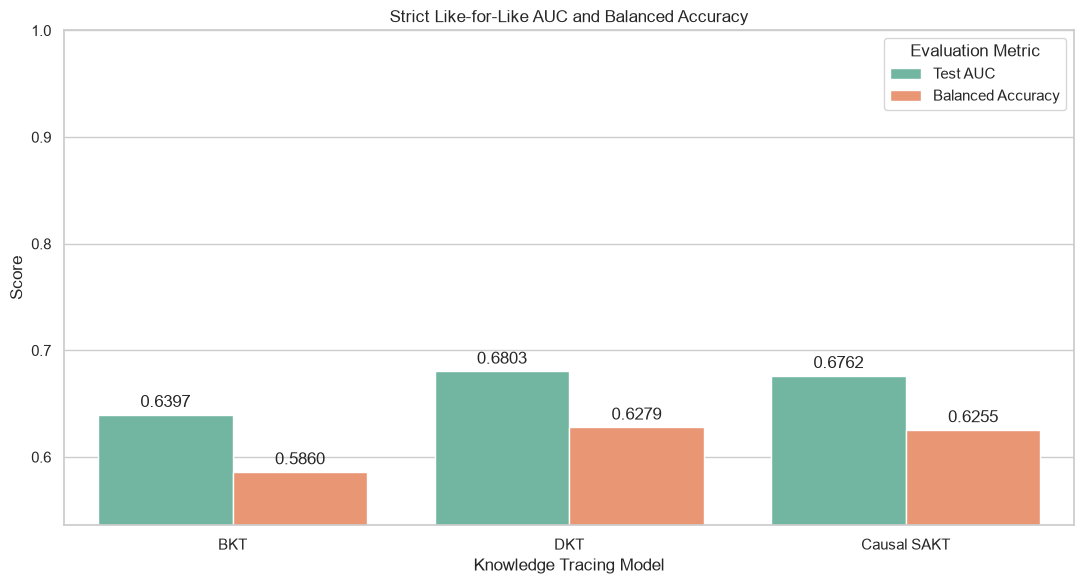

Figure saved to: /Users/tolulopesoetan/Desktop/msc_kt_ednet/results/figures/common_subset_auc_accuracy.png


In [50]:
performance_long = like_for_like_results.melt(
    id_vars="Model",
    value_vars=["Test AUC", "Balanced Accuracy"],
    var_name="Metric",
    value_name="Score",
)

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(11, 6))

sns.barplot(
    data=performance_long,
    x="Model",
    y="Score",
    hue="Metric",
    palette="Set2",
    ax=ax,
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

minimum_score = max(
    0.0,
    performance_long["Score"].min() - 0.05,
)
ax.set_ylim(minimum_score, 1.00)
ax.set_title("Strict Like-for-Like AUC and Balanced Accuracy")
ax.set_xlabel("Knowledge Tracing Model")
ax.set_ylabel("Score")
ax.legend(title="Evaluation Metric")

fig.tight_layout()
performance_figure_path = (
    FIGURES_DIR / "common_subset_auc_accuracy.png"
)
fig.savefig(
    performance_figure_path,
    dpi=300,
    bbox_inches="tight",
)
plt.show()
plt.close(fig)

print(f"Figure saved to: {performance_figure_path}")


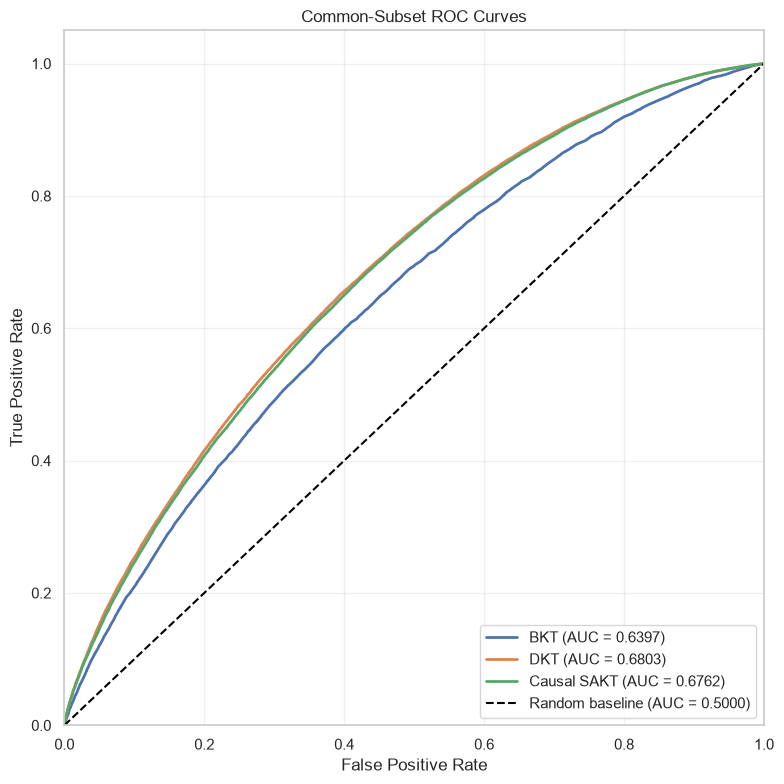

Figure saved to: /Users/tolulopesoetan/Desktop/msc_kt_ednet/results/figures/common_subset_roc_curves.png


In [51]:
model_probability_columns = {
    "BKT": "bkt_probability",
    "DKT": "dkt_probability",
    "Causal SAKT": "sakt_probability",
}

fig, ax = plt.subplots(figsize=(8, 8))

for model_name, probability_column in (
    model_probability_columns.items()
):
    false_positive_rate, true_positive_rate, _ = roc_curve(
        common_evaluation_table["actual"],
        common_evaluation_table[probability_column],
    )
    model_auc = roc_auc_score(
        common_evaluation_table["actual"],
        common_evaluation_table[probability_column],
    )
    ax.plot(
        false_positive_rate,
        true_positive_rate,
        linewidth=2,
        label=f"{model_name} (AUC = {model_auc:.4f})",
    )

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="black",
    linewidth=1.5,
    label="Random baseline (AUC = 0.5000)",
)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.set_title("Common-Subset ROC Curves")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)

fig.tight_layout()
roc_figure_path = FIGURES_DIR / "common_subset_roc_curves.png"
fig.savefig(roc_figure_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Figure saved to: {roc_figure_path}")


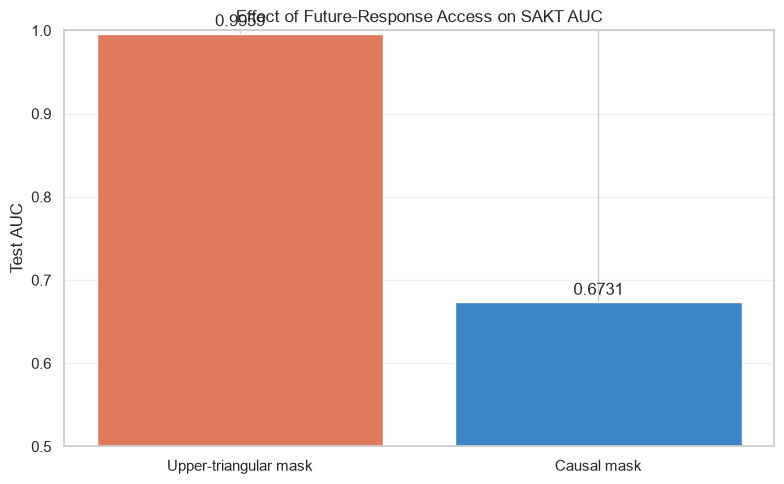

Figure saved to: /Users/tolulopesoetan/Desktop/msc_kt_ednet/results/figures/sakt_temporal_leakage_diagnostic.png


In [52]:
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    sakt_diagnostic_df["Evaluation"],
    sakt_diagnostic_df["Test AUC"],
    color=["#E07A5F", "#3D85C6"],
)
ax.bar_label(
    bars,
    labels=[
        f"{value:.4f}"
        for value in sakt_diagnostic_df["Test AUC"]
    ],
    padding=3,
)
ax.set_ylim(0.5, 1.0)
ax.set_title("Effect of Future-Response Access on SAKT AUC")
ax.set_xlabel("")
ax.set_ylabel("Test AUC")
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()
diagnostic_figure_path = (
    FIGURES_DIR / "sakt_temporal_leakage_diagnostic.png"
)
fig.savefig(
    diagnostic_figure_path,
    dpi=300,
    bbox_inches="tight",
)
plt.show()
plt.close(fig)

print(f"Figure saved to: {diagnostic_figure_path}")


## Stratified Failure-Mode Analysis

All strata use the strict common interaction subset. Available history is measured at prediction time, skill rarity is calculated from training data only, and the broader long-history group is separated into 51–100, 101–500 and 501+ prior interactions. Classification metrics use validation-selected decision thresholds.

Each table reports discrimination, precision-recall performance, classification errors, calibration-sensitive scores and learner-cluster bootstrap confidence intervals. A practical failure-mode flag requires at least 500 interactions from at least 30 learners and an AUC drop of 0.03 or more relative to that model's overall common-subset AUC.


In [53]:
analysis_table = common_evaluation_table.copy()

test_user_lengths = (
    positioned_test_df.groupby("user_id")
    .size()
    .rename("total_test_interactions")
    .reset_index()
)

analysis_table = analysis_table.merge(
    test_user_lengths,
    on="user_id",
    how="left",
    validate="many_to_one",
)

analysis_table["prior_interactions"] = (
    analysis_table["interaction_position"] - 1
)

history_boundaries = [0, 5, 20, 50, 100, 500, np.inf]
history_labels = [
    "Cold start (1-5 prior)",
    "Early history (6-20 prior)",
    "Developing history (21-50 prior)",
    "Established history (51-100 prior)",
    "Experienced history (101-500 prior)",
    "Extensive history (501+ prior)",
]

analysis_table["Available History Stratum"] = pd.cut(
    analysis_table["prior_interactions"],
    bins=history_boundaries,
    labels=history_labels,
    include_lowest=True,
)

training_skill_frequency = train_df["skill"].value_counts()
rarity_threshold = training_skill_frequency.quantile(0.25)
rare_skills = training_skill_frequency[
    training_skill_frequency <= rarity_threshold
].index

analysis_table["Training Skill Frequency"] = (
    analysis_table["skill_id"]
    .map(training_skill_frequency)
    .fillna(0)
    .astype(int)
)

skill_id_to_tag = {
    skill_id: str(skill_tag)
    for skill_id, skill_tag in enumerate(label_encoder.classes_)
}
analysis_table["skill_tag"] = (
    analysis_table["skill_id"]
    .map(skill_id_to_tag)
    .fillna("unknown")
)

analysis_table["Skill Frequency Group"] = np.where(
    analysis_table["skill_id"].isin(rare_skills),
    "Rare skill (bottom 25%)",
    "Common skill (top 75%)",
)

if analysis_table["Available History Stratum"].isna().any():
    raise ValueError("Some interactions were not assigned a history stratum.")

analysis_population_coverage = pd.DataFrame([
    {
        "Population": "All test interactions",
        "Interactions": len(positioned_test_df),
        "Learners": positioned_test_df["user_id"].nunique(),
    },
    {
        "Population": "All BKT predictions",
        "Interactions": len(bkt_all_prediction_table),
        "Learners": bkt_all_prediction_table["user_id"].nunique(),
    },
    {
        "Population": "All neural predictions",
        "Interactions": len(neural_prediction_table),
        "Learners": neural_prediction_table["user_id"].nunique(),
    },
    {
        "Population": "Strict common subset",
        "Interactions": len(analysis_table),
        "Learners": analysis_table["user_id"].nunique(),
    },
])
analysis_population_coverage["Test Interaction Coverage"] = (
    analysis_population_coverage["Interactions"]
    / len(positioned_test_df)
)

stratum_coverage_records = []
for dimension in [
    "Available History Stratum",
    "Skill Frequency Group",
]:
    for stratum, subset in analysis_table.groupby(
        dimension,
        observed=True,
        sort=False,
    ):
        stratum_coverage_records.append({
            "Dimension": dimension,
            "Stratum": str(stratum),
            "Interactions": len(subset),
            "Learners": subset["user_id"].nunique(),
            "Observed Correctness Rate": subset["actual"].mean(),
        })

stratum_coverage_df = pd.DataFrame(stratum_coverage_records)

display(analysis_population_coverage.round(4))
display(stratum_coverage_df.round(4))

analysis_population_coverage.to_csv(
    TABLES_DIR / "analysis_population_coverage.csv",
    index=False,
)
stratum_coverage_df.to_csv(
    TABLES_DIR / "stratified_population_coverage.csv",
    index=False,
)


,Population,Interactions,Learners,Test Interaction Coverage
0,All test interactions,982533,4000,1.00000
1,All BKT predictions,982533,4000,1.00000
2,All neural predictions,219214,4000,0.22310
3,Strict common subset,219214,4000,0.22310


,Dimension,Stratum,Interactions,Learners,Observed Correctness Rate
0,Available History Stratum,Cold start (1-5 prior),14030,2815,0.47660
1,Available History Stratum,Early history (6-20 prior),39787,2892,0.47760
2,Available History Stratum,Developing history (21-50 prior),40589,2342,0.56150
3,Available History Stratum,Established history (51-100 prior),25713,903,0.62930
4,Available History Stratum,Experienced history (101-500 prior),58504,816,0.63750
5,Available History Stratum,Extensive history (501+ prior),40591,443,0.65950
6,Skill Frequency Group,Common skill (top 75%),206602,4000,0.58600
7,Skill Frequency Group,Rare skill (bottom 25%),12612,2931,0.60730


In [54]:
MODEL_PROBABILITY_COLUMNS = {
    "BKT": "bkt_probability",
    "DKT": "dkt_probability",
    "Causal SAKT": "sakt_probability",
}

N_BOOTSTRAP_REPLICATES = 200
MIN_FAILURE_INTERACTIONS = 500
MIN_FAILURE_LEARNERS = 30
PRACTICAL_AUC_DROP = 0.03


def calculate_binary_metrics(
    data,
    probability_column,
    decision_threshold=0.50,
):
    y_true = data["actual"].astype(int).to_numpy()
    y_probability = (
        data[probability_column]
        .astype(float)
        .clip(1e-7, 1 - 1e-7)
        .to_numpy()
    )
    y_prediction = (
        y_probability >= decision_threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_prediction,
        labels=[0, 1],
    ).ravel()

    auc = (
        roc_auc_score(y_true, y_probability)
        if np.unique(y_true).size == 2
        else np.nan
    )

    return {
        "Interactions": len(data),
        "Learners": data["user_id"].nunique(),
        "Negative Outcomes": int((y_true == 0).sum()),
        "Positive Outcomes": int((y_true == 1).sum()),
        "Decision Threshold": decision_threshold,
        "AUC": auc,
        "PR AUC": average_precision_score(y_true, y_probability),
        "Accuracy": accuracy_score(y_true, y_prediction),
        "Balanced Accuracy": balanced_accuracy_score(
            y_true,
            y_prediction,
        ),
        "Precision": precision_score(
            y_true,
            y_prediction,
            zero_division=0,
        ),
        "Recall": recall_score(
            y_true,
            y_prediction,
            zero_division=0,
        ),
        "F1 Score": f1_score(
            y_true,
            y_prediction,
            zero_division=0,
        ),
        "Brier Score": brier_score_loss(y_true, y_probability),
        "Log Loss": log_loss(
            y_true,
            y_probability,
            labels=[0, 1],
        ),
        "False Positive Rate": (
            fp / (fp + tn) if (fp + tn) else np.nan
        ),
        "False Negative Rate": (
            fn / (fn + tp) if (fn + tp) else np.nan
        ),
    }


def learner_bootstrap_auc_interval(
    data,
    probability_column,
    number_of_replicates=N_BOOTSTRAP_REPLICATES,
    seed=SEED,
):
    working = data[
        ["user_id", "actual", probability_column]
    ].reset_index(drop=True)
    learner_row_indices = [
        group.index.to_numpy()
        for _, group in working.groupby("user_id", sort=False)
    ]

    if len(learner_row_indices) < 2:
        return np.nan, np.nan, 0

    actual = working["actual"].astype(int).to_numpy()
    probability = working[probability_column].to_numpy()
    rng = np.random.default_rng(seed)
    bootstrap_estimates = []

    for _ in range(number_of_replicates):
        sampled_learners = rng.integers(
            0,
            len(learner_row_indices),
            size=len(learner_row_indices),
        )
        sampled_rows = np.concatenate([
            learner_row_indices[index]
            for index in sampled_learners
        ])
        sampled_actual = actual[sampled_rows]

        if np.unique(sampled_actual).size < 2:
            continue

        bootstrap_estimates.append(
            roc_auc_score(
                sampled_actual,
                probability[sampled_rows],
            )
        )

    if not bootstrap_estimates:
        return np.nan, np.nan, 0

    lower, upper = np.quantile(
        bootstrap_estimates,
        [0.025, 0.975],
    )
    return float(lower), float(upper), len(bootstrap_estimates)


overall_common_auc = {
    model_name: roc_auc_score(
        analysis_table["actual"],
        analysis_table[probability_column],
    )
    for model_name, probability_column
    in MODEL_PROBABILITY_COLUMNS.items()
}


def run_stratified_analysis(data, dimension, seed_offset):
    records = []
    bootstrap_counter = 0

    for stratum, subset in data.groupby(
        dimension,
        observed=True,
        sort=False,
    ):
        for model_name, probability_column in (
            MODEL_PROBABILITY_COLUMNS.items()
        ):
            metrics = calculate_binary_metrics(
                subset,
                probability_column,
                MODEL_DECISION_THRESHOLDS[model_name],
            )
            ci_lower, ci_upper, completed = (
                learner_bootstrap_auc_interval(
                    subset,
                    probability_column,
                    seed=SEED + seed_offset + bootstrap_counter,
                )
            )
            bootstrap_counter += 1

            records.append({
                "Dimension": dimension,
                "Stratum": str(stratum),
                "Model": model_name,
                **metrics,
                "AUC 95% CI Lower": ci_lower,
                "AUC 95% CI Upper": ci_upper,
                "Completed Bootstrap Replicates": completed,
                "Overall Common-Subset AUC": overall_common_auc[model_name],
                "AUC Change from Overall": (
                    metrics["AUC"] - overall_common_auc[model_name]
                ),
            })

    return pd.DataFrame(records)


In [55]:
history_stratified_results = run_stratified_analysis(
    analysis_table,
    "Available History Stratum",
    seed_offset=1_000,
)
skill_stratified_results = run_stratified_analysis(
    analysis_table,
    "Skill Frequency Group",
    seed_offset=2_000,
)

stratified_results_df = pd.concat(
    [history_stratified_results, skill_stratified_results],
    ignore_index=True,
)

stratified_results_df["Adequate Sample"] = (
    (stratified_results_df["Interactions"] >= MIN_FAILURE_INTERACTIONS)
    & (stratified_results_df["Learners"] >= MIN_FAILURE_LEARNERS)
    & (stratified_results_df["Negative Outcomes"] > 0)
    & (stratified_results_df["Positive Outcomes"] > 0)
)
stratified_results_df["Potential Failure Mode"] = (
    stratified_results_df["Adequate Sample"]
    & (
        stratified_results_df["AUC Change from Overall"]
        <= -PRACTICAL_AUC_DROP
    )
)
stratified_results_df["Failure Assessment"] = np.select(
    [
        ~stratified_results_df["Adequate Sample"],
        stratified_results_df["Potential Failure Mode"],
    ],
    [
        "INSUFFICIENT SUBGROUP DATA",
        "POTENTIAL FAILURE MODE",
    ],
    default="NO PRACTICAL AUC DROP",
)

display_columns = [
    "Dimension",
    "Stratum",
    "Model",
    "Interactions",
    "Learners",
    "Decision Threshold",
    "AUC",
    "AUC 95% CI Lower",
    "AUC 95% CI Upper",
    "AUC Change from Overall",
    "PR AUC",
    "Balanced Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "False Positive Rate",
    "False Negative Rate",
    "Failure Assessment",
]

display(stratified_results_df[display_columns].round(5))

failure_mode_summary = stratified_results_df[
    stratified_results_df["Failure Assessment"]
    != "NO PRACTICAL AUC DROP"
].copy()

print("Flagged or data-limited strata:")
display(failure_mode_summary[display_columns].round(5))

stratified_results_df.to_csv(
    TABLES_DIR / "common_subset_stratified_metrics.csv",
    index=False,
)
failure_mode_summary.to_csv(
    TABLES_DIR / "stratified_failure_mode_summary.csv",
    index=False,
)


,Dimension,Stratum,Model,Interactions,Learners,Decision Threshold,AUC,AUC 95% CI Lower,AUC 95% CI Upper,AUC Change from Overall,PR AUC,Balanced Accuracy,Precision,Recall,F1 Score,False Positive Rate,False Negative Rate,Failure Assessment
0,Available History Stratum,Cold start (1-5 prior),BKT,14030,2815,0.67140,0.62240,0.61302,0.63104,-0.01734,0.60768,0.57597,0.64400,0.30597,0.41484,0.15402,0.69403,NO PRACTICAL AUC DROP
1,Available History Stratum,Cold start (1-5 prior),DKT,14030,2815,0.58882,0.64546,0.63495,0.65448,-0.03488,0.63229,0.57350,0.69334,0.24615,0.36332,0.09914,0.75385,POTENTIAL FAILURE MODE
2,Available History Stratum,Cold start (1-5 prior),Causal SAKT,14030,2815,0.58341,0.63777,0.62936,0.64675,-0.03848,0.62998,0.57888,0.66329,0.29341,0.40684,0.13564,0.70659,POTENTIAL FAILURE MODE
3,Available History Stratum,Early history (6-20 prior),BKT,39787,2892,0.67140,0.66465,0.65789,0.67082,0.02491,0.62853,0.57722,0.67883,0.27217,0.38855,0.11773,0.72783,NO PRACTICAL AUC DROP
4,Available History Stratum,Early history (6-20 prior),DKT,39787,2892,0.58882,0.70457,0.69877,0.71057,0.02423,0.67452,0.62531,0.67911,0.44125,0.53493,0.19063,0.55875,NO PRACTICAL AUC DROP
5,Available History Stratum,Early history (6-20 prior),Causal SAKT,39787,2892,0.58341,0.70386,0.69665,0.71058,0.02761,0.67291,0.62425,0.67923,0.43735,0.53209,0.18885,0.56265,NO PRACTICAL AUC DROP
6,Available History Stratum,Developing history (21-50 prior),BKT,40589,2342,0.67140,0.62294,0.61624,0.62920,-0.01681,0.66050,0.56782,0.69512,0.30942,0.42822,0.17378,0.69058,NO PRACTICAL AUC DROP
7,Available History Stratum,Developing history (21-50 prior),DKT,40589,2342,0.58882,0.69128,0.68541,0.69751,0.01094,0.72379,0.63548,0.69333,0.62494,0.65736,0.35397,0.37506,NO PRACTICAL AUC DROP
8,Available History Stratum,Developing history (21-50 prior),Causal SAKT,40589,2342,0.58341,0.68510,0.67715,0.69183,0.00885,0.71836,0.62893,0.68236,0.63841,0.65965,0.38055,0.36159,NO PRACTICAL AUC DROP
9,Available History Stratum,Established history (51-100 prior),BKT,25713,903,0.67140,0.60287,0.59338,0.61344,-0.03688,0.71110,0.56493,0.73169,0.34398,0.46797,0.21412,0.65602,POTENTIAL FAILURE MODE


Flagged or data-limited strata:


,Dimension,Stratum,Model,Interactions,Learners,Decision Threshold,AUC,AUC 95% CI Lower,AUC 95% CI Upper,AUC Change from Overall,PR AUC,Balanced Accuracy,Precision,Recall,F1 Score,False Positive Rate,False Negative Rate,Failure Assessment
1,Available History Stratum,Cold start (1-5 prior),DKT,14030,2815,0.58882,0.64546,0.63495,0.65448,-0.03488,0.63229,0.57350,0.69334,0.24615,0.36332,0.09914,0.75385,POTENTIAL FAILURE MODE
2,Available History Stratum,Cold start (1-5 prior),Causal SAKT,14030,2815,0.58341,0.63777,0.62936,0.64675,-0.03848,0.62998,0.57888,0.66329,0.29341,0.40684,0.13564,0.70659,POTENTIAL FAILURE MODE
9,Available History Stratum,Established history (51-100 prior),BKT,25713,903,0.67140,0.60287,0.59338,0.61344,-0.03688,0.71110,0.56493,0.73169,0.34398,0.46797,0.21412,0.65602,POTENTIAL FAILURE MODE
12,Available History Stratum,Experienced history (101-500 prior),BKT,58504,816,0.67140,0.59760,0.59087,0.60387,-0.04214,0.71163,0.56491,0.72175,0.40317,0.51735,0.27335,0.59683,POTENTIAL FAILURE MODE
13,Available History Stratum,Experienced history (101-500 prior),DKT,58504,816,0.58882,0.63639,0.62879,0.64344,-0.04394,0.73922,0.59202,0.69986,0.74885,0.72353,0.56481,0.25115,POTENTIAL FAILURE MODE
14,Available History Stratum,Experienced history (101-500 prior),Causal SAKT,58504,816,0.58341,0.62984,0.62248,0.63866,-0.04641,0.73303,0.58160,0.68795,0.80690,0.74269,0.64370,0.19310,POTENTIAL FAILURE MODE
16,Available History Stratum,Extensive history (501+ prior),DKT,40591,443,0.58882,0.63494,0.62566,0.64666,-0.04540,0.76222,0.58016,0.70898,0.78160,0.74352,0.62128,0.21840,POTENTIAL FAILURE MODE
17,Available History Stratum,Extensive history (501+ prior),Causal SAKT,40591,443,0.58341,0.63115,0.61989,0.64182,-0.04510,0.75928,0.57094,0.70001,0.83391,0.76112,0.69204,0.16609,POTENTIAL FAILURE MODE


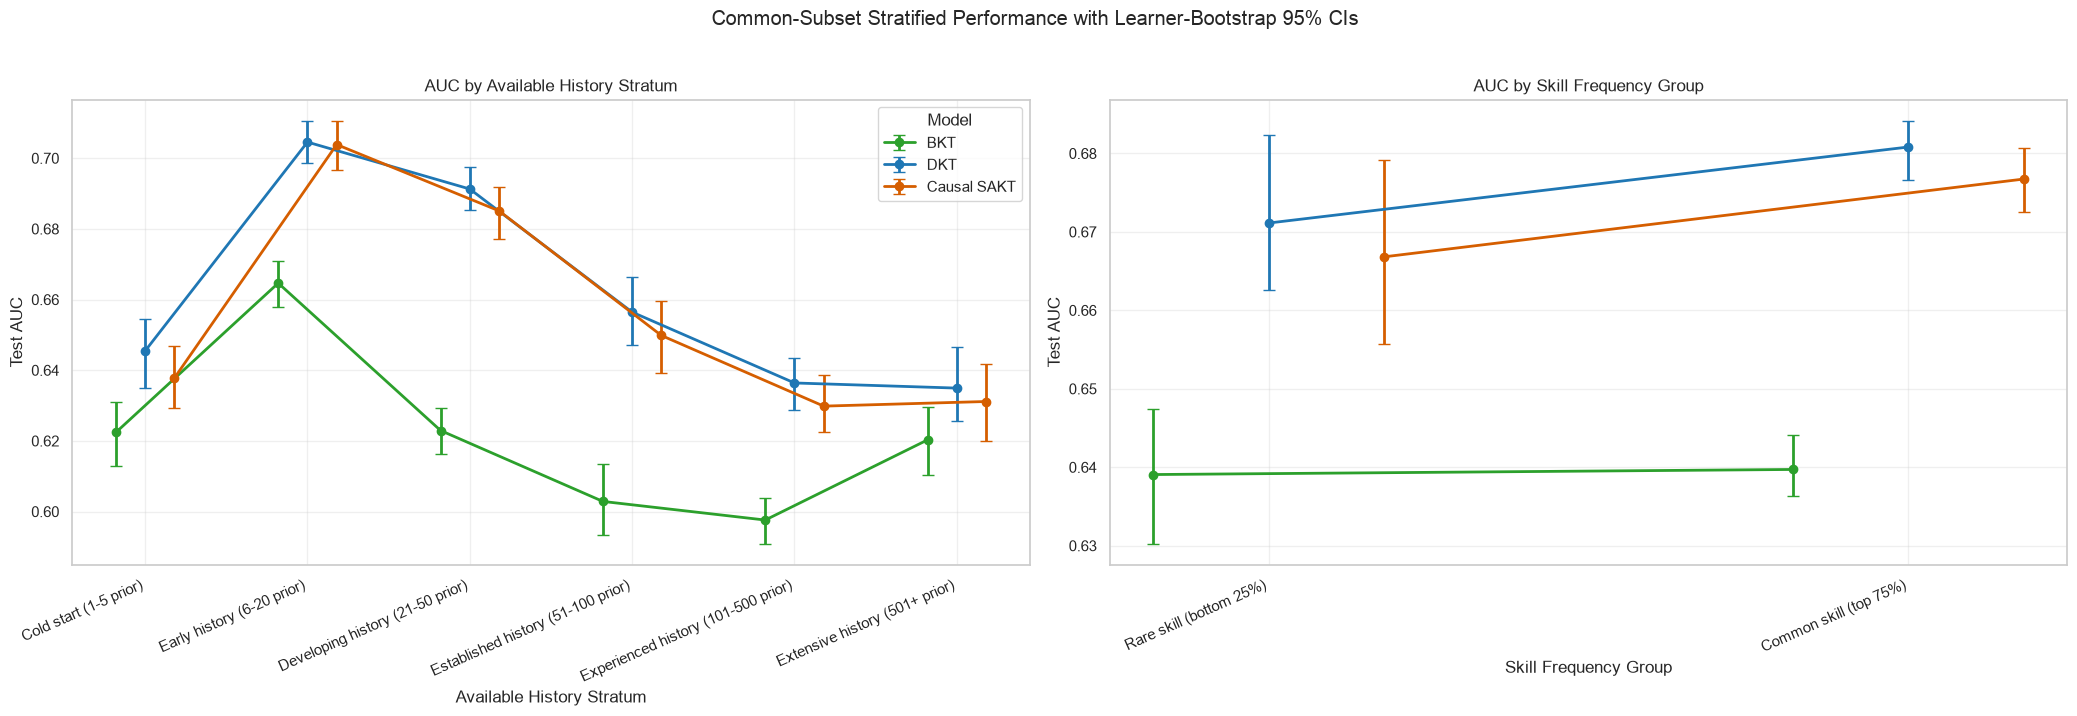

Figure saved to: /Users/tolulopesoetan/Desktop/msc_kt_ednet/results/figures/common_subset_stratified_auc.png


In [56]:
dimension_orders = {
    "Available History Stratum": history_labels,
    "Skill Frequency Group": [
        "Rare skill (bottom 25%)",
        "Common skill (top 75%)",
    ],
}

model_colours = {
    "BKT": "#2CA02C",
    "DKT": "#1F77B4",
    "Causal SAKT": "#D55E00",
}

fig, axes = plt.subplots(1, 2, figsize=(21, 7))

for axis, (dimension, order) in zip(
    axes,
    dimension_orders.items(),
):
    dimension_data = stratified_results_df[
        stratified_results_df["Dimension"] == dimension
    ]
    x_positions = np.arange(len(order))

    for model_index, model_name in enumerate(
        MODEL_PROBABILITY_COLUMNS
    ):
        model_data = (
            dimension_data[
                dimension_data["Model"] == model_name
            ]
            .set_index("Stratum")
            .reindex(order)
        )
        offset = (model_index - 1) * 0.18
        lower_error = (
            model_data["AUC"]
            - model_data["AUC 95% CI Lower"]
        ).clip(lower=0)
        upper_error = (
            model_data["AUC 95% CI Upper"]
            - model_data["AUC"]
        ).clip(lower=0)

        axis.errorbar(
            x_positions + offset,
            model_data["AUC"],
            yerr=np.vstack([lower_error, upper_error]),
            marker="o",
            capsize=4,
            linewidth=2,
            label=model_name,
            color=model_colours[model_name],
        )

    axis.set_xticks(x_positions)
    axis.set_xticklabels(order, rotation=24, ha="right")
    axis.set_xlabel(dimension)
    axis.set_ylabel("Test AUC")
    axis.set_title(f"AUC by {dimension}")
    axis.grid(alpha=0.3)

axes[0].legend(title="Model")
fig.suptitle(
    "Common-Subset Stratified Performance with Learner-Bootstrap 95% CIs",
    y=1.02,
)
fig.tight_layout()

stratified_figure_path = (
    FIGURES_DIR / "common_subset_stratified_auc.png"
)
fig.savefig(
    stratified_figure_path,
    dpi=300,
    bbox_inches="tight",
)
plt.show()
plt.close(fig)

print(f"Figure saved to: {stratified_figure_path}")


## Stratified Error Types

False-positive and false-negative rates are separated because two models with similar AUC can fail in different ways. A false positive predicts a correct response when the response is incorrect; a false negative predicts an incorrect response when the response is correct.


,Dimension,Stratum,Model,Interactions,Learners,False Positive Rate,False Negative Rate
0,Available History Stratum,Cold start (1-5 prior),BKT,14030,2815,0.15402,0.69403
1,Available History Stratum,Cold start (1-5 prior),DKT,14030,2815,0.09914,0.75385
2,Available History Stratum,Cold start (1-5 prior),Causal SAKT,14030,2815,0.13564,0.70659
3,Available History Stratum,Early history (6-20 prior),BKT,39787,2892,0.11773,0.72783
4,Available History Stratum,Early history (6-20 prior),DKT,39787,2892,0.19063,0.55875
5,Available History Stratum,Early history (6-20 prior),Causal SAKT,39787,2892,0.18885,0.56265
6,Available History Stratum,Developing history (21-50 prior),BKT,40589,2342,0.17378,0.69058
7,Available History Stratum,Developing history (21-50 prior),DKT,40589,2342,0.35397,0.37506
8,Available History Stratum,Developing history (21-50 prior),Causal SAKT,40589,2342,0.38055,0.36159
9,Available History Stratum,Established history (51-100 prior),BKT,25713,903,0.21412,0.65602


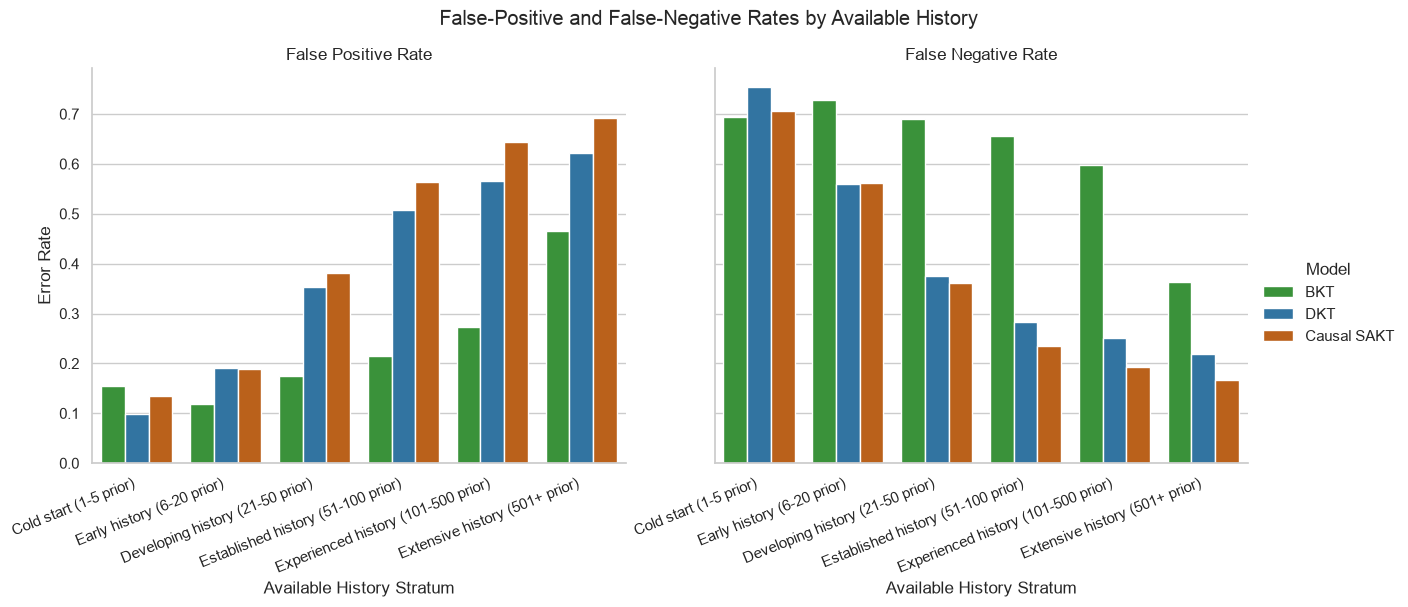

Figure saved to: /Users/tolulopesoetan/Desktop/msc_kt_ednet/results/figures/stratified_false_positive_false_negative_rates.png


In [57]:
error_rate_results_df = stratified_results_df[
    [
        "Dimension",
        "Stratum",
        "Model",
        "Interactions",
        "Learners",
        "False Positive Rate",
        "False Negative Rate",
    ]
].copy()

error_rate_long = error_rate_results_df.melt(
    id_vars=[
        "Dimension",
        "Stratum",
        "Model",
        "Interactions",
        "Learners",
    ],
    value_vars=[
        "False Positive Rate",
        "False Negative Rate",
    ],
    var_name="Error Type",
    value_name="Error Rate",
)

display(error_rate_results_df.round(5))

error_rate_results_df.to_csv(
    TABLES_DIR / "common_subset_stratified_error_rates.csv",
    index=False,
)

history_error_data = error_rate_long[
    error_rate_long["Dimension"]
    == "Available History Stratum"
].copy()

figure = sns.catplot(
    data=history_error_data,
    x="Stratum",
    y="Error Rate",
    hue="Model",
    col="Error Type",
    kind="bar",
    palette=model_colours,
    height=5,
    aspect=1.25,
    sharey=True,
)
figure.set_axis_labels("Available History Stratum", "Error Rate")
figure.set_titles("{col_name}")

for axis in figure.axes.flat:
    axis.tick_params(axis="x", rotation=22)
    for label in axis.get_xticklabels():
        label.set_horizontalalignment("right")

figure.fig.suptitle(
    "False-Positive and False-Negative Rates by Available History",
    y=1.04,
)

error_figure_path = (
    FIGURES_DIR / "stratified_false_positive_false_negative_rates.png"
)
figure.savefig(
    error_figure_path,
    dpi=300,
    bbox_inches="tight",
)
plt.show()
plt.close(figure.fig)

print(f"Figure saved to: {error_figure_path}")


## Probability Calibration on the Common Subset

Expected Calibration Error, Brier score, and reliability curves are calculated on the same interactions used in the strict model comparison. Lower values indicate better calibration for both error metrics.


In [58]:
def calculate_expected_calibration_error(
    y_true,
    y_probability,
    number_of_bins=10,
):
    y_true = np.asarray(y_true)
    y_probability = np.asarray(y_probability)

    bin_edges = np.linspace(
        0.0,
        1.0,
        number_of_bins + 1,
    )

    bin_indices = np.digitize(
        y_probability,
        bin_edges[1:-1],
        right=True,
    )

    calibration_error = 0.0

    for bin_index in range(number_of_bins):
        observations = bin_indices == bin_index

        if not np.any(observations):
            continue

        observed_accuracy = y_true[observations].mean()
        mean_confidence = y_probability[observations].mean()
        bin_weight = observations.mean()

        calibration_error += (
            bin_weight
            * abs(observed_accuracy - mean_confidence)
        )

    return calibration_error


In [59]:
calibration_inputs = {
    model_name: (
        common_evaluation_table["actual"].to_numpy(),
        common_evaluation_table[probability_column].to_numpy(),
    )
    for model_name, probability_column
    in MODEL_PROBABILITY_COLUMNS.items()
}

calibration_results = []

for model_name, (
    true_values,
    probabilities,
) in calibration_inputs.items():
    calibration_results.append({
        "Model": model_name,
        "Interactions": len(true_values),
        "Expected Calibration Error": (
            calculate_expected_calibration_error(
                true_values,
                probabilities,
                number_of_bins=10,
            )
        ),
        "Brier Score": brier_score_loss(
            true_values,
            probabilities,
        ),
    })

calibration_results_df = pd.DataFrame(calibration_results)
display(calibration_results_df.round(5))

calibration_results_df.to_csv(
    TABLES_DIR / "common_subset_calibration_metrics.csv",
    index=False,
)


,Model,Interactions,Expected Calibration Error,Brier Score
0,BKT,219214,0.03017,0.22888
1,DKT,219214,0.00170,0.21791
2,Causal SAKT,219214,0.00824,0.21887


In [60]:
calibration_curve_records = []

for model_name, (
    true_values,
    probabilities,
) in calibration_inputs.items():
    observed_fraction, mean_prediction = calibration_curve(
        true_values,
        probabilities,
        n_bins=10,
        strategy="uniform",
    )

    for bin_number, (
        observed_value,
        predicted_value,
    ) in enumerate(
        zip(observed_fraction, mean_prediction),
        start=1,
    ):
        calibration_curve_records.append({
            "Model": model_name,
            "Bin": bin_number,
            "Mean Predicted Probability": predicted_value,
            "Observed Correctness Rate": observed_value,
        })

calibration_curve_df = pd.DataFrame(
    calibration_curve_records
)

calibration_curve_df.to_csv(
    TABLES_DIR / "calibration_curve_values.csv",
    index=False,
)

display(calibration_curve_df.round(5))


,Model,Bin,Mean Predicted Probability,Observed Correctness Rate
0,BKT,1,0.25064,0.23744
1,BKT,2,0.36470,0.31158
2,BKT,3,0.45774,0.40748
3,BKT,4,0.55957,0.52428
4,BKT,5,0.64977,0.62490
5,BKT,6,0.74448,0.72406
6,BKT,7,0.82722,0.80398
7,BKT,8,0.90871,1.00000
8,DKT,1,0.17498,0.17797
9,DKT,2,0.25133,0.25030


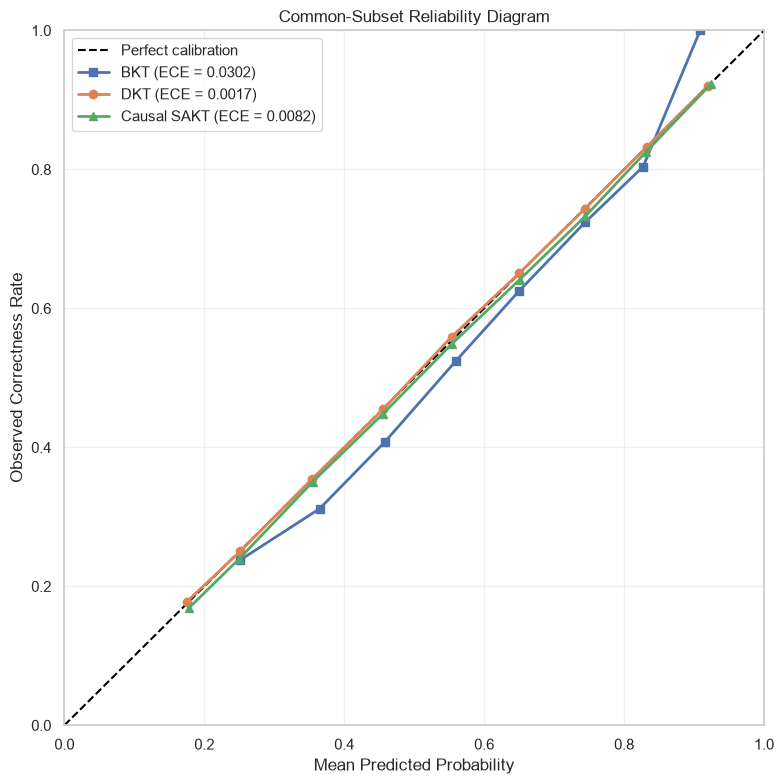

Figure saved to: /Users/tolulopesoetan/Desktop/msc_kt_ednet/results/figures/common_subset_reliability_diagram.png


In [61]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="black",
    linewidth=1.5,
    label="Perfect calibration",
)

model_markers = {
    "BKT": "s",
    "DKT": "o",
    "Causal SAKT": "^",
}

for model_name in model_markers:
    model_curve = calibration_curve_df[
        calibration_curve_df["Model"] == model_name
    ]

    model_ece = calibration_results_df.loc[
        calibration_results_df["Model"] == model_name,
        "Expected Calibration Error",
    ].iloc[0]

    ax.plot(
        model_curve["Mean Predicted Probability"],
        model_curve["Observed Correctness Rate"],
        marker=model_markers[model_name],
        linewidth=2,
        label=f"{model_name} (ECE = {model_ece:.4f})",
    )

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title("Common-Subset Reliability Diagram")
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Observed Correctness Rate")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)

fig.tight_layout()

calibration_figure_path = (
    FIGURES_DIR / "common_subset_reliability_diagram.png"
)

fig.savefig(
    calibration_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print(f"Figure saved to: {calibration_figure_path}")


## Model Disagreement Analysis

Probability disagreement is the range between the highest and lowest probability on an interaction. Class disagreement is calculated using each model's validation-selected threshold. A large probability disagreement is defined as a range of at least 0.25.


In [62]:
disagreement_table = analysis_table.copy()
DISAGREEMENT_PROBABILITY_RANGE = 0.25

short_probability_columns = {
    "BKT": "bkt_probability",
    "DKT": "dkt_probability",
    "Causal SAKT": "sakt_probability",
}

prediction_columns = []
correctness_columns = []

for model_name, probability_column in short_probability_columns.items():
    model_key = model_name.lower().replace(" ", "_")
    prediction_column = f"{model_key}_prediction"
    correctness_column = f"{model_key}_correct"
    threshold = MODEL_DECISION_THRESHOLDS[model_name]

    disagreement_table[prediction_column] = (
        disagreement_table[probability_column] >= threshold
    ).astype(int)
    disagreement_table[correctness_column] = (
        disagreement_table[prediction_column]
        == disagreement_table["actual"]
    )

    prediction_columns.append(prediction_column)
    correctness_columns.append(correctness_column)

disagreement_table["probability_range"] = (
    disagreement_table[list(short_probability_columns.values())].max(axis=1)
    - disagreement_table[list(short_probability_columns.values())].min(axis=1)
)
disagreement_table["class_disagreement"] = (
    disagreement_table[prediction_columns].nunique(axis=1) > 1
)
disagreement_table["large_probability_disagreement"] = (
    disagreement_table["probability_range"]
    >= DISAGREEMENT_PROBABILITY_RANGE
)
disagreement_table["number_of_correct_models"] = (
    disagreement_table[correctness_columns].sum(axis=1)
)
disagreement_table["prediction_pattern"] = (
    disagreement_table[prediction_columns]
    .astype(str)
    .agg("-".join, axis=1)
)

print(
    "Interactions with class disagreement:",
    f"{disagreement_table['class_disagreement'].mean():.2%}",
)
print(
    "Interactions with probability range >= "
    f"{DISAGREEMENT_PROBABILITY_RANGE:.2f}:",
    f"{disagreement_table['large_probability_disagreement'].mean():.2%}",
)


Interactions with class disagreement: 38.79%
Interactions with probability range >= 0.25: 4.97%


In [63]:
pairwise_disagreement_records = []
model_pairs = list(itertools.combinations(short_probability_columns, 2))

for first_model, second_model in model_pairs:
    first_probability = short_probability_columns[first_model]
    second_probability = short_probability_columns[second_model]
    first_key = first_model.lower().replace(" ", "_")
    second_key = second_model.lower().replace(" ", "_")
    first_prediction = f"{first_key}_prediction"
    second_prediction = f"{second_key}_prediction"
    first_correct = f"{first_key}_correct"
    second_correct = f"{second_key}_correct"

    pairwise_disagreement = (
        disagreement_table[first_prediction]
        != disagreement_table[second_prediction]
    )
    pairwise_subset = disagreement_table[pairwise_disagreement]

    pairwise_disagreement_records.append({
        "Model Pair": f"{first_model} vs {second_model}",
        "Model A": first_model,
        "Model B": second_model,
        "Interactions": len(disagreement_table),
        "Class Disagreement Count": int(pairwise_disagreement.sum()),
        "Class Disagreement Rate": pairwise_disagreement.mean(),
        "Mean Absolute Probability Difference": (
            disagreement_table[first_probability]
            .sub(disagreement_table[second_probability])
            .abs()
            .mean()
        ),
        "Median Absolute Probability Difference": (
            disagreement_table[first_probability]
            .sub(disagreement_table[second_probability])
            .abs()
            .median()
        ),
        "Probability Correlation": disagreement_table[
            [first_probability, second_probability]
        ].corr().iloc[0, 1],
        "Model A Win Rate Among Pairwise Disagreements": (
            pairwise_subset[first_correct].mean()
        ),
        "Model B Win Rate Among Pairwise Disagreements": (
            pairwise_subset[second_correct].mean()
        ),
    })

pairwise_disagreement_df = pd.DataFrame(pairwise_disagreement_records)

model_role_records = []
for model_name in short_probability_columns:
    model_key = model_name.lower().replace(" ", "_")
    correct_column = f"{model_key}_correct"
    sole_correct = (
        disagreement_table[correct_column]
        & (disagreement_table["number_of_correct_models"] == 1)
    )
    sole_incorrect = (
        ~disagreement_table[correct_column]
        & (disagreement_table["number_of_correct_models"] == 2)
    )

    model_role_records.append({
        "Model": model_name,
        "Overall Accuracy": disagreement_table[correct_column].mean(),
        "Accuracy on Class-Disagreement Interactions": (
            disagreement_table.loc[
                disagreement_table["class_disagreement"],
                correct_column,
            ].mean()
        ),
        "Sole Correct Count": int(sole_correct.sum()),
        "Sole Correct Rate": sole_correct.mean(),
        "Sole Incorrect Count": int(sole_incorrect.sum()),
        "Sole Incorrect Rate": sole_incorrect.mean(),
    })

model_disagreement_roles_df = pd.DataFrame(model_role_records)

pattern_summary_df = (
    disagreement_table.groupby("prediction_pattern", as_index=False)
    .agg(
        Interactions=("actual", "size"),
        Learners=("user_id", "nunique"),
        Observed_Correctness_Rate=("actual", "mean"),
        Mean_Probability_Range=("probability_range", "mean"),
    )
)
pattern_summary_df["Interaction Rate"] = (
    pattern_summary_df["Interactions"] / len(disagreement_table)
)

display(pairwise_disagreement_df.round(5))
display(model_disagreement_roles_df.round(5))
display(
    pattern_summary_df.sort_values(
        "Interactions",
        ascending=False,
    ).round(5)
)


,Model Pair,Model A,Model B,Interactions,Class Disagreement Count,Class Disagreement Rate,Mean Absolute Probability Difference,Median Absolute Probability Difference,Probability Correlation,Model A Win Rate Among Pairwise Disagreements,Model B Win Rate Among Pairwise Disagreements
0,BKT vs DKT,BKT,DKT,219214,70019,0.31941,0.09060,0.07320,0.69991,0.37623,0.62377
1,BKT vs Causal SAKT,BKT,Causal SAKT,219214,74325,0.33905,0.08743,0.07137,0.70467,0.37663,0.62337
2,DKT vs Causal SAKT,DKT,Causal SAKT,219214,25744,0.11744,0.04200,0.03319,0.93902,0.48046,0.51954


,Model,Overall Accuracy,Accuracy on Class-Disagreement Interactions,Sole Correct Count,Sole Correct Rate,Sole Incorrect Count,Sole Incorrect Rate
0,BKT,0.55414,0.39056,21121,0.09635,38179,0.17416
1,DKT,0.63321,0.59437,5497,0.02508,5222,0.02382
2,Causal SAKT,0.63780,0.60620,8153,0.03719,6872,0.03135


,prediction_pattern,Interactions,Learners,Observed_Correctness_Rate,Mean_Probability_Range,Interaction Rate
0,0-0-0,74112,3898,0.41019,0.13523,0.33808
7,1-1-1,60058,3432,0.74177,0.07372,0.27397
3,0-1-1,52582,3215,0.66719,0.09903,0.23987
1,0-0-1,13100,2587,0.56664,0.09607,0.05976
4,1-0-0,6718,2182,0.53900,0.22553,0.03065
2,0-1-0,6555,2267,0.59420,0.10091,0.02990
5,1-0-1,4164,1589,0.61527,0.16758,0.01900
6,1-1-0,1925,971,0.62078,0.16993,0.00878


In [64]:
def learner_bootstrap_mean_interval(
    data,
    value_column,
    number_of_replicates=N_BOOTSTRAP_REPLICATES,
    seed=SEED,
):
    working = data[
        ["user_id", value_column]
    ].reset_index(drop=True)
    learner_rows = [
        group.index.to_numpy()
        for _, group in working.groupby(
            "user_id",
            sort=False,
        )
    ]

    if len(learner_rows) < 2:
        return np.nan, np.nan, 0

    values = working[value_column].astype(float).to_numpy()
    rng = np.random.default_rng(seed)
    estimates = []

    for _ in range(number_of_replicates):
        sampled_learners = rng.integers(
            0,
            len(learner_rows),
            size=len(learner_rows),
        )
        sampled_rows = np.concatenate([
            learner_rows[index]
            for index in sampled_learners
        ])
        estimates.append(values[sampled_rows].mean())

    lower, upper = np.quantile(estimates, [0.025, 0.975])
    return float(lower), float(upper), len(estimates)


disagreement_strata_records = []
bootstrap_counter = 0

for dimension in [
    "Available History Stratum",
    "Skill Frequency Group",
]:
    for stratum, subset in disagreement_table.groupby(
        dimension,
        observed=True,
        sort=False,
    ):
        ci_lower, ci_upper, completed = (
            learner_bootstrap_mean_interval(
                subset,
                "class_disagreement",
                seed=SEED + 3_000 + bootstrap_counter,
            )
        )
        bootstrap_counter += 1

        disagreement_strata_records.append({
            "Dimension": dimension,
            "Stratum": str(stratum),
            "Interactions": len(subset),
            "Learners": subset["user_id"].nunique(),
            "Class Disagreement Rate": subset[
                "class_disagreement"
            ].mean(),
            "Class Disagreement 95% CI Lower": ci_lower,
            "Class Disagreement 95% CI Upper": ci_upper,
            "Large Probability Disagreement Rate": subset[
                "large_probability_disagreement"
            ].mean(),
            "Mean Probability Range": subset[
                "probability_range"
            ].mean(),
            "Completed Bootstrap Replicates": completed,
        })

disagreement_by_stratum_df = pd.DataFrame(
    disagreement_strata_records
)

high_disagreement_cases = (
    disagreement_table[
        disagreement_table["class_disagreement"]
        | disagreement_table[
            "large_probability_disagreement"
        ]
    ]
    .sort_values(
        "probability_range",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(disagreement_by_stratum_df.round(5))
display(
    high_disagreement_cases[
        [
            "user_id",
            "interaction_position",
            "skill_id",
            "skill_tag",
            "Training Skill Frequency",
            "Available History Stratum",
            "Skill Frequency Group",
            "actual",
            "bkt_probability",
            "dkt_probability",
            "sakt_probability",
            "prediction_pattern",
            "probability_range",
            "number_of_correct_models",
        ]
    ].head(25).round(5)
)

pairwise_disagreement_df.to_csv(
    TABLES_DIR / "pairwise_model_disagreement.csv",
    index=False,
)
model_disagreement_roles_df.to_csv(
    TABLES_DIR / "model_disagreement_roles.csv",
    index=False,
)
pattern_summary_df.to_csv(
    TABLES_DIR / "model_prediction_patterns.csv",
    index=False,
)
disagreement_by_stratum_df.to_csv(
    TABLES_DIR / "model_disagreement_by_stratum.csv",
    index=False,
)
high_disagreement_cases.to_csv(
    TABLES_DIR / "high_disagreement_interactions.csv",
    index=False,
)


,Dimension,Stratum,Interactions,Learners,Class Disagreement Rate,Class Disagreement 95% CI Lower,Class Disagreement 95% CI Upper,Large Probability Disagreement Rate,Mean Probability Range,Completed Bootstrap Replicates
0,Available History Stratum,Cold start (1-5 prior),14030,2815,0.22751,0.22111,0.23422,0.04298,0.13613,200
1,Available History Stratum,Early history (6-20 prior),39787,2892,0.23586,0.22870,0.24347,0.05909,0.12569,200
2,Available History Stratum,Developing history (21-50 prior),40589,2342,0.39373,0.38429,0.40272,0.10318,0.12398,200
3,Available History Stratum,Established history (51-100 prior),25713,903,0.49263,0.47736,0.50853,0.04056,0.10206,200
4,Available History Stratum,Experienced history (101-500 prior),58504,816,0.49528,0.48376,0.50703,0.02709,0.09663,200
5,Available History Stratum,Extensive history (501+ prior),40591,443,0.36570,0.35263,0.38306,0.02764,0.09600,200
6,Skill Frequency Group,Common skill (top 75%),206602,4000,0.38970,0.38305,0.39651,0.05125,0.11079,200
7,Skill Frequency Group,Rare skill (bottom 25%),12612,2931,0.35934,0.34954,0.36962,0.02402,0.09730,200


,user_id,interaction_position,skill_id,skill_tag,Training Skill Frequency,Available History Stratum,Skill Frequency Group,actual,bkt_probability,dkt_probability,sakt_probability,prediction_pattern,probability_range,number_of_correct_models
0,2072070822,345,44,170,19501,Experienced history (101-500 prior),Common skill (top 75%),1,0.75310,0.21884,0.16983,1-0-0,0.58327,1
1,321638899,309,58,23,18864,Experienced history (101-500 prior),Common skill (top 75%),1,0.74335,0.31121,0.18175,1-0-0,0.56161,1
2,321638899,297,58,23,18864,Experienced history (101-500 prior),Common skill (top 75%),0,0.75845,0.28756,0.20463,1-0-0,0.55382,2
3,861264695,29,18,131,173664,Developing history (21-50 prior),Common skill (top 75%),1,0.85568,0.30907,0.38049,1-0-0,0.54662,1
4,861264695,30,18,131,173664,Developing history (21-50 prior),Common skill (top 75%),1,0.85893,0.36144,0.32066,1-0-0,0.53828,1
5,2093246124,459,98,74,121320,Experienced history (101-500 prior),Common skill (top 75%),1,0.77390,0.28466,0.23737,1-0-0,0.53654,1
6,1715784703,29,18,131,173664,Developing history (21-50 prior),Common skill (top 75%),1,0.85528,0.31931,0.38046,1-0-0,0.53597,1
7,843008204,27,18,131,173664,Developing history (21-50 prior),Common skill (top 75%),1,0.85128,0.31543,0.42109,1-0-0,0.53586,1
8,2093246124,467,98,74,121320,Experienced history (101-500 prior),Common skill (top 75%),0,0.77394,0.24847,0.23820,1-0-0,0.53574,2
9,1715784703,30,18,131,173664,Developing history (21-50 prior),Common skill (top 75%),0,0.85861,0.39177,0.32390,1-0-0,0.53471,2


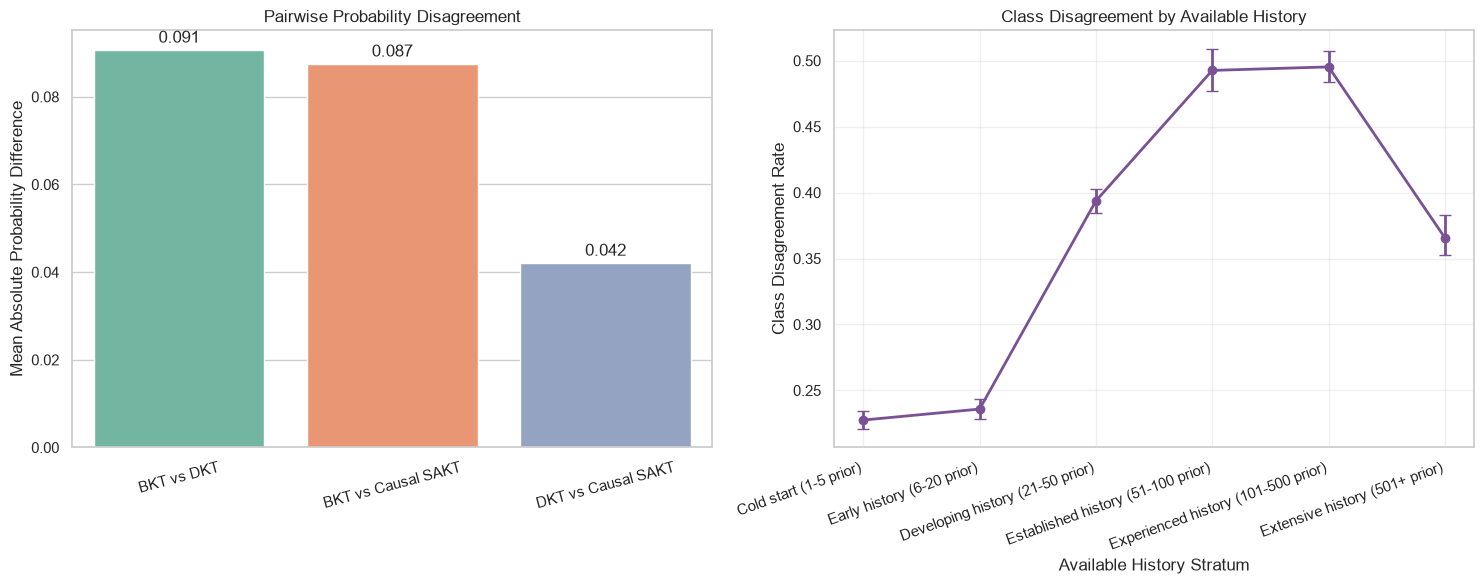

Figure saved to: /Users/tolulopesoetan/Desktop/msc_kt_ednet/results/figures/model_disagreement_analysis.png


In [65]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(
    data=pairwise_disagreement_df,
    x="Model Pair",
    y="Mean Absolute Probability Difference",
    hue="Model Pair",
    palette="Set2",
    legend=False,
    ax=axes[0],
)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.3f", padding=3)
axes[0].set_title("Pairwise Probability Disagreement")
axes[0].set_xlabel("")
axes[0].set_ylabel("Mean Absolute Probability Difference")
axes[0].tick_params(axis="x", rotation=15)

history_disagreement = disagreement_by_stratum_df[
    disagreement_by_stratum_df["Dimension"]
    == "Available History Stratum"
].set_index("Stratum").reindex(history_labels)

x_positions = np.arange(len(history_labels))
rates = history_disagreement["Class Disagreement Rate"]
lower_errors = (
    rates
    - history_disagreement[
        "Class Disagreement 95% CI Lower"
    ]
).clip(lower=0)
upper_errors = (
    history_disagreement[
        "Class Disagreement 95% CI Upper"
    ]
    - rates
).clip(lower=0)

axes[1].errorbar(
    x_positions,
    rates,
    yerr=np.vstack([lower_errors, upper_errors]),
    marker="o",
    linewidth=2,
    capsize=4,
    color="#7A5195",
)
axes[1].set_xticks(x_positions)
axes[1].set_xticklabels(
    history_labels,
    rotation=20,
    ha="right",
)
axes[1].set_title("Class Disagreement by Available History")
axes[1].set_xlabel("Available History Stratum")
axes[1].set_ylabel("Class Disagreement Rate")
axes[1].grid(alpha=0.3)

fig.tight_layout()
disagreement_figure_path = (
    FIGURES_DIR / "model_disagreement_analysis.png"
)
fig.savefig(
    disagreement_figure_path,
    dpi=300,
    bbox_inches="tight",
)
plt.show()
plt.close(fig)

print(f"Figure saved to: {disagreement_figure_path}")


## BKT Skill-Label Sensitivity Analysis

The Riiid questions can contain multiple skill tags. Alternative single-skill representations are compared on validation learners only, using models fitted to the development learners. This remains a sensitivity analysis; the shared first-tag representation is retained in the primary comparison so that all three models use the same skill definition.


In [66]:
questions_extended = pd.read_csv(
    QUESTIONS_PATH,
    usecols=["question_id", "tags", "part"],
)

questions_extended["tags"] = (
    questions_extended["tags"]
    .fillna("-1")
    .astype(str)
)

expanded_tags = questions_extended["tags"].str.split(
    " ",
    expand=True,
)

questions_extended["tag_2"] = (
    expanded_tags[1]
    if 1 in expanded_tags.columns
    else "missing_tag_2"
)

questions_extended["tag_3"] = (
    expanded_tags[2]
    if 2 in expanded_tags.columns
    else "missing_tag_3"
)

questions_extended["tag_2"] = (
    questions_extended["tag_2"]
    .fillna("missing_tag_2")
)

questions_extended["tag_3"] = (
    questions_extended["tag_3"]
    .fillna("missing_tag_3")
)

questions_extended["part_label"] = (
    "part_" + questions_extended["part"].astype(str)
)

question_metadata = questions_extended.set_index("question_id")

for dataset in [train_df, test_df]:
    dataset["tag_2"] = dataset["content_id"].map(
        question_metadata["tag_2"]
    )
    dataset["tag_3"] = dataset["content_id"].map(
        question_metadata["tag_3"]
    )
    dataset["part_label"] = dataset["content_id"].map(
        question_metadata["part_label"]
    )

required_skill_columns = [
    "tag_1",
    "tag_2",
    "tag_3",
    "part_label",
]

if train_df[required_skill_columns].isna().any().any():
    raise ValueError("Missing training skill labels were detected.")

if test_df[required_skill_columns].isna().any().any():
    raise ValueError("Missing testing skill labels were detected.")

print("Additional skill labels prepared.")


Additional skill labels prepared.


In [67]:
skill_strategies = {
    "tag_1": "First question tag",
    "tag_2": "Second question tag",
    "tag_3": "Third question tag",
    "part_label": "Question part",
}

tag_ablation_results = []

development_skill_data = train_df[
    train_df["user_id"].isin(development_user_set)
]
validation_skill_data = train_df[
    train_df["user_id"].isin(validation_user_set)
]

for skill_column, strategy_name in skill_strategies.items():
    print(f"Fitting BKT with {strategy_name.lower()}.")

    temporary_model = BKTModel(seed=SEED)
    temporary_train = development_skill_data[
        ["user_id", skill_column, "answered_correctly"]
    ].rename(columns={
        skill_column: "skill_name",
        "answered_correctly": "correct",
    })
    temporary_validation = validation_skill_data[
        ["user_id", skill_column, "answered_correctly"]
    ].rename(columns={
        skill_column: "skill_name",
        "answered_correctly": "correct",
    })

    temporary_model.fit(data=temporary_train)
    temporary_predictions = temporary_model.predict(
        data=temporary_validation
    )

    validation_auc = roc_auc_score(
        temporary_predictions["correct"],
        temporary_predictions["correct_predictions"],
    )

    tag_ablation_results.append({
        "Skill Strategy": strategy_name,
        "Column": skill_column,
        "Validation AUC": validation_auc,
        "Selection Role": "Sensitivity analysis only",
    })
    print(f"{strategy_name} validation AUC: {validation_auc:.4f}")

    del temporary_model
    del temporary_train
    del temporary_validation
    del temporary_predictions
    gc.collect()

tag_ablation_df = (
    pd.DataFrame(tag_ablation_results)
    .sort_values("Validation AUC", ascending=False)
    .reset_index(drop=True)
)

display(tag_ablation_df.round({"Validation AUC": 5}))
tag_ablation_df.to_csv(
    TABLES_DIR / "bkt_skill_label_sensitivity.csv",
    index=False,
)


Fitting BKT with first question tag.
First question tag validation AUC: 0.6341
Fitting BKT with second question tag.
Second question tag validation AUC: 0.6318
Fitting BKT with third question tag.
Third question tag validation AUC: 0.6268
Fitting BKT with question part.
Question part validation AUC: 0.6353


,Skill Strategy,Column,Validation AUC,Selection Role
0,Question part,part_label,0.63534,Sensitivity analysis only
1,First question tag,tag_1,0.63412,Sensitivity analysis only
2,Second question tag,tag_2,0.63177,Sensitivity analysis only
3,Third question tag,tag_3,0.62675,Sensitivity analysis only


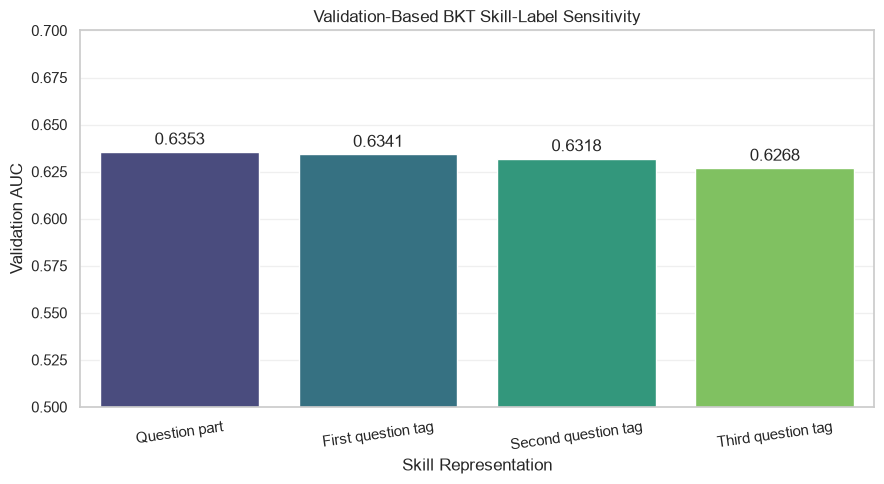

Figure saved to: /Users/tolulopesoetan/Desktop/msc_kt_ednet/results/figures/bkt_skill_label_sensitivity.png


In [68]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.barplot(
    data=tag_ablation_df,
    x="Skill Strategy",
    y="Validation AUC",
    hue="Skill Strategy",
    palette="viridis",
    legend=False,
    ax=ax,
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.4f",
        padding=3,
    )

ax.set_ylim(0.50, 0.70)
ax.set_title("Validation-Based BKT Skill-Label Sensitivity")
ax.set_xlabel("Skill Representation")
ax.set_ylabel("Validation AUC")
ax.tick_params(axis="x", rotation=8)
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()

sensitivity_figure_path = (
    FIGURES_DIR / "bkt_skill_label_sensitivity.png"
)

fig.savefig(
    sensitivity_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print(f"Figure saved to: {sensitivity_figure_path}")


## Sequence-Length Sensitivity Analysis

The maximum retained history is increased from 100 to 200 interactions while the validation-selected canonical neural architectures and three predetermined seeds are held fixed. Seed-averaged predictions from both lengths are aligned to identical target interactions before comparison.


In [69]:
ABLATION_SEQ_LEN = 200

skills_200, responses_200, users_200 = create_sequence_data(
    final_df,
    ABLATION_SEQ_LEN,
)

interactions_200 = []
target_skills_200 = []
targets_200 = []

for skill_sequence, response_sequence in zip(
    skills_200,
    responses_200,
):
    interactions_200.append(
        skill_sequence[:-1] * 2
        + response_sequence[:-1]
        + 1
    )
    target_skills_200.append(skill_sequence[1:] + 1)
    targets_200.append(response_sequence[1:])

X_200 = pad_sequences(
    interactions_200,
    maxlen=ABLATION_SEQ_LEN,
    padding="pre",
    value=0,
)
Q_200 = pad_sequences(
    target_skills_200,
    maxlen=ABLATION_SEQ_LEN,
    padding="pre",
    value=0,
)
y_200 = pad_sequences(
    targets_200,
    maxlen=ABLATION_SEQ_LEN,
    padding="pre",
    value=-1,
)

users_200 = np.asarray(users_200)
train_mask_200 = np.isin(users_200, training_users)
test_mask_200 = np.isin(users_200, testing_users)

X_train_200 = X_200[train_mask_200]
Q_train_200 = Q_200[train_mask_200]
y_train_200 = y_200[train_mask_200, :, np.newaxis]

X_test_200 = X_200[test_mask_200]
Q_test_200 = Q_200[test_mask_200]
y_test_200 = y_200[test_mask_200, :, np.newaxis]

valid_mask_200 = y_test_200[:, :, 0] != -1
y_test_clean_200 = y_test_200[:, :, 0][valid_mask_200]

if not np.array_equal(X_200 != 0, Q_200 != 0):
    raise ValueError("Sequence-200 inputs are not aligned.")

print(f"Training interaction shape: {X_train_200.shape}")
print(f"Training target-skill shape: {Q_train_200.shape}")
print(f"Testing interaction shape:  {X_test_200.shape}")


Training interaction shape: (15999, 200)
Training target-skill shape: (15999, 200)
Testing interaction shape:  (4000, 200)


In [70]:
dkt_200_seed_predictions = []
dkt_200_histories = {}

for model_seed in FINAL_MODEL_SEEDS:
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(model_seed)

    dkt_200_model = build_dkt_model(
        selected_dkt_configuration,
        sequence_length=ABLATION_SEQ_LEN,
        number_of_skills=num_skills,
        interaction_vocab_size=vocab_size,
        name_prefix=f"dkt_200_seed_{model_seed}",
    )
    history = dkt_200_model.fit(
        [X_train_200, Q_train_200],
        y_train_200,
        epochs=selected_dkt_configuration["best_epoch"],
        batch_size=64,
        shuffle=True,
        verbose=1,
    )
    prediction_matrix = dkt_200_model.predict(
        [X_test_200, Q_test_200],
        verbose=0,
    )
    dkt_200_seed_predictions.append(prediction_matrix)
    dkt_200_histories[model_seed] = history.history

    del dkt_200_model
    gc.collect()

dkt_200_predictions = np.mean(
    np.stack(dkt_200_seed_predictions, axis=0),
    axis=0,
)
dkt_200_predictions_clean = dkt_200_predictions[:, :, 0][
    valid_mask_200
]

print(
    "Seed-averaged DKT-200 predictions:",
    f"{len(dkt_200_predictions_clean):,}",
)


Epoch 1/12
250/250 ━━━━━━━━━━━━━━━━━━━━ 19s 71ms/step - loss: 0.6397
Epoch 2/12
250/250 ━━━━━━━━━━━━━━━━━━━━ 18s 70ms/step - loss: 0.6235
Epoch 3/12
250/250 ━━━━━━━━━━━━━━━━━━━━ 18s 72ms/step - loss: 0.6215
Epoch 4/12
250/250 ━━━━━━━━━━━━━━━━━━━━ 17s 69ms/step - loss: 0.6204
Epoch 5/12
250/250 ━━━━━━━━━━━━━━━━━━━━ 75s 299ms/step - loss: 0.6196
Epoch 6/12
250/250 ━━━━━━━━━━━━━━━━━━━━ 72s 288ms/step - loss: 0.6189
Epoch 7/12
250/250 ━━━━━━━━━━━━━━━━━━━━ 64s 254ms/step - loss: 0.6182
Epoch 8/12
250/250 ━━━━━━━━━━━━━━━━━━━━ 71s 285ms/step - loss: 0.6176
Epoch 9/12
250/250 ━━━━━━━━━━━━━━━━━━━━ 81s 323ms/step - loss: 0.6169
Epoch 10/12
250/250 ━━━━━━━━━━━━━━━━━━━━ 60s 239ms/step - loss: 0.6164
Epoch 11/12
250/250 ━━━━━━━━━━━━━━━━━━━━ 17s 66ms/step - loss: 0.6158
Epoch 12/12
250/250 ━━━━━━━━━━━━━━━━━━━━ 17s 66ms/step - loss: 0.6153
Epoch 1/12
250/250 ━━━━━━━━━━━━━━━━━━━━ 74s 281ms/step - loss: 0.6402
Epoch 2/12
250/250 ━━━━━━━━━━━━━━━━━━━━ 79s 315ms/step - loss: 0.6233
Epoch 3/12
250/250 ━━━━

In [71]:
sakt_200_seed_predictions = []
sakt_200_histories = {}

for model_seed in FINAL_MODEL_SEEDS:
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(model_seed)

    sakt_200_model = build_sakt_model(
        selected_sakt_configuration,
        sequence_length=ABLATION_SEQ_LEN,
        number_of_skills=num_skills,
        interaction_vocab_size=vocab_size,
        causal=True,
        name_prefix=f"sakt_200_seed_{model_seed}",
    )
    history = sakt_200_model.fit(
        [X_train_200, Q_train_200],
        y_train_200,
        epochs=selected_sakt_configuration["best_epoch"],
        batch_size=64,
        shuffle=True,
        verbose=1,
    )
    prediction_matrix = sakt_200_model.predict(
        [X_test_200, Q_test_200],
        verbose=0,
    )
    sakt_200_seed_predictions.append(prediction_matrix)
    sakt_200_histories[model_seed] = history.history

    del sakt_200_model
    gc.collect()

sakt_200_predictions = np.mean(
    np.stack(sakt_200_seed_predictions, axis=0),
    axis=0,
)
sakt_200_predictions_clean = sakt_200_predictions[:, :, 0][
    valid_mask_200
]

print(
    "Seed-averaged causal SAKT-200 predictions:",
    f"{len(sakt_200_predictions_clean):,}",
)


Epoch 1/13
250/250 ━━━━━━━━━━━━━━━━━━━━ 23s 87ms/step - loss: 0.6482
Epoch 2/13
250/250 ━━━━━━━━━━━━━━━━━━━━ 22s 90ms/step - loss: 0.6279
Epoch 3/13
250/250 ━━━━━━━━━━━━━━━━━━━━ 22s 89ms/step - loss: 0.6260
Epoch 4/13
250/250 ━━━━━━━━━━━━━━━━━━━━ 22s 89ms/step - loss: 0.6247
Epoch 5/13
250/250 ━━━━━━━━━━━━━━━━━━━━ 22s 89ms/step - loss: 0.6236
Epoch 6/13
250/250 ━━━━━━━━━━━━━━━━━━━━ 22s 88ms/step - loss: 0.6227
Epoch 7/13
250/250 ━━━━━━━━━━━━━━━━━━━━ 22s 88ms/step - loss: 0.6220
Epoch 8/13
250/250 ━━━━━━━━━━━━━━━━━━━━ 22s 87ms/step - loss: 0.6213
Epoch 9/13
250/250 ━━━━━━━━━━━━━━━━━━━━ 22s 87ms/step - loss: 0.6208
Epoch 10/13
250/250 ━━━━━━━━━━━━━━━━━━━━ 22s 88ms/step - loss: 0.6203
Epoch 11/13
250/250 ━━━━━━━━━━━━━━━━━━━━ 22s 88ms/step - loss: 0.6197
Epoch 12/13
250/250 ━━━━━━━━━━━━━━━━━━━━ 22s 88ms/step - loss: 0.6193
Epoch 13/13
250/250 ━━━━━━━━━━━━━━━━━━━━ 22s 89ms/step - loss: 0.6188
Epoch 1/13
250/250 ━━━━━━━━━━━━━━━━━━━━ 23s 87ms/step - loss: 0.6401
Epoch 2/13
250/250 ━━━━━━━━━━━

,Model,Maximum Sequence Length,Interactions,Learners,Negative Outcomes,Positive Outcomes,Decision Threshold,AUC,PR AUC,Accuracy,...,Precision,Recall,F1 Score,Brier Score,Log Loss,False Positive Rate,False Negative Rate,AUC 95% CI Lower,AUC 95% CI Upper,Completed Bootstrap Replicates
0,DKT,100,219214,4000,90487,128727,0.50000,0.68034,0.73410,0.65313,...,0.66263,0.83387,0.73845,0.21791,0.62561,0.60399,0.16613,0.67634,0.68415,200
1,DKT,200,219214,4000,90487,128727,0.50000,0.68638,0.74017,0.65564,...,0.66273,0.84214,0.74174,0.21655,0.62255,0.60968,0.15786,0.68238,0.68954,200
2,Causal SAKT,100,219214,4000,90487,128727,0.50000,0.67625,0.73022,0.65057,...,0.65655,0.84912,0.74052,0.21887,0.62771,0.63189,0.15088,0.67221,0.67961,200
3,Causal SAKT,200,219214,4000,90487,128727,0.50000,0.68020,0.73437,0.65295,...,0.65903,0.84746,0.74146,0.21796,0.62566,0.62376,0.15254,0.67603,0.68378,200


,Model,Comparison,AUC Difference,Difference 95% CI Lower,Difference 95% CI Upper,Completed Bootstrap Replicates,CI Excludes Zero
0,DKT,Length 200 minus length 100,0.00604,0.00547,0.00672,200,True
1,Causal SAKT,Length 200 minus length 100,0.00395,0.00315,0.00494,200,True


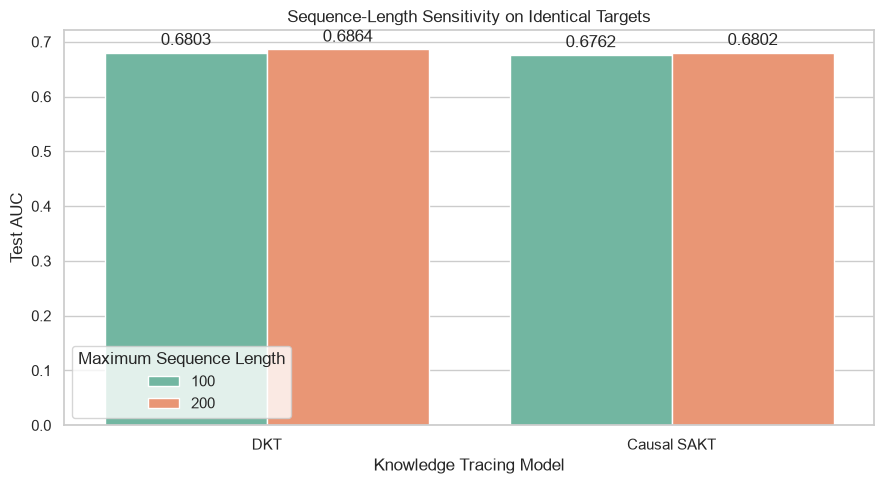

Figure saved to: /Users/tolulopesoetan/Desktop/msc_kt_ednet/results/figures/sequence_length_ablation.png


In [72]:
sequence_200_metadata = []
test_users_200 = users_200[test_mask_200]

for user_id in test_users_200:
    learner_data = test_interactions_by_user[user_id]
    retained_sequence = learner_data.tail(ABLATION_SEQ_LEN)

    if len(retained_sequence) < 2:
        continue

    sequence_200_metadata.append(
        retained_sequence.iloc[1:][
            [
                "user_id",
                "interaction_position",
                "skill",
                "answered_correctly",
            ]
        ].copy()
    )

sequence_200_metadata = pd.concat(
    sequence_200_metadata,
    ignore_index=True,
).rename(
    columns={
        "skill": "skill_id",
        "answered_correctly": "actual",
    }
)

if len(sequence_200_metadata) != len(y_test_clean_200):
    raise ValueError(
        "Sequence-200 metadata and predictions are not aligned."
    )

if not np.array_equal(
    sequence_200_metadata["actual"].astype(int).to_numpy(),
    y_test_clean_200.astype(int),
):
    raise ValueError(
        "Sequence-200 outcomes do not match the padded targets."
    )

sequence_200_prediction_table = sequence_200_metadata.copy()
sequence_200_prediction_table["dkt_probability_200"] = (
    dkt_200_predictions_clean
)
sequence_200_prediction_table["sakt_probability_200"] = (
    sakt_200_predictions_clean
)

sequence_100_prediction_table = neural_prediction_table.rename(
    columns={
        "dkt_probability": "dkt_probability_100",
        "sakt_probability": "sakt_probability_100",
    }
)

sequence_ablation_common_table = sequence_100_prediction_table.merge(
    sequence_200_prediction_table,
    on=[
        "user_id",
        "interaction_position",
        "skill_id",
        "actual",
    ],
    how="inner",
    validate="one_to_one",
)

if len(sequence_ablation_common_table) != len(
    sequence_100_prediction_table
):
    raise ValueError(
        "The sequence-length comparison lost sequence-100 targets."
    )

sequence_probability_columns = {
    ("DKT", 100): "dkt_probability_100",
    ("DKT", 200): "dkt_probability_200",
    ("Causal SAKT", 100): "sakt_probability_100",
    ("Causal SAKT", 200): "sakt_probability_200",
}

sequence_ablation_records = []
for record_number, (
    (model_name, sequence_length),
    probability_column,
) in enumerate(sequence_probability_columns.items()):
    metrics = calculate_binary_metrics(
        sequence_ablation_common_table,
        probability_column,
        decision_threshold=0.50,
    )
    ci_lower, ci_upper, completed = learner_bootstrap_auc_interval(
        sequence_ablation_common_table,
        probability_column,
        seed=SEED + 4_000 + record_number,
    )
    sequence_ablation_records.append({
        "Model": model_name,
        "Maximum Sequence Length": sequence_length,
        **metrics,
        "AUC 95% CI Lower": ci_lower,
        "AUC 95% CI Upper": ci_upper,
        "Completed Bootstrap Replicates": completed,
    })

sequence_ablation_df = pd.DataFrame(sequence_ablation_records)

sequence_length_difference_records = []
for comparison_number, (
    model_name,
    probability_200,
    probability_100,
) in enumerate([
    ("DKT", "dkt_probability_200", "dkt_probability_100"),
    (
        "Causal SAKT",
        "sakt_probability_200",
        "sakt_probability_100",
    ),
]):
    sequence_length_difference_records.append({
        "Model": model_name,
        "Comparison": "Length 200 minus length 100",
        **learner_paired_bootstrap_auc_difference(
            sequence_ablation_common_table,
            probability_200,
            probability_100,
            seed=SEED + 6_000 + comparison_number,
        ),
    })

sequence_length_paired_differences = pd.DataFrame(
    sequence_length_difference_records
)

display(sequence_ablation_df.round(5))
display(sequence_length_paired_differences.round(5))

sequence_ablation_common_table.to_csv(
    TABLES_DIR / "sequence_length_common_interactions.csv",
    index=False,
)
sequence_ablation_df.to_csv(
    TABLES_DIR / "sequence_length_ablation.csv",
    index=False,
)
sequence_length_paired_differences.to_csv(
    TABLES_DIR / "sequence_length_paired_auc_differences.csv",
    index=False,
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=sequence_ablation_df,
    x="Model",
    y="AUC",
    hue="Maximum Sequence Length",
    palette="Set2",
    ax=ax,
)
for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)
ax.set_title("Sequence-Length Sensitivity on Identical Targets")
ax.set_xlabel("Knowledge Tracing Model")
ax.set_ylabel("Test AUC")
ax.legend(title="Maximum Sequence Length")

fig.tight_layout()
ablation_figure_path = FIGURES_DIR / "sequence_length_ablation.png"
fig.savefig(ablation_figure_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Figure saved to: {ablation_figure_path}")


## Experimental Configuration and Reproducibility Ledger

The final data constraints, model configurations, and software versions are recorded to support reproducibility. Hyperparameters are taken from the validation-based tuning procedure.


In [73]:
configuration_records = [
    {
        "Category": "Data",
        "Parameter": "Student sample",
        "Value": TARGET_STUDENTS,
    },
    {"Category": "Data", "Parameter": "Sampling seed", "Value": SEED},
    {
        "Category": "Data",
        "Parameter": "Train/test method",
        "Value": "GroupShuffleSplit by learner",
    },
    {
        "Category": "Data",
        "Parameter": "Training learners",
        "Value": train_df["user_id"].nunique(),
    },
    {
        "Category": "Data",
        "Parameter": "Testing learners",
        "Value": test_df["user_id"].nunique(),
    },
    {
        "Category": "Data",
        "Parameter": "Primary sequence length",
        "Value": MAX_SEQ_LEN,
    },
    {
        "Category": "Data",
        "Parameter": "Ablation sequence length",
        "Value": ABLATION_SEQ_LEN,
    },
    {
        "Category": "Model interface",
        "Parameter": "DKT target skill",
        "Value": "Select next-skill probability from all-skill output",
    },
    {
        "Category": "Model interface",
        "Parameter": "SAKT target skill",
        "Value": "Next-skill query with historical interaction keys/values",
    },
    {
        "Category": "Training",
        "Parameter": "Final neural seeds",
        "Value": ",".join(map(str, FINAL_MODEL_SEEDS)),
    },
    {
        "Category": "Training",
        "Parameter": "Maximum tuning epochs",
        "Value": MAX_TUNING_EPOCHS,
    },
    {
        "Category": "Training",
        "Parameter": "Tuning patience",
        "Value": TUNING_PATIENCE,
    },
    {
        "Category": "DKT",
        "Parameter": "Embedding dimension",
        "Value": selected_dkt_configuration["embedding_dimension"],
    },
    {
        "Category": "DKT",
        "Parameter": "LSTM units",
        "Value": selected_dkt_configuration["lstm_units"],
    },
    {
        "Category": "DKT",
        "Parameter": "Learning rate",
        "Value": selected_dkt_configuration["learning_rate"],
    },
    {
        "Category": "DKT",
        "Parameter": "Validation-selected threshold",
        "Value": MODEL_DECISION_THRESHOLDS["DKT"],
    },
    {
        "Category": "SAKT",
        "Parameter": "Embedding dimension",
        "Value": selected_sakt_configuration["embedding_dimension"],
    },
    {
        "Category": "SAKT",
        "Parameter": "Attention heads",
        "Value": selected_sakt_configuration["attention_heads"],
    },
    {
        "Category": "SAKT",
        "Parameter": "Feed-forward dimension",
        "Value": selected_sakt_configuration["feedforward_dimension"],
    },
    {
        "Category": "SAKT",
        "Parameter": "Learning rate",
        "Value": selected_sakt_configuration["learning_rate"],
    },
    {
        "Category": "SAKT",
        "Parameter": "Validation-selected threshold",
        "Value": MODEL_DECISION_THRESHOLDS["Causal SAKT"],
    },
    {
        "Category": "BKT",
        "Parameter": "Validation-selected threshold",
        "Value": MODEL_DECISION_THRESHOLDS["BKT"],
    },
]

configuration_df = pd.DataFrame(configuration_records)
display(configuration_df)
configuration_df.to_csv(
    TABLES_DIR / "experimental_configuration.csv",
    index=False,
)


,Category,Parameter,Value
0,Data,Student sample,20000
1,Data,Sampling seed,42
2,Data,Train/test method,GroupShuffleSplit by learner
3,Data,Training learners,16000
4,Data,Testing learners,4000
5,Data,Primary sequence length,100
6,Data,Ablation sequence length,200
7,Model interface,DKT target skill,Select next-skill probability from all-skill o...
8,Model interface,SAKT target skill,Next-skill query with historical interaction k...
9,Training,Final neural seeds,"42,43,44"


In [74]:
environment_df = pd.DataFrame({
    "Package": list(installed_versions.keys()),
    "Version": list(installed_versions.values()),
})

environment_df["Python"] = (
    f"{os.sys.version_info.major}."
    f"{os.sys.version_info.minor}."
    f"{os.sys.version_info.micro}"
)
environment_df["Platform"] = os.sys.platform

if environment_df["Package"].duplicated().any():
    raise ValueError("Duplicate packages found in environment ledger.")

display(environment_df)
environment_df.to_csv(
    TABLES_DIR / "software_environment.csv",
    index=False,
)

print(f"Configuration records saved in: {TABLES_DIR}")


,Package,Version,Python,Platform
0,numpy,1.26.4,3.12.13,darwin
1,pandas,2.2.3,3.12.13,darwin
2,scipy,1.13.1,3.12.13,darwin
3,scikit-learn,1.6.1,3.12.13,darwin
4,pyBKT,1.4.2,3.12.13,darwin
5,tensorflow,2.21.0,3.12.13,darwin


Configuration records saved in: /Users/tolulopesoetan/Desktop/msc_kt_ednet/results/tables


## Evaluation Artifact Export

Artifacts are written to the project's stable `results/tables`, `results/predictions` and `results/figures` folders. Re-running the notebook updates files with the same names, and the manifest lists the artifacts currently present in those folders.


In [75]:
test_user_lengths.to_csv(
    PREDICTIONS_DIR / "test_users_strata.csv",
    index=False,
)
np.save(PREDICTIONS_DIR / "y_test_ground_truth.npy", y_test)
np.save(PREDICTIONS_DIR / "target_skill_tokens.npy", Q_test)
np.save(PREDICTIONS_DIR / "dkt_seed_mean_predictions.npy", dkt_predictions)
np.save(
    PREDICTIONS_DIR / "initial_noncausal_sakt_predictions.npy",
    initial_sakt_predictions,
)
np.save(
    PREDICTIONS_DIR / "sakt_seed_mean_predictions.npy",
    sakt_predictions,
)

for model_seed, prediction_matrix in zip(
    FINAL_MODEL_SEEDS,
    dkt_seed_prediction_matrices,
):
    np.save(
        PREDICTIONS_DIR / f"dkt_seed_{model_seed}_predictions.npy",
        prediction_matrix,
    )

for model_seed, prediction_matrix in zip(
    FINAL_MODEL_SEEDS,
    sakt_seed_prediction_matrices,
):
    np.save(
        PREDICTIONS_DIR / f"sakt_seed_{model_seed}_predictions.npy",
        prediction_matrix,
    )

base_histories = {
    "preliminary_dkt_training_history.csv": dkt_history.history,
    "initial_noncausal_sakt_training_history.csv": (
        initial_sakt_history.history
    ),
    "preliminary_causal_sakt_training_history.csv": sakt_history.history,
}

for filename, history_data in base_histories.items():
    pd.DataFrame(history_data).to_csv(
        TABLES_DIR / filename,
        index_label="epoch",
    )

for model_seed, history_data in dkt_final_histories.items():
    pd.DataFrame(history_data).to_csv(
        TABLES_DIR / f"final_dkt_seed_{model_seed}_history.csv",
        index_label="epoch",
    )

for model_seed, history_data in sakt_final_histories.items():
    pd.DataFrame(history_data).to_csv(
        TABLES_DIR / f"final_sakt_seed_{model_seed}_history.csv",
        index_label="epoch",
    )

for model_seed, history_data in dkt_200_histories.items():
    pd.DataFrame(history_data).to_csv(
        TABLES_DIR / f"dkt_200_seed_{model_seed}_history.csv",
        index_label="epoch",
    )

for model_seed, history_data in sakt_200_histories.items():
    pd.DataFrame(history_data).to_csv(
        TABLES_DIR / f"sakt_200_seed_{model_seed}_history.csv",
        index_label="epoch",
    )

print(f"Prediction arrays saved in: {PREDICTIONS_DIR}")
print(f"Training histories saved in: {TABLES_DIR}")


Prediction arrays saved in: /Users/tolulopesoetan/Desktop/msc_kt_ednet/results/predictions
Training histories saved in: /Users/tolulopesoetan/Desktop/msc_kt_ednet/results/tables


In [76]:
export_manifest = []

for directory in [TABLES_DIR, PREDICTIONS_DIR, FIGURES_DIR]:
    for path in sorted(directory.iterdir()):
        if path.is_file():
            export_manifest.append({
                "Directory": directory.name,
                "File": path.name,
                "Size (MB)": round(
                    path.stat().st_size / (1024 ** 2),
                    3,
                ),
            })

export_manifest_df = pd.DataFrame(export_manifest)
display(export_manifest_df)

export_manifest_df.to_csv(
    TABLES_DIR / "evaluation_export_manifest.csv",
    index=False,
)


,Directory,File,Size (MB)
0,tables,analysis_population_coverage.csv,0.00000
1,tables,bkt_skill_label_sensitivity.csv,0.00000
2,tables,calibration_curve_values.csv,0.00100
3,tables,common_interaction_evaluation_table.csv,12.30100
4,tables,common_subset_calibration_metrics.csv,0.00000
...,...,...,...
93,figures,phase1_roc_curves.png,0.20200
94,figures,sakt_leakage_audit.png,0.10700
95,figures,sakt_temporal_leakage_diagnostic.png,0.06700
96,figures,sequence_length_ablation.png,0.10200


## Phase 1 Findings

The primary neural models now follow their target-skill-aware formulations: DKT selects the next skill from an all-skill output vector, and SAKT queries causally masked interaction history with the next skill. Three predetermined seeds quantify initialization sensitivity, and seed-averaged probabilities support the interaction-level analyses.

The evaluation reports fixed and validation-selected thresholds, balanced classification metrics, paired learner-bootstrap AUC differences, refined history strata, rare-skill performance, sequence-length differences on identical targets, calibration and disagreement. Pairwise model and sequence-length claims are made only when the corresponding paired confidence interval excludes zero.


# Cross-Domain Configurability Extension

This section evaluates whether the existing knowledge-tracing workflow can represent and process a second educational domain. The evaluation focuses on structural, semantic and operational configurability rather than predictive validity. Simulated responses, where used, serve only as technical execution checks and do not represent real learners.

In [8]:
%pip install pyyaml openpyxl --quiet


[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Target-Domain Configuration

The target domain is defined separately from the EDNet configuration. The knowledge-component taxonomy and processing parameters are stored as domain-specific settings so that the core workflow remains reusable.

In [9]:
import json
import yaml

SFLA_CONFIG = {
    "domain": {
        "id": "sfla",
        "name": "Sets, Functions and Linear Algebra",
        "module_code": "UFMFL3-30-1",
        "provider": "University of the West of England",
        "level": "Year 1 undergraduate",
        "evaluation_mode": "cross_domain_configurability",
        "taxonomy_version": "v1",
    },
    "pipeline": {
        "seed": SEED,
        "split_by": "learner_id",
        "target_column": "correct",
        "padding_token": 0,
        "max_sequence_length": 25,
    },
    "simulation": {
        "purpose": "technical_execution_check_only",
        "data_status": "SIMULATED",
        "number_of_students": 50,
        "minimum_attempts": 15,
        "maximum_attempts": 25,
        "beta_alpha": 3,
        "beta_beta": 2,
    },
    "knowledge_components": [
        {
            "id": "KC01",
            "name": "Logical equivalence and truth tables",
        },
        {
            "id": "KC02",
            "name": "Quantifiers and statement transformations",
        },
        {
            "id": "KC03",
            "name": "Set notation and membership",
        },
        {
            "id": "KC04",
            "name": "Set operations",
        },
        {
            "id": "KC05",
            "name": "Power sets and Cartesian products",
        },
        {
            "id": "KC06",
            "name": "Set-based proof",
        },
        {
            "id": "KC07",
            "name": "Mathematical induction",
        },
        {
            "id": "KC08",
            "name": "Function properties",
        },
        {
            "id": "KC09",
            "name": "Inverse and composite functions",
        },
    ],
}

SFLA_DOMAIN = SFLA_CONFIG["domain"]["id"]
SFLA_MAX_SEQUENCE_LENGTH = SFLA_CONFIG["pipeline"][
    "max_sequence_length"
]
SFLA_KC_IDS = [
    component["id"]
    for component in SFLA_CONFIG["knowledge_components"]
]
SFLA_KC_NAMES = {
    component["id"]: component["name"]
    for component in SFLA_CONFIG["knowledge_components"]
}

SFLA_RESULTS_DIR = RESULTS_DIR / "cross_domain" / SFLA_DOMAIN
SFLA_TABLES_DIR = SFLA_RESULTS_DIR / "tables"
SFLA_FIGURES_DIR = SFLA_RESULTS_DIR / "figures"

for directory in (
    SFLA_RESULTS_DIR,
    SFLA_TABLES_DIR,
    SFLA_FIGURES_DIR,
):
    directory.mkdir(parents=True, exist_ok=True)

config_output_path = SFLA_RESULTS_DIR / "sfla_config.yaml"

with config_output_path.open("w", encoding="utf-8") as config_file:
    yaml.safe_dump(
        SFLA_CONFIG,
        config_file,
        sort_keys=False,
        allow_unicode=True,
    )

print(f"Domain: {SFLA_CONFIG['domain']['name']}")
print(f"Module: {SFLA_CONFIG['domain']['module_code']}")
print(f"Evaluation mode: {SFLA_CONFIG['domain']['evaluation_mode']}")
print(f"Taxonomy version: {SFLA_CONFIG['domain']['taxonomy_version']}")
print(f"Knowledge components: {len(SFLA_KC_IDS)}")
print(f"Configuration saved to: {config_output_path}")

Domain: Sets, Functions and Linear Algebra
Module: UFMFL3-30-1
Evaluation mode: cross_domain_configurability
Taxonomy version: v1
Knowledge components: 9
Configuration saved to: /Users/tolulopesoetan/Desktop/msc_kt_ednet/results/cross_domain/sfla/sfla_config.yaml


## SFLA Item Register

The item register contains the marked assessment subparts from the 2019 development paper and the 2020 challenge paper. Each eligible item is assigned to one knowledge component from taxonomy version 1.

In [10]:
SFLA_ITEM_REGISTER_FILENAME = "SFLA_Item_Register_v1.xlsx"

item_register_path = (
    PROCESSED_DATA_DIR / SFLA_ITEM_REGISTER_FILENAME
)

if not item_register_path.exists():
    raise FileNotFoundError(
        f"{SFLA_ITEM_REGISTER_FILENAME} was not found.\n"
        f"Expected location: {item_register_path}\n"
        "Copy the item register into data/processed and rerun this cell."
    )

print(
    "Item register found:",
    item_register_path.relative_to(PROJECT_ROOT),
)

Item register found: data/processed/SFLA_Item_Register_v1.xlsx


In [11]:
SFLA_ITEM_MAP_SHEET = "sfla_item_skill_map_v1"

excel_file = pd.ExcelFile(item_register_path)

if SFLA_ITEM_MAP_SHEET not in excel_file.sheet_names:
    raise ValueError(
        f"Sheet '{SFLA_ITEM_MAP_SHEET}' was not found.\n"
        f"Available sheets: {excel_file.sheet_names}"
    )

sfla_item_register = pd.read_excel(
    item_register_path,
    sheet_name=SFLA_ITEM_MAP_SHEET,
)

sfla_item_register.columns = (
    sfla_item_register.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

if "skill_id" in sfla_item_register.columns:
    sfla_item_register["skill_id"] = (
        sfla_item_register["skill_id"]
        .astype("string")
        .str.strip()
    )

if "mapping_status" in sfla_item_register.columns:
    sfla_item_register["mapping_status"] = (
        sfla_item_register["mapping_status"]
        .astype("string")
        .str.strip()
        .str.upper()
    )

if "paper_year" in sfla_item_register.columns:
    sfla_item_register["paper_year"] = pd.to_numeric(
        sfla_item_register["paper_year"],
        errors="coerce",
    ).astype("Int64")

print(f"Workbook: {item_register_path.name}")
print(f"Sheet: {SFLA_ITEM_MAP_SHEET}")
print(f"Rows loaded: {len(sfla_item_register)}")
print(f"Columns loaded: {len(sfla_item_register.columns)}")
print()
print("Available columns:")
print(sfla_item_register.columns.tolist())

display(sfla_item_register.head())

Workbook: SFLA_Item_Register_v1.xlsx
Sheet: sfla_item_skill_map_v1
Rows loaded: 32
Columns loaded: 7

Available columns:
['item_id', 'paper_year', 'skill_id', 'max_mark', 'compulsory', 'mapping_status', 'domain']


,item_id,paper_year,skill_id,max_mark,compulsory,mapping_status,domain
0,SFLA_2019_Q1a_i,2019,KC01,6,Optional,MATCHED,sfla
1,SFLA_2019_Q1b,2019,KC02,2,Optional,MATCHED,sfla
2,SFLA_2019_Q1c,2019,KC02,2,Optional,MATCHED,sfla
3,SFLA_2019_Q2_i,2019,KC03,1,Optional,MATCHED,sfla
4,SFLA_2019_Q2_ii,2019,KC04,1,Optional,MATCHED,sfla


## Item-Register Schema Validation

The item register is validated before analysis. Validation checks column availability, item uniqueness, knowledge-component identifiers, paper years, marks and domain labels.

In [12]:
print("=== SFLA Item-Register Schema Validation ===")

required_item_columns = {
    "item_id",
    "paper_year",
    "skill_id",
    "max_mark",
    "compulsory",
    "mapping_status",
    "domain",
}

schema_errors = []

missing_columns = (
    required_item_columns
    - set(sfla_item_register.columns)
)

if missing_columns:
    schema_errors.append(
        "Missing required columns: "
        + ", ".join(sorted(missing_columns))
    )

if not missing_columns:
    if sfla_item_register["item_id"].isna().any():
        schema_errors.append("Null item_id values were found.")

    if sfla_item_register["item_id"].duplicated().any():
        duplicate_items = (
            sfla_item_register.loc[
                sfla_item_register["item_id"].duplicated(
                    keep=False
                ),
                "item_id",
            ]
            .astype(str)
            .tolist()
        )

        schema_errors.append(
            f"Duplicate item_id values: {duplicate_items}"
        )

    valid_mapping_statuses = {
        "MATCHED",
        "AMBIGUOUS",
        "UNMATCHED",
    }

    invalid_statuses = set(
        sfla_item_register["mapping_status"]
        .dropna()
        .unique()
    ) - valid_mapping_statuses

    if invalid_statuses:
        schema_errors.append(
            "Invalid mapping statuses: "
            + ", ".join(sorted(invalid_statuses))
        )

    matched_items_mask = (
        sfla_item_register["mapping_status"] == "MATCHED"
    )

    if sfla_item_register.loc[
        matched_items_mask,
        "skill_id",
    ].isna().any():
        schema_errors.append(
            "Matched items contain null skill_id values."
        )

    assigned_skill_ids = set(
        sfla_item_register.loc[
            sfla_item_register["skill_id"].notna(),
            "skill_id",
        ]
    )

    invalid_skill_ids = (
        assigned_skill_ids - set(SFLA_KC_IDS)
    )

    if invalid_skill_ids:
        schema_errors.append(
            "Invalid skill IDs: "
            + ", ".join(sorted(invalid_skill_ids))
        )

    expected_paper_years = {2019, 2020}

    observed_paper_years = set(
        sfla_item_register["paper_year"]
        .dropna()
        .astype(int)
        .unique()
    )

    unexpected_years = (
        observed_paper_years - expected_paper_years
    )

    if unexpected_years:
        schema_errors.append(
            "Unexpected paper years: "
            + ", ".join(
                map(str, sorted(unexpected_years))
            )
        )

    numeric_marks = pd.to_numeric(
        sfla_item_register["max_mark"],
        errors="coerce",
    )

    if numeric_marks.isna().any():
        schema_errors.append(
            "Some max_mark values are not numeric."
        )
    elif (numeric_marks <= 0).any():
        schema_errors.append(
            "All max_mark values must be greater than zero."
        )

    invalid_domains = set(
        sfla_item_register["domain"]
        .dropna()
        .astype(str)
        .str.strip()
        .str.lower()
        .unique()
    ) - {SFLA_DOMAIN.lower()}

    if invalid_domains:
        schema_errors.append(
            "Unexpected domain labels: "
            + ", ".join(sorted(invalid_domains))
        )

if schema_errors:
    for error in schema_errors:
        print(f"FAIL: {error}")

    raise ValueError(
        "SFLA item-register validation failed."
    )

sfla_item_map = (
    sfla_item_register.loc[
        sfla_item_register["mapping_status"] == "MATCHED"
    ]
    .copy()
    .reset_index(drop=True)
)

print("All schema checks PASSED.")
print(f"Total register rows: {len(sfla_item_register)}")
print(f"Matched items: {len(sfla_item_map)}")
print(
    "Knowledge components represented:",
    sfla_item_map["skill_id"].nunique(),
    f"/ {len(SFLA_KC_IDS)}",
)
print(
    "Paper years:",
    sorted(
        sfla_item_map["paper_year"]
        .astype(int)
        .unique()
    ),
)

=== SFLA Item-Register Schema Validation ===
All schema checks PASSED.
Total register rows: 32
Matched items: 32
Knowledge components represented: 9 / 9
Paper years: [2019, 2020]


## Knowledge-Component Coverage

This summary measures how the 32 assessment items are distributed across the frozen nine-component taxonomy. Counts are reported separately for the 2019 development paper and the 2020 challenge paper.


In [13]:
sfla_taxonomy_df = pd.DataFrame(
    SFLA_CONFIG["knowledge_components"]
).rename(
    columns={
        "id": "skill_id",
        "name": "knowledge_component",
    }
)

items_by_year = (
    sfla_item_map
    .groupby(
        ["skill_id", "paper_year"],
        observed=True,
    )
    .size()
    .unstack(fill_value=0)
    .reindex(columns=[2019, 2020], fill_value=0)
    .rename(
        columns={
            2019: "2019_items",
            2020: "2020_items",
        }
    )
    .reset_index()
)

marks_by_skill = (
    sfla_item_map
    .assign(
        max_mark=lambda data: pd.to_numeric(
            data["max_mark"],
            errors="coerce",
        )
    )
    .groupby(
        "skill_id",
        observed=True,
    )["max_mark"]
    .sum()
    .rename("total_marks")
    .reset_index()
)

sfla_taxonomy_summary = (
    sfla_taxonomy_df
    .merge(
        items_by_year,
        on="skill_id",
        how="left",
    )
    .merge(
        marks_by_skill,
        on="skill_id",
        how="left",
    )
)

count_columns = [
    "2019_items",
    "2020_items",
    "total_marks",
]

sfla_taxonomy_summary[count_columns] = (
    sfla_taxonomy_summary[count_columns]
    .fillna(0)
    .astype(int)
)

sfla_taxonomy_summary["total_items"] = (
    sfla_taxonomy_summary["2019_items"]
    + sfla_taxonomy_summary["2020_items"]
)

sfla_taxonomy_summary = sfla_taxonomy_summary[
    [
        "skill_id",
        "knowledge_component",
        "2019_items",
        "2020_items",
        "total_items",
        "total_marks",
    ]
]

taxonomy_summary_path = (
    SFLA_TABLES_DIR
    / "sfla_knowledge_component_coverage.csv"
)

sfla_taxonomy_summary.to_csv(
    taxonomy_summary_path,
    index=False,
)

display(sfla_taxonomy_summary)

print(
    "Total items represented:",
    sfla_taxonomy_summary["total_items"].sum(),
)
print(
    "Knowledge components represented:",
    (
        sfla_taxonomy_summary["total_items"] > 0
    ).sum(),
    f"/ {len(SFLA_KC_IDS)}",
)
print(f"Coverage table saved to: {taxonomy_summary_path}")

,skill_id,knowledge_component,2019_items,2020_items,total_items,total_marks
0,KC01,Logical equivalence and truth tables,1,1,2,11
1,KC02,Quantifiers and statement transformations,2,2,4,7
2,KC03,Set notation and membership,2,2,4,5
3,KC04,Set operations,3,2,5,6
4,KC05,Power sets and Cartesian products,2,3,5,11
5,KC06,Set-based proof,1,1,2,10
6,KC07,Mathematical induction,1,1,2,10
7,KC08,Function properties,2,2,4,9
8,KC09,Inverse and composite functions,2,2,4,11


Total items represented: 32
Knowledge components represented: 9 / 9
Coverage table saved to: /Users/tolulopesoetan/Desktop/msc_kt_ednet/results/cross_domain/sfla/tables/sfla_knowledge_component_coverage.csv


## Development and Challenge-Paper Mapping

The 2019 paper is treated as the taxonomy-development source. Taxonomy version 1 is then held fixed while the 2020 paper is treated as an unseen challenge paper. Mapping coverage measures the proportion of eligible items assigned to the frozen taxonomy.

In [14]:
paper_labels = {
    2019: "2019 Development Paper",
    2020: "2020 Challenge Paper",
}

coverage_records = []

for paper_year, paper_label in paper_labels.items():
    paper_items = sfla_item_register.loc[
        sfla_item_register["paper_year"] == paper_year
    ].copy()

    total_items = len(paper_items)

    matched_items = (
        paper_items["mapping_status"] == "MATCHED"
    ).sum()

    ambiguous_items = (
        paper_items["mapping_status"] == "AMBIGUOUS"
    ).sum()

    unmatched_items = (
        paper_items["mapping_status"] == "UNMATCHED"
    ).sum()

    mapping_coverage = (
        matched_items / total_items
        if total_items > 0
        else np.nan
    )

    coverage_records.append({
        "paper_year": paper_year,
        "paper_role": paper_label,
        "total_items": total_items,
        "matched_items": int(matched_items),
        "ambiguous_items": int(ambiguous_items),
        "unmatched_items": int(unmatched_items),
        "mapping_coverage": mapping_coverage,
    })

sfla_mapping_coverage = pd.DataFrame(
    coverage_records
)

sfla_mapping_coverage[
    "mapping_coverage_percentage"
] = (
    sfla_mapping_coverage["mapping_coverage"]
    * 100
)

coverage_report_path = (
    SFLA_TABLES_DIR
    / "sfla_mapping_coverage.csv"
)

sfla_mapping_coverage.to_csv(
    coverage_report_path,
    index=False,
)

display(
    sfla_mapping_coverage[
        [
            "paper_role",
            "total_items",
            "matched_items",
            "ambiguous_items",
            "unmatched_items",
            "mapping_coverage_percentage",
        ]
    ].round({
        "mapping_coverage_percentage": 2,
    })
)

development_coverage = (
    sfla_mapping_coverage.loc[
        sfla_mapping_coverage["paper_year"] == 2019,
        "mapping_coverage",
    ].iloc[0]
)

challenge_coverage = (
    sfla_mapping_coverage.loc[
        sfla_mapping_coverage["paper_year"] == 2020,
        "mapping_coverage",
    ].iloc[0]
)

print(f"2019 development coverage: {development_coverage:.2%}")
print(f"2020 challenge coverage: {challenge_coverage:.2%}")
print(f"Coverage report saved to: {coverage_report_path}")

,paper_role,total_items,matched_items,ambiguous_items,unmatched_items,mapping_coverage_percentage
0,2019 Development Paper,16,16,0,0,100.00000
1,2020 Challenge Paper,16,16,0,0,100.00000


2019 development coverage: 100.00%
2020 challenge coverage: 100.00%
Coverage report saved to: /Users/tolulopesoetan/Desktop/msc_kt_ednet/results/cross_domain/sfla/tables/sfla_mapping_coverage.csv


## Simulated Interaction Smoke Test

A small simulated interaction dataset is generated solely to verify that the target-domain schema can pass through learner-level splitting and the BKT, DKT and SAKT execution interfaces. These responses do not represent real students and cannot be used to make claims about predictive validity, model superiority or learning outcomes.

The simulation assumes independent learner-skill probabilities and does not model genuine learning, forgetting, item difficulty or prerequisite relationships.

In [15]:
simulation_settings = SFLA_CONFIG["simulation"]

SFLA_DATA_STATUS = simulation_settings["data_status"]
SFLA_NUMBER_OF_STUDENTS = simulation_settings[
    "number_of_students"
]
SFLA_MINIMUM_ATTEMPTS = simulation_settings[
    "minimum_attempts"
]
SFLA_MAXIMUM_ATTEMPTS = simulation_settings[
    "maximum_attempts"
]

sfla_rng = np.random.default_rng(SEED)

simulated_records = []

print(
    "Generating simulated learner sequences "
    "for technical execution testing."
)
print(f"Data status: {SFLA_DATA_STATUS}")

for student_index in range(
    SFLA_NUMBER_OF_STUDENTS
):
    learner_id = f"SIM_{student_index:04d}"

    learner_skill_probabilities = {
        skill_id: float(
            sfla_rng.beta(
                simulation_settings["beta_alpha"],
                simulation_settings["beta_beta"],
            )
        )
        for skill_id in SFLA_KC_IDS
    }

    number_of_attempts = int(
        sfla_rng.integers(
            SFLA_MINIMUM_ATTEMPTS,
            SFLA_MAXIMUM_ATTEMPTS + 1,
        )
    )

    sampled_items = sfla_item_map.sample(
        n=number_of_attempts,
        replace=True,
        random_state=int(
            sfla_rng.integers(0, 1_000_000)
        ),
    ).reset_index(drop=True)

    for attempt_index, item in sampled_items.iterrows():
        skill_id = item["skill_id"]

        simulated_correctness = int(
            sfla_rng.binomial(
                1,
                learner_skill_probabilities[skill_id],
            )
        )

        simulated_records.append({
            "learner_id": learner_id,
            "item_id": item["item_id"],
            "skill_id": skill_id,
            "attempt_order": attempt_index + 1,
            "correct": simulated_correctness,
            "attempted": 1,
            "paper_year": int(item["paper_year"]),
            "domain": SFLA_DOMAIN,
            "data_status": SFLA_DATA_STATUS,
        })

sfla_interactions = pd.DataFrame(
    simulated_records
)

print(
    "Generated interactions:",
    f"{len(sfla_interactions):,}",
)
print(
    "Unique simulated learners:",
    sfla_interactions["learner_id"].nunique(),
)
print(
    "Skills represented:",
    sfla_interactions["skill_id"].nunique(),
    f"/ {len(SFLA_KC_IDS)}",
)
print(
    "Simulated mean correctness:",
    f"{sfla_interactions['correct'].mean():.3f}",
)

display(sfla_interactions.head())

Generating simulated learner sequences for technical execution testing.
Data status: SIMULATED
Generated interactions: 1,029
Unique simulated learners: 50
Skills represented: 9 / 9
Simulated mean correctness: 0.615


,learner_id,item_id,skill_id,attempt_order,correct,attempted,paper_year,domain,data_status
0,SIM_0000,SFLA_2019_Q2_iii,KC04,1,0,1,2019,sfla,SIMULATED
1,SIM_0000,SFLA_2020_Q3a,KC06,2,1,1,2020,sfla,SIMULATED
2,SIM_0000,SFLA_2020_Q2_iv,KC05,3,1,1,2020,sfla,SIMULATED
3,SIM_0000,SFLA_2019_Q4a,KC08,4,1,1,2019,sfla,SIMULATED
4,SIM_0000,SFLA_2019_Q4b,KC09,5,0,1,2019,sfla,SIMULATED


In [16]:
print("=== Simulated Interaction Schema Validation ===")

interaction_schema_errors = []

required_interaction_columns = {
    "learner_id",
    "item_id",
    "skill_id",
    "attempt_order",
    "correct",
    "attempted",
    "paper_year",
    "domain",
    "data_status",
}

missing_interaction_columns = (
    required_interaction_columns
    - set(sfla_interactions.columns)
)

if missing_interaction_columns:
    interaction_schema_errors.append(
        "Missing columns: "
        + ", ".join(
            sorted(missing_interaction_columns)
        )
    )

if not missing_interaction_columns:
    if sfla_interactions[
        "learner_id"
    ].isna().any():
        interaction_schema_errors.append(
            "Null learner_id values were found."
        )

    if sfla_interactions[
        "item_id"
    ].isna().any():
        interaction_schema_errors.append(
            "Null item_id values were found."
        )

    if not sfla_interactions[
        "correct"
    ].isin([0, 1]).all():
        interaction_schema_errors.append(
            "correct must contain only 0 and 1."
        )

    if not sfla_interactions[
        "attempted"
    ].isin([0, 1]).all():
        interaction_schema_errors.append(
            "attempted must contain only 0 and 1."
        )

    if (
        sfla_interactions["attempt_order"] < 1
    ).any():
        interaction_schema_errors.append(
            "attempt_order must start from 1."
        )

    if not sfla_interactions[
        "skill_id"
    ].isin(SFLA_KC_IDS).all():
        interaction_schema_errors.append(
            "Invalid skill_id values were found."
        )

    if not sfla_interactions[
        "domain"
    ].eq(SFLA_DOMAIN).all():
        interaction_schema_errors.append(
            "Unexpected domain values were found."
        )

    if not sfla_interactions[
        "data_status"
    ].eq("SIMULATED").all():
        interaction_schema_errors.append(
            "Every row must be labelled SIMULATED."
        )

    expected_attempt_order = (
        sfla_interactions
        .sort_values(
            ["learner_id", "attempt_order"]
        )
        .groupby("learner_id")
        .cumcount()
        .add(1)
    )

    actual_attempt_order = (
        sfla_interactions
        .sort_values(
            ["learner_id", "attempt_order"]
        )["attempt_order"]
    )

    if not np.array_equal(
        expected_attempt_order.to_numpy(),
        actual_attempt_order.to_numpy(),
    ):
        interaction_schema_errors.append(
            "attempt_order is not sequential "
            "within every learner."
        )

if interaction_schema_errors:
    for error in interaction_schema_errors:
        print(f"FAIL: {error}")

    raise ValueError(
        "Simulated interaction validation failed."
    )

sfla_skill_interaction_summary = (
    sfla_interactions
    .groupby(
        "skill_id",
        observed=True,
    )["correct"]
    .agg(
        interaction_count="count",
        simulated_correctness_rate="mean",
    )
    .reset_index()
    .merge(
        sfla_taxonomy_df,
        on="skill_id",
        how="left",
    )
)

print("All interaction schema checks PASSED.")
print(f"Rows: {len(sfla_interactions):,}")
print(
    "Learners:",
    sfla_interactions["learner_id"].nunique(),
)
print(
    "Skills:",
    sfla_interactions["skill_id"].nunique(),
)

display(
    sfla_skill_interaction_summary.round({
        "simulated_correctness_rate": 3,
    })
)

=== Simulated Interaction Schema Validation ===
All interaction schema checks PASSED.
Rows: 1,029
Learners: 50
Skills: 9


,skill_id,interaction_count,simulated_correctness_rate,knowledge_component
0,KC01,65,0.66200,Logical equivalence and truth tables
1,KC02,115,0.67000,Quantifiers and statement transformations
2,KC03,131,0.55000,Set notation and membership
3,KC04,174,0.50600,Set operations
4,KC05,154,0.69500,Power sets and Cartesian products
5,KC06,53,0.67900,Set-based proof
6,KC07,56,0.57100,Mathematical induction
7,KC08,128,0.59400,Function properties
8,KC09,153,0.66700,Inverse and composite functions


## Simulated Learner-Level Split

The simulated interactions are separated by learner rather than by individual interaction. This prevents the same simulated learner from appearing in both the training and test sets.

In [17]:
sfla_group_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=SEED,
)

sfla_train_indices, sfla_test_indices = next(
    sfla_group_split.split(
        sfla_interactions,
        groups=sfla_interactions["learner_id"],
    )
)

sfla_train = (
    sfla_interactions
    .iloc[sfla_train_indices]
    .copy()
    .sort_values(
        ["learner_id", "attempt_order"]
    )
    .reset_index(drop=True)
)

sfla_test = (
    sfla_interactions
    .iloc[sfla_test_indices]
    .copy()
    .sort_values(
        ["learner_id", "attempt_order"]
    )
    .reset_index(drop=True)
)

sfla_training_learners = set(
    sfla_train["learner_id"].unique()
)

sfla_test_learners = set(
    sfla_test["learner_id"].unique()
)

sfla_learner_overlap = (
    sfla_training_learners
    & sfla_test_learners
)

if sfla_learner_overlap:
    raise ValueError(
        "Learner leakage detected between the "
        "SFLA training and test sets."
    )

print("=== SFLA Simulated Train/Test Split ===")
print(
    "Training interactions:",
    f"{len(sfla_train):,}",
)
print(
    "Training learners:",
    sfla_train["learner_id"].nunique(),
)
print(
    "Test interactions:",
    f"{len(sfla_test):,}",
)
print(
    "Test learners:",
    sfla_test["learner_id"].nunique(),
)
print(
    "Learner overlap:",
    len(sfla_learner_overlap),
)
print("Leakage check: PASSED")

=== SFLA Simulated Train/Test Split ===
Training interactions: 822
Training learners: 40
Test interactions: 207
Test learners: 10
Learner overlap: 0
Leakage check: PASSED


## BKT Target-Domain Execution Check

BKT is fitted to the simulated interactions only to verify that the target-domain skill identifiers and learner sequences are accepted by the existing modelling interface. The resulting diagnostic AUC is not treated as evidence of predictive validity.

In [18]:
sfla_bkt_training_data = (
    sfla_train[
        [
            "learner_id",
            "skill_id",
            "correct",
        ]
    ]
    .rename(
        columns={
            "learner_id": "user_id",
            "skill_id": "skill_name",
        }
    )
)

sfla_bkt_test_data = (
    sfla_test[
        [
            "learner_id",
            "skill_id",
            "correct",
        ]
    ]
    .rename(
        columns={
            "learner_id": "user_id",
            "skill_id": "skill_name",
        }
    )
)

print(
    "Fitting BKT to the simulated SFLA "
    "training interactions."
)

sfla_bkt_model = BKTModel(
    seed=SEED,
    num_fits=1,
    parallel=False,
)

sfla_bkt_model.fit(
    data=sfla_bkt_training_data
)

sfla_bkt_predictions = sfla_bkt_model.predict(
    data=sfla_bkt_test_data
)

sfla_bkt_prediction_count = len(
    sfla_bkt_predictions
)

sfla_bkt_predictions = (
    sfla_bkt_predictions
    .dropna(
        subset=["correct_predictions"]
    )
    .reset_index(drop=True)
)

sfla_bkt_missing_predictions = (
    sfla_bkt_prediction_count
    - len(sfla_bkt_predictions)
)

sfla_bkt_prediction_coverage = (
    len(sfla_bkt_predictions)
    / sfla_bkt_prediction_count
)

sfla_bkt_diagnostic_auc = roc_auc_score(
    sfla_bkt_predictions["correct"],
    sfla_bkt_predictions[
        "correct_predictions"
    ],
)

print("BKT execution: SUCCESSFUL")
print(
    "Prediction coverage:",
    f"{sfla_bkt_prediction_coverage:.2%}",
)
print(
    "Missing predictions:",
    sfla_bkt_missing_predictions,
)
print(
    "Diagnostic AUC:",
    f"{sfla_bkt_diagnostic_auc:.4f}",
)
print(
    "Interpretation: execution check only; "
    "not a predictive-validity result."
)

Fitting BKT to the simulated SFLA training interactions.
BKT execution: SUCCESSFUL
Prediction coverage: 100.00%
Missing predictions: 0
Diagnostic AUC: 0.6179
Interpretation: execution check only; not a predictive-validity result.


In [19]:
from datetime import datetime, timezone
import json


print("Exporting fitted SFLA BKT parameters.")

sfla_bkt_parameter_table = (
    sfla_bkt_model
    .params()
    .reset_index()
)

required_parameter_columns = {
    "skill",
    "param",
    "class",
    "value",
}

missing_parameter_columns = (
    required_parameter_columns
    - set(sfla_bkt_parameter_table.columns)
)

if missing_parameter_columns:
    raise ValueError(
        "Unexpected pyBKT parameter structure. "
        "Missing columns: "
        f"{sorted(missing_parameter_columns)}"
    )


default_parameter_rows = (
    sfla_bkt_parameter_table.loc[
        sfla_bkt_parameter_table["class"]
        .astype(str)
        .str.lower()
        == "default"
    ]
    .copy()
)


pybkt_parameter_mapping = {
    "prior": "initial_mastery",
    "learns": "learning_probability",
    "guesses": "guess_probability",
    "slips": "slip_probability",
    "forgets": "forget_probability",
}

required_pybkt_parameters = set(
    pybkt_parameter_mapping
)


exported_skill_parameters = {}

for skill_id in sorted(SFLA_KC_IDS):
    skill_parameter_rows = (
        default_parameter_rows.loc[
            default_parameter_rows["skill"]
            .astype(str)
            == str(skill_id)
        ]
    )

    available_parameters = set(
        skill_parameter_rows["param"]
        .astype(str)
    )

    missing_parameters = (
        required_pybkt_parameters
        - available_parameters
    )

    if missing_parameters:
        raise ValueError(
            f"{skill_id} is missing fitted parameters: "
            f"{sorted(missing_parameters)}"
        )

    duplicate_parameters = (
        skill_parameter_rows[
            "param"
        ].duplicated()
    )

    if duplicate_parameters.any():
        duplicated_names = (
            skill_parameter_rows.loc[
                duplicate_parameters,
                "param",
            ]
            .astype(str)
            .tolist()
        )

        raise ValueError(
            f"{skill_id} contains duplicated parameters: "
            f"{duplicated_names}"
        )

    skill_values = (
        skill_parameter_rows
        .set_index("param")["value"]
        .to_dict()
    )

    application_parameters = {
        application_name: float(
            skill_values[pybkt_name]
        )
        for pybkt_name, application_name
        in pybkt_parameter_mapping.items()
    }

    invalid_values = {
        parameter_name: parameter_value
        for parameter_name, parameter_value
        in application_parameters.items()
        if not 0 <= parameter_value <= 1
    }

    if invalid_values:
        raise ValueError(
            f"{skill_id} contains invalid probabilities: "
            f"{invalid_values}"
        )

    exported_skill_parameters[
        skill_id
    ] = application_parameters


if set(exported_skill_parameters) != set(
    SFLA_KC_IDS
):
    raise ValueError(
        "Not all SFLA knowledge components were exported."
    )


sfla_bkt_parameter_artifact = {
    "schema_version": 1,
    "model": "BKT",
    "domain": SFLA_DOMAIN,
    "domain_name": SFLA_CONFIG[
        "domain"
    ]["name"],
    "module_code": SFLA_CONFIG[
        "domain"
    ]["module_code"],
    "taxonomy_version": SFLA_CONFIG[
        "domain"
    ]["taxonomy_version"],
    "parameter_scope": "per_skill",
    "data_status": SFLA_DATA_STATUS,
    "training_interactions": int(
        len(sfla_bkt_training_data)
    ),
    "training_learners": int(
        sfla_bkt_training_data[
            "user_id"
        ].nunique()
    ),
    "generated_at_utc": datetime.now(
        timezone.utc
    ).isoformat(),
    "validity_interpretation": (
        "Parameters fitted to simulated SFLA "
        "interactions for prototype execution only; "
        "not established predictive validity."
    ),
    "skills": exported_skill_parameters,
}


sfla_model_directory = (
    PROJECT_ROOT
    / "models"
    / "sfla"
)

sfla_model_directory.mkdir(
    parents=True,
    exist_ok=True,
)

sfla_bkt_parameter_path = (
    sfla_model_directory
    / "sfla_bkt_parameters.json"
)

with sfla_bkt_parameter_path.open(
    "w",
    encoding="utf-8",
) as parameter_file:
    json.dump(
        sfla_bkt_parameter_artifact,
        parameter_file,
        indent=2,
        sort_keys=True,
    )


exported_parameter_display = (
    pd.DataFrame
    .from_dict(
        exported_skill_parameters,
        orient="index",
    )
    .rename_axis("skill_id")
    .reset_index()
)


print("=== SFLA BKT Parameter Export ===")
print(
    "Knowledge components exported:",
    len(exported_skill_parameters),
)
print(
    "Data status:",
    SFLA_DATA_STATUS,
)
print(
    "Parameter scope:",
    "Per knowledge component",
)
print(
    "Validity:",
    "PROTOTYPE EXECUTION ONLY",
)
print(
    "Saved to:",
    sfla_bkt_parameter_path,
)

display(
    exported_parameter_display.round(4)
)

Exporting fitted SFLA BKT parameters.
=== SFLA BKT Parameter Export ===
Knowledge components exported: 9
Data status: SIMULATED
Parameter scope: Per knowledge component
Validity: PROTOTYPE EXECUTION ONLY
Saved to: /Users/tolulopesoetan/Desktop/msc_kt_ednet/models/sfla/sfla_bkt_parameters.json


,skill_id,initial_mastery,learning_probability,guess_probability,slip_probability,forget_probability
0,KC01,0.39650,0.01910,0.46340,0.07170,0.00000
1,KC02,0.12100,0.26880,0.51880,0.05130,0.00000
2,KC03,0.33910,0.04030,0.40610,0.20220,0.00000
3,KC04,0.46470,0.05810,0.33690,0.29780,0.00000
4,KC05,0.49970,0.20660,0.37080,0.12890,0.00000
5,KC06,0.15000,0.35300,0.52070,0.10120,0.00000
6,KC07,0.38620,0.09180,0.33340,0.16900,0.00000
7,KC08,0.19920,0.02410,0.49920,0.08370,0.00000
8,KC09,0.41300,0.11410,0.52180,0.17640,0.00000


## Leakage-Free Neural Sequence Preparation

For each learner, the interaction at time \(t\) is used to predict correctness at time \(t+1\). The current target response is therefore excluded from its own input token.

In [25]:
# Recreate the canonical DKT and SAKT model definitions.

import tensorflow as tf

from tensorflow.keras.layers import (
    Add,
    Dense,
    Dropout,
    Embedding,
    Input,
    Layer,
    LayerNormalization,
    LSTM,
    MultiHeadAttention,
)
from tensorflow.keras.models import Model as KerasModel
from tensorflow.keras.optimizers import Adam


def masked_binary_crossentropy(y_true, y_pred):
    y_true_float = tf.cast(
        y_true,
        y_pred.dtype,
    )

    valid_targets = tf.maximum(
        y_true_float,
        0.0,
    )

    loss = tf.keras.losses.binary_crossentropy(
        valid_targets,
        y_pred,
    )

    mask = tf.cast(
        tf.not_equal(y_true_float, -1.0),
        dtype=tf.float32,
    )

    mask = tf.squeeze(
        mask,
        axis=-1,
    )

    return tf.reduce_sum(loss * mask) / (
        tf.reduce_sum(mask) + 1e-8
    )


class SelectSkillProbability(Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.supports_masking = True

    def call(self, inputs):
        (
            all_skill_probabilities,
            target_skill_tokens,
        ) = inputs

        target_skill_indices = tf.maximum(
            target_skill_tokens - 1,
            0,
        )

        selected_probabilities = tf.gather(
            all_skill_probabilities,
            target_skill_indices,
            axis=2,
            batch_dims=2,
        )

        return tf.expand_dims(
            selected_probabilities,
            axis=-1,
        )

    def compute_mask(
        self,
        inputs,
        mask=None,
    ):
        return None


def build_dkt_model(
    configuration,
    sequence_length,
    number_of_skills,
    interaction_vocab_size,
    name_prefix="dkt",
):
    interaction_inputs = Input(
        shape=(sequence_length,),
        dtype="int32",
        name=f"{name_prefix}_interactions",
    )

    target_skill_inputs = Input(
        shape=(sequence_length,),
        dtype="int32",
        name=f"{name_prefix}_target_skills",
    )

    interaction_embeddings = Embedding(
        input_dim=interaction_vocab_size,
        output_dim=configuration[
            "embedding_dimension"
        ],
        mask_zero=True,
        name=f"{name_prefix}_interaction_embedding",
    )(interaction_inputs)

    knowledge_states = LSTM(
        units=configuration["lstm_units"],
        return_sequences=True,
        name=f"{name_prefix}_knowledge_state",
    )(interaction_embeddings)

    all_skill_probabilities = Dense(
        units=number_of_skills,
        activation="sigmoid",
        name=(
            f"{name_prefix}_all_skill_probabilities"
        ),
    )(knowledge_states)

    selected_probabilities = (
        SelectSkillProbability(
            name=(
                f"{name_prefix}_"
                "selected_skill_probability"
            )
        )([
            all_skill_probabilities,
            target_skill_inputs,
        ])
    )

    model = KerasModel(
        inputs=[
            interaction_inputs,
            target_skill_inputs,
        ],
        outputs=selected_probabilities,
        name=f"{name_prefix}_canonical_dkt",
    )

    model.compile(
        optimizer=Adam(
            learning_rate=configuration[
                "learning_rate"
            ]
        ),
        loss=masked_binary_crossentropy,
    )

    return model


class UpperTriangularAttentionMask(Layer):
    def call(self, interaction_tokens):
        sequence_length = tf.shape(
            interaction_tokens
        )[1]

        future_mask = tf.linalg.band_part(
            tf.ones(
                (
                    sequence_length,
                    sequence_length,
                ),
                dtype=tf.bool,
            ),
            0,
            -1,
        )

        valid_keys = tf.not_equal(
            interaction_tokens,
            0,
        )

        valid_keys = tf.expand_dims(
            valid_keys,
            axis=1,
        )

        return tf.logical_and(
            tf.expand_dims(
                future_mask,
                axis=0,
            ),
            valid_keys,
        )


class CausalPaddingMask(Layer):
    def call(self, interaction_tokens):
        sequence_length = tf.shape(
            interaction_tokens
        )[1]

        causal_mask = tf.linalg.band_part(
            tf.ones(
                (
                    sequence_length,
                    sequence_length,
                ),
                dtype=tf.bool,
            ),
            -1,
            0,
        )

        valid_keys = tf.not_equal(
            interaction_tokens,
            0,
        )

        valid_keys = tf.expand_dims(
            valid_keys,
            axis=1,
        )

        return tf.logical_and(
            tf.expand_dims(
                causal_mask,
                axis=0,
            ),
            valid_keys,
        )


class FeedForwardNetwork(Layer):
    def __init__(
        self,
        model_dimension,
        hidden_dimension,
        dropout_rate=0.1,
        **kwargs,
    ):
        super().__init__(**kwargs)

        self.hidden_layer = Dense(
            hidden_dimension,
            activation="relu",
        )

        self.output_layer = Dense(
            model_dimension
        )

        self.dropout = Dropout(
            dropout_rate
        )

    def call(
        self,
        inputs,
        training=False,
    ):
        x = self.hidden_layer(inputs)
        x = self.dropout(
            x,
            training=training,
        )

        return self.output_layer(x)


def build_sakt_model(
    configuration,
    sequence_length,
    number_of_skills,
    interaction_vocab_size,
    causal=True,
    name_prefix="sakt",
):
    model_dimension = configuration[
        "embedding_dimension"
    ]

    interaction_inputs = Input(
        shape=(sequence_length,),
        dtype="int32",
        name=f"{name_prefix}_interactions",
    )

    target_skill_inputs = Input(
        shape=(sequence_length,),
        dtype="int32",
        name=f"{name_prefix}_target_skills",
    )

    interaction_embeddings = Embedding(
        input_dim=interaction_vocab_size,
        output_dim=model_dimension,
        mask_zero=False,
        name=f"{name_prefix}_interaction_embedding",
    )(interaction_inputs)

    target_skill_embeddings = Embedding(
        input_dim=number_of_skills + 1,
        output_dim=model_dimension,
        mask_zero=False,
        name=f"{name_prefix}_target_skill_embedding",
    )(target_skill_inputs)

    positions = tf.range(
        sequence_length
    )

    position_embeddings = Embedding(
        input_dim=sequence_length,
        output_dim=model_dimension,
        name=f"{name_prefix}_position_embedding",
    )(positions)

    interaction_state = (
        interaction_embeddings
        + position_embeddings
    )

    query_state = (
        target_skill_embeddings
        + position_embeddings
    )

    mask_layer = (
        CausalPaddingMask
        if causal
        else UpperTriangularAttentionMask
    )

    attention_mask = mask_layer(
        name=f"{name_prefix}_attention_mask"
    )(interaction_inputs)

    attention_output = MultiHeadAttention(
        num_heads=configuration[
            "attention_heads"
        ],
        key_dim=max(
            1,
            model_dimension
            // configuration[
                "attention_heads"
            ],
        ),
        name=f"{name_prefix}_attention",
    )(
        query=query_state,
        value=interaction_state,
        key=interaction_state,
        attention_mask=attention_mask,
    )

    model_state = LayerNormalization(
        epsilon=1e-6,
        name=(
            f"{name_prefix}_"
            "attention_normalisation"
        ),
    )(
        Add(
            name=(
                f"{name_prefix}_"
                "attention_residual"
            )
        )([
            query_state,
            attention_output,
        ])
    )

    feedforward_output = FeedForwardNetwork(
        model_dimension=model_dimension,
        hidden_dimension=configuration[
            "feedforward_dimension"
        ],
        name=f"{name_prefix}_feedforward",
    )(model_state)

    model_state = LayerNormalization(
        epsilon=1e-6,
        name=(
            f"{name_prefix}_"
            "feedforward_normalisation"
        ),
    )(
        Add(
            name=(
                f"{name_prefix}_"
                "feedforward_residual"
            )
        )([
            model_state,
            feedforward_output,
        ])
    )

    probabilities = Dense(
        1,
        activation="sigmoid",
        name=(
            f"{name_prefix}_"
            "correctness_probability"
        ),
    )(model_state)

    model = KerasModel(
        inputs=[
            interaction_inputs,
            target_skill_inputs,
        ],
        outputs=probabilities,
        name=(
            f"{name_prefix}_canonical_sakt"
            if causal
            else (
                f"{name_prefix}_"
                "noncausal_sakt"
            )
        ),
    )

    model.compile(
        optimizer=Adam(
            learning_rate=configuration[
                "learning_rate"
            ]
        ),
        loss=masked_binary_crossentropy,
    )

    return model


print("Canonical DKT and SAKT definitions restored.")

Canonical DKT and SAKT definitions restored.


In [26]:
sfla_skill_encoder = LabelEncoder()
sfla_skill_encoder.fit(sfla_interactions["skill_id"])

sfla_number_of_skills = len(sfla_skill_encoder.classes_)
sfla_vocabulary_size = (sfla_number_of_skills * 2) + 1

sfla_input_sequences = []
sfla_target_skill_sequences = []
sfla_target_sequences = []
sfla_sequence_learners = []

ordered_sfla_interactions = sfla_interactions.sort_values(
    ["learner_id", "attempt_order"]
)

for learner_id, learner_data in ordered_sfla_interactions.groupby(
    "learner_id",
    sort=False,
):
    encoded_skills = sfla_skill_encoder.transform(
        learner_data["skill_id"]
    )
    response_sequence = (
        learner_data["correct"].astype(int).to_numpy()
    )

    if len(response_sequence) < 2:
        continue

    encoded_skills = encoded_skills[-SFLA_MAX_SEQUENCE_LENGTH:]
    response_sequence = response_sequence[-SFLA_MAX_SEQUENCE_LENGTH:]

    sfla_input_sequences.append(
        encoded_skills[:-1] * 2
        + response_sequence[:-1]
        + 1
    )
    sfla_target_skill_sequences.append(encoded_skills[1:] + 1)
    sfla_target_sequences.append(response_sequence[1:])
    sfla_sequence_learners.append(learner_id)

sfla_X = pad_sequences(
    sfla_input_sequences,
    maxlen=SFLA_MAX_SEQUENCE_LENGTH,
    padding="pre",
    truncating="pre",
    value=0,
)
sfla_Q = pad_sequences(
    sfla_target_skill_sequences,
    maxlen=SFLA_MAX_SEQUENCE_LENGTH,
    padding="pre",
    truncating="pre",
    value=0,
)
sfla_y = pad_sequences(
    sfla_target_sequences,
    maxlen=SFLA_MAX_SEQUENCE_LENGTH,
    padding="pre",
    truncating="pre",
    value=-1,
).astype(np.float32)

sfla_sequence_learners = np.asarray(sfla_sequence_learners)
sfla_neural_training_mask = np.isin(
    sfla_sequence_learners,
    list(sfla_training_learners),
)
sfla_neural_test_mask = np.isin(
    sfla_sequence_learners,
    list(sfla_test_learners),
)

sfla_X_train = sfla_X[sfla_neural_training_mask]
sfla_Q_train = sfla_Q[sfla_neural_training_mask]
sfla_y_train = sfla_y[sfla_neural_training_mask, :, np.newaxis]

sfla_X_test = sfla_X[sfla_neural_test_mask]
sfla_Q_test = sfla_Q[sfla_neural_test_mask]
sfla_y_test = sfla_y[sfla_neural_test_mask, :, np.newaxis]

sfla_valid_test_mask = sfla_y_test[:, :, 0] != -1
sfla_y_test_clean = sfla_y_test[:, :, 0][sfla_valid_test_mask]

if not np.array_equal(sfla_X != 0, sfla_Q != 0):
    raise ValueError("SFLA historical and target-skill inputs are not aligned.")

print("Number of encoded skills:", sfla_number_of_skills)
print("Interaction vocabulary size:", sfla_vocabulary_size)
print("Training tensor shape:", sfla_X_train.shape)
print("Training target-skill shape:", sfla_Q_train.shape)
print("Test tensor shape:", sfla_X_test.shape)
print("Test target-skill shape:", sfla_Q_test.shape)
print("Valid next-response test targets:", len(sfla_y_test_clean))
print("Same-step target leakage: PREVENTED")


Number of encoded skills: 9
Interaction vocabulary size: 19
Training tensor shape: (40, 25)
Training target-skill shape: (40, 25)
Test tensor shape: (10, 25)
Test target-skill shape: (10, 25)
Valid next-response test targets: 197
Same-step target leakage: PREVENTED


In [27]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

sfla_dkt_configuration = {
    "embedding_dimension": 64,
    "lstm_units": 64,
    "learning_rate": 1e-3,
}
sfla_dkt_model = build_dkt_model(
    sfla_dkt_configuration,
    sequence_length=SFLA_MAX_SEQUENCE_LENGTH,
    number_of_skills=sfla_number_of_skills,
    interaction_vocab_size=sfla_vocabulary_size,
    name_prefix="sfla_dkt",
)

sfla_dkt_early_stopping = EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=2,
    restore_best_weights=True,
)

print("Training canonical DKT on simulated SFLA data.")
sfla_dkt_history = sfla_dkt_model.fit(
    [sfla_X_train, sfla_Q_train],
    sfla_y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.10,
    callbacks=[sfla_dkt_early_stopping],
    verbose=1,
)

sfla_dkt_prediction_matrix = sfla_dkt_model.predict(
    [sfla_X_test, sfla_Q_test],
    verbose=0,
)[:, :, 0]
sfla_dkt_probabilities = sfla_dkt_prediction_matrix[
    sfla_valid_test_mask
]

sfla_dkt_diagnostic_auc = (
    roc_auc_score(sfla_y_test_clean, sfla_dkt_probabilities)
    if np.unique(sfla_y_test_clean).size == 2
    else np.nan
)

print("DKT execution: SUCCESSFUL")
print("Evaluated next-response targets:", len(sfla_y_test_clean))
print("Diagnostic AUC:", f"{sfla_dkt_diagnostic_auc:.4f}")
print("Interpretation: execution check only; not predictive validity.")


Training canonical DKT on simulated SFLA data.
Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 167ms/step - loss: 0.6926 - val_loss: 0.6881
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.6903 - val_loss: 0.6851
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.6882 - val_loss: 0.6816
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.6859 - val_loss: 0.6774
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.6831 - val_loss: 0.6722
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.6798 - val_loss: 0.6657
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.6757 - val_loss: 0.6581
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.6710 - val_loss: 0.6502
Epoch 9/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.6663 - val_loss: 0.6452
Epoch 10/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.6637 - val_loss: 0.6466
DKT execution: SUCCESSFUL
Evaluated next-response targets: 197
Diagnostic AUC: 0.5850
Interpretation: execution check onl

## Canonical Causal SAKT Target-Domain Execution Check

The SFLA interface uses the next encoded knowledge component as the query and completed simulated skill-response interactions as causally masked keys and values. The response being predicted is absent from the inputs.


In [28]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

sfla_sakt_configuration = {
    "embedding_dimension": 64,
    "attention_heads": 4,
    "feedforward_dimension": 64,
    "learning_rate": 1e-3,
}
sfla_sakt_model = build_sakt_model(
    sfla_sakt_configuration,
    sequence_length=SFLA_MAX_SEQUENCE_LENGTH,
    number_of_skills=sfla_number_of_skills,
    interaction_vocab_size=sfla_vocabulary_size,
    causal=True,
    name_prefix="sfla_sakt",
)

sfla_sakt_early_stopping = EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=2,
    restore_best_weights=True,
)

print("Training canonical causal SAKT on simulated SFLA data.")
sfla_sakt_history = sfla_sakt_model.fit(
    [sfla_X_train, sfla_Q_train],
    sfla_y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.10,
    callbacks=[sfla_sakt_early_stopping],
    verbose=1,
)

sfla_sakt_prediction_matrix = sfla_sakt_model.predict(
    [sfla_X_test, sfla_Q_test],
    verbose=0,
)[:, :, 0]
sfla_sakt_probabilities = sfla_sakt_prediction_matrix[
    sfla_valid_test_mask
]

sfla_sakt_diagnostic_auc = (
    roc_auc_score(sfla_y_test_clean, sfla_sakt_probabilities)
    if np.unique(sfla_y_test_clean).size == 2
    else np.nan
)

print("Causal SAKT execution: SUCCESSFUL")
print("Evaluated next-response targets:", len(sfla_y_test_clean))
print("Diagnostic AUC:", f"{sfla_sakt_diagnostic_auc:.4f}")
print("Next-skill query: INCLUDED")
print("Same-step target leakage: PREVENTED")
print("Interpretation: execution check only; not predictive validity.")


Training canonical causal SAKT on simulated SFLA data.
Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 167ms/step - loss: 1.0708 - val_loss: 0.6588
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.9611 - val_loss: 0.6434
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.8493 - val_loss: 0.6931
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.7325 - val_loss: 0.8144
Causal SAKT execution: SUCCESSFUL
Evaluated next-response targets: 197
Diagnostic AUC: 0.4340
Next-skill query: INCLUDED
Same-step target leakage: PREVENTED
Interpretation: execution check only; not predictive validity.


In [29]:
# Export DKT and causal SAKT as research-only inference artifacts.

import hashlib
import json
import shutil
from datetime import datetime, timezone


required_objects = [
    "PROJECT_ROOT",
    "SFLA_DATA_STATUS",
    "SFLA_MAX_SEQUENCE_LENGTH",
    "sfla_skill_encoder",
    "sfla_number_of_skills",
    "sfla_vocabulary_size",
    "sfla_dkt_configuration",
    "sfla_sakt_configuration",
    "sfla_dkt_model",
    "sfla_sakt_model",
    "sfla_dkt_diagnostic_auc",
    "sfla_sakt_diagnostic_auc",
    "sfla_X_test",
    "sfla_Q_test",
    "sfla_train",
    "sfla_test",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Run the required SFLA cells first. Missing objects: "
        f"{missing_objects}"
    )


SFLA_MODEL_DIR = PROJECT_ROOT / "models" / "sfla"
SFLA_MODEL_DIR.mkdir(parents=True, exist_ok=True)

DKT_EXPORT_DIR = SFLA_MODEL_DIR / "sfla_dkt_savedmodel"
SAKT_EXPORT_DIR = SFLA_MODEL_DIR / "sfla_sakt_savedmodel"
NEURAL_METADATA_PATH = (
    SFLA_MODEL_DIR / "sfla_neural_metadata.json"
)


def export_inference_artifact(model, output_directory):
    """Export a forward-pass-only TensorFlow SavedModel."""

    if output_directory.exists():
        shutil.rmtree(output_directory)

    archive = tf.keras.export.ExportArchive()
    archive.track(model)

    def serve(interaction_tokens, target_skill_tokens):
        return model(
            [interaction_tokens, target_skill_tokens],
            training=False,
        )

    archive.add_endpoint(
        name="serve",
        fn=serve,
        input_signature=[
            tf.TensorSpec(
                shape=(None, SFLA_MAX_SEQUENCE_LENGTH),
                dtype=tf.int32,
                name="interaction_tokens",
            ),
            tf.TensorSpec(
                shape=(None, SFLA_MAX_SEQUENCE_LENGTH),
                dtype=tf.int32,
                name="target_skill_tokens",
            ),
        ],
    )

    archive.write_out(str(output_directory))


def directory_sha256(directory):
    """Create one reproducibility hash for a SavedModel directory."""

    digest = hashlib.sha256()

    for file_path in sorted(
        path
        for path in directory.rglob("*")
        if path.is_file()
    ):
        relative_path = file_path.relative_to(directory)
        digest.update(str(relative_path).encode("utf-8"))

        with file_path.open("rb") as model_file:
            for block in iter(
                lambda: model_file.read(1024 * 1024),
                b"",
            ):
                digest.update(block)

    return digest.hexdigest()


print("Exporting research-only neural models...")

export_inference_artifact(
    sfla_dkt_model,
    DKT_EXPORT_DIR,
)

export_inference_artifact(
    sfla_sakt_model,
    SAKT_EXPORT_DIR,
)


# Build a probe in the same form the platform will use:
# completed responses in X and only the next skill in Q.
probe_interactions = (
    sfla_X_test[:1]
    .astype(np.int32)
    .copy()
)

probe_target_skills = np.zeros_like(
    probe_interactions,
    dtype=np.int32,
)

probe_target_skills[0, -1] = int(
    sfla_Q_test[0, -1]
)

full_probe_target_skills = (
    sfla_Q_test[:1]
    .astype(np.int32)
    .copy()
)


# Verify that earlier target-skill entries do not change the
# final next-response prediction.
dkt_full_probability = float(
    sfla_dkt_model(
        [
            probe_interactions,
            full_probe_target_skills,
        ],
        training=False,
    )[0, -1, 0]
)

dkt_platform_probability = float(
    sfla_dkt_model(
        [
            probe_interactions,
            probe_target_skills,
        ],
        training=False,
    )[0, -1, 0]
)

sakt_full_probability = float(
    sfla_sakt_model(
        [
            probe_interactions,
            full_probe_target_skills,
        ],
        training=False,
    )[0, -1, 0]
)

sakt_platform_probability = float(
    sfla_sakt_model(
        [
            probe_interactions,
            probe_target_skills,
        ],
        training=False,
    )[0, -1, 0]
)

np.testing.assert_allclose(
    dkt_full_probability,
    dkt_platform_probability,
    rtol=1e-6,
    atol=1e-6,
)

np.testing.assert_allclose(
    sakt_full_probability,
    sakt_platform_probability,
    rtol=1e-6,
    atol=1e-6,
)


# Reload the exported artifacts and verify their predictions.
reloaded_dkt = tf.saved_model.load(
    str(DKT_EXPORT_DIR)
)

reloaded_sakt = tf.saved_model.load(
    str(SAKT_EXPORT_DIR)
)

probe_interactions_tensor = tf.convert_to_tensor(
    probe_interactions,
    dtype=tf.int32,
)

probe_target_skills_tensor = tf.convert_to_tensor(
    probe_target_skills,
    dtype=tf.int32,
)

reloaded_dkt_probability = float(
    reloaded_dkt.serve(
        interaction_tokens=probe_interactions_tensor,
        target_skill_tokens=probe_target_skills_tensor,
    )[0, -1, 0]
)

reloaded_sakt_probability = float(
    reloaded_sakt.serve(
        interaction_tokens=probe_interactions_tensor,
        target_skill_tokens=probe_target_skills_tensor,
    )[0, -1, 0]
)

np.testing.assert_allclose(
    dkt_platform_probability,
    reloaded_dkt_probability,
    rtol=1e-6,
    atol=1e-6,
)

np.testing.assert_allclose(
    sakt_platform_probability,
    reloaded_sakt_probability,
    rtol=1e-6,
    atol=1e-6,
)


skill_ids = [
    str(skill_id)
    for skill_id in sfla_skill_encoder.classes_
]

target_skill_token = int(
    probe_target_skills[0, -1]
)

neural_metadata = {
    "schema_version": 1,
    "exported_at_utc": datetime.now(
        timezone.utc
    ).isoformat(),
    "tensorflow_version": tf.__version__,
    "domain": "sfla",
    "data_status": SFLA_DATA_STATUS,
    "validity_interpretation": (
        "Technical execution check using simulated data; "
        "not evidence of target-domain predictive validity."
    ),
    "platform_roles": {
        "adaptive_engine": "BKT",
        "adaptive_engine_controls_recommendations": True,
        "research_only_models": [
            "DKT",
            "Causal SAKT",
        ],
        "research_models_control_recommendations": False,
    },
    "sequence_contract": {
        "sequence_length": int(
            SFLA_MAX_SEQUENCE_LENGTH
        ),
        "maximum_completed_history": int(
            SFLA_MAX_SEQUENCE_LENGTH - 1
        ),
        "padding": "pre",
        "padding_token": 0,
        "truncation": "pre",
        "prediction_index": -1,
        "current_question_response_included": False,
        "minimum_completed_interactions": 1,
        "target_skill_vector": (
            "Zeros except for the final next-skill token"
        ),
        "interaction_token_formula": (
            "2 * zero_based_skill_index "
            "+ correctness + 1"
        ),
    },
    "encoding": {
        "number_of_skills": int(
            sfla_number_of_skills
        ),
        "interaction_vocabulary_size": int(
            sfla_vocabulary_size
        ),
        "skill_ids": skill_ids,
        "skill_to_zero_based_index": {
            skill_id: index
            for index, skill_id in enumerate(skill_ids)
        },
        "skill_to_target_token": {
            skill_id: index + 1
            for index, skill_id in enumerate(skill_ids)
        },
    },
    "models": {
        "DKT": {
            "artifact_directory": (
                DKT_EXPORT_DIR
                .relative_to(PROJECT_ROOT)
                .as_posix()
            ),
            "configuration": sfla_dkt_configuration,
            "diagnostic_auc": float(
                sfla_dkt_diagnostic_auc
            ),
            "sha256": directory_sha256(
                DKT_EXPORT_DIR
            ),
        },
        "Causal SAKT": {
            "artifact_directory": (
                SAKT_EXPORT_DIR
                .relative_to(PROJECT_ROOT)
                .as_posix()
            ),
            "configuration": sfla_sakt_configuration,
            "diagnostic_auc": float(
                sfla_sakt_diagnostic_auc
            ),
            "causal_attention": True,
            "sha256": directory_sha256(
                SAKT_EXPORT_DIR
            ),
        },
    },
    "simulated_evaluation": {
        "training_interactions": int(
            len(sfla_train)
        ),
        "training_learners": int(
            sfla_train["learner_id"].nunique()
        ),
        "test_interactions": int(
            len(sfla_test)
        ),
        "test_learners": int(
            sfla_test["learner_id"].nunique()
        ),
    },
    "reference_probe": {
        "interaction_tokens": (
            probe_interactions[0].tolist()
        ),
        "target_skill_tokens": (
            probe_target_skills[0].tolist()
        ),
        "target_skill_id": skill_ids[
            target_skill_token - 1
        ],
        "completed_history_length": int(
            np.count_nonzero(
                probe_interactions[0]
            )
        ),
        "expected_dkt_probability": (
            reloaded_dkt_probability
        ),
        "expected_sakt_probability": (
            reloaded_sakt_probability
        ),
    },
}

with NEURAL_METADATA_PATH.open(
    "w",
    encoding="utf-8",
) as metadata_file:
    json.dump(
        neural_metadata,
        metadata_file,
        indent=2,
    )


print("\nResearch-model export completed.")
print("Adaptive engine: BKT")
print("DKT role: OPTIONAL RESEARCH PREDICTION")
print("SAKT role: OPTIONAL RESEARCH PREDICTION")
print("TensorFlow version:", tf.__version__)
print("DKT verification:", f"{reloaded_dkt_probability:.6f}")
print("SAKT verification:", f"{reloaded_sakt_probability:.6f}")
print("DKT artifact:", DKT_EXPORT_DIR)
print("SAKT artifact:", SAKT_EXPORT_DIR)
print("Metadata:", NEURAL_METADATA_PATH)

Exporting research-only neural models...
INFO:tensorflow:Assets written to: /Users/tolulopesoetan/Desktop/msc_kt_ednet/models/sfla/sfla_dkt_savedmodel/assets


INFO:tensorflow:Assets written to: /Users/tolulopesoetan/Desktop/msc_kt_ednet/models/sfla/sfla_dkt_savedmodel/assets


Saved artifact at '/Users/tolulopesoetan/Desktop/msc_kt_ednet/models/sfla/sfla_dkt_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  interaction_tokens (POSITIONAL_OR_KEYWORD): TensorSpec(shape=(None, 25), dtype=tf.int32, name='interaction_tokens')
  target_skill_tokens (POSITIONAL_OR_KEYWORD): TensorSpec(shape=(None, 25), dtype=tf.int32, name='target_skill_tokens')
Output Type:
  TensorSpec(shape=(None, 25, 1), dtype=tf.float32, name=None)
Captures:
  4417522384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6355915344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6355912272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6355913040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6355913232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6355915728: TensorSpec(shape=(), dtype=tf.resource, name=None)
INFO:tensorflow:Assets written to: /Users/tolulopesoetan/Desktop/msc_kt_ednet/models/sfla/sfla_sakt_savedmodel/assets


INFO:tensorflow:Assets written to: /Users/tolulopesoetan/Desktop/msc_kt_ednet/models/sfla/sfla_sakt_savedmodel/assets


Saved artifact at '/Users/tolulopesoetan/Desktop/msc_kt_ednet/models/sfla/sfla_sakt_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  interaction_tokens (POSITIONAL_OR_KEYWORD): TensorSpec(shape=(None, 25), dtype=tf.int32, name='interaction_tokens')
  target_skill_tokens (POSITIONAL_OR_KEYWORD): TensorSpec(shape=(None, 25), dtype=tf.int32, name='target_skill_tokens')
Output Type:
  TensorSpec(shape=(None, 25, 1), dtype=tf.float32, name=None)
Captures:
  6250953808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13666900816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13666903888: TensorSpec(shape=(25, 64), dtype=tf.float32, name=None)
  13666904464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13666903696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13666900240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13666901584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13666898896: TensorSpec(shape=(), dtype=tf.resource,

In [30]:
import sys

print("Python executable:", sys.executable)
print("Python version:", sys.version)
print("TensorFlow version:", tf.__version__)

Python executable: /opt/anaconda3/envs/msc_kt_ednet_py312/bin/python
Python version: 3.12.13 | packaged by Anaconda, Inc. | (main, Jul  9 2026, 14:29:01) [Clang 20.1.8 ]
TensorFlow version: 2.21.0


## Target-Domain Model-Interface Summary

All three model interfaces completed using the target-domain schema. Their diagnostic AUC values are recorded only to confirm that probability outputs were generated. They are not compared as target-domain performance results because the responses are simulated and the models do not evaluate identical target sets.

In [91]:
sfla_execution_summary = pd.DataFrame([
    {
        "model": "BKT",
        "execution_status": "SUCCESSFUL",
        "data_status": SFLA_DATA_STATUS,
        "evaluation_target": (
            "Available simulated test interactions"
        ),
        "evaluated_predictions": len(
            sfla_bkt_predictions
        ),
        "prediction_coverage": (
            sfla_bkt_prediction_coverage
        ),
        "diagnostic_auc": (
            sfla_bkt_diagnostic_auc
        ),
        "target_leakage_status": (
            "Learner-separated split"
        ),
        "validity_interpretation": (
            "Technical execution check only"
        ),
    },
    {
        "model": "DKT",
        "execution_status": "SUCCESSFUL",
        "data_status": SFLA_DATA_STATUS,
        "evaluation_target": (
            "Next simulated response"
        ),
        "evaluated_predictions": len(
            sfla_y_test_clean
        ),
        "prediction_coverage": 1.0,
        "diagnostic_auc": (
            sfla_dkt_diagnostic_auc
        ),
        "target_leakage_status": (
            "Target skill supplied separately; same-step response excluded"
        ),
        "validity_interpretation": (
            "Technical execution check only"
        ),
    },
    {
        "model": "Causal SAKT",
        "execution_status": "SUCCESSFUL",
        "data_status": SFLA_DATA_STATUS,
        "evaluation_target": (
            "Next simulated response"
        ),
        "evaluated_predictions": len(
            sfla_y_test_clean
        ),
        "prediction_coverage": 1.0,
        "diagnostic_auc": (
            sfla_sakt_diagnostic_auc
        ),
        "target_leakage_status": (
            "Next-skill query supplied; same-step response excluded "
            "and causal attention applied"
        ),
        "validity_interpretation": (
            "Technical execution check only"
        ),
    },
])

execution_summary_path = (
    SFLA_TABLES_DIR
    / "sfla_model_interface_execution.csv"
)

sfla_execution_summary.to_csv(
    execution_summary_path,
    index=False,
)

display(
    sfla_execution_summary[
        [
            "model",
            "execution_status",
            "evaluated_predictions",
            "prediction_coverage",
            "diagnostic_auc",
            "target_leakage_status",
        ]
    ].round({
        "prediction_coverage": 4,
        "diagnostic_auc": 4,
    })
)

print(
    "Successful model interfaces:",
    (
        sfla_execution_summary[
            "execution_status"
        ] == "SUCCESSFUL"
    ).sum(),
    "/ 3",
)
print(
    "Predictive-validity claims:",
    "NOT MADE",
)
print(
    "Execution summary saved to:",
    execution_summary_path,
)


,model,execution_status,evaluated_predictions,prediction_coverage,diagnostic_auc,target_leakage_status
0,BKT,SUCCESSFUL,207,1.00000,0.61790,Learner-separated split
1,DKT,SUCCESSFUL,197,1.00000,0.58500,Target skill supplied separately; same-step re...
2,Causal SAKT,SUCCESSFUL,197,1.00000,0.43400,Next-skill query supplied; same-step response ...


Successful model interfaces: 3 / 3
Predictive-validity claims: NOT MADE
Execution summary saved to: /Users/tolulopesoetan/Desktop/msc_kt_ednet/results/cross_domain/sfla/tables/sfla_model_interface_execution.csv


In [92]:
development_row = (
    sfla_mapping_coverage.loc[
        sfla_mapping_coverage["paper_year"] == 2019
    ]
    .iloc[0]
)

challenge_row = (
    sfla_mapping_coverage.loc[
        sfla_mapping_coverage["paper_year"] == 2020
    ]
    .iloc[0]
)

successful_interface_count = int(
    (
        sfla_execution_summary[
            "execution_status"
        ] == "SUCCESSFUL"
    ).sum()
)

linear_algebra_item_count = 0

sfla_scorecard_records = [
    {
        "dimension": "Structural portability",
        "measure": (
            "Item and interaction schema validation"
        ),
        "result": (
            "Both schemas passed with zero errors"
        ),
        "target": "Zero validation errors",
        "status": "PASSED",
    },
    {
        "dimension": (
            "Semantic portability — development"
        ),
        "measure": (
            "2019 items mapped to taxonomy v1"
        ),
        "result": (
            f"{int(development_row['matched_items'])}/"
            f"{int(development_row['total_items'])} "
            f"({development_row['mapping_coverage']:.1%})"
        ),
        "target": "At least 90% coverage",
        "status": (
            "PASSED"
            if development_row[
                "mapping_coverage"
            ] >= 0.90
            else "FAILED"
        ),
    },
    {
        "dimension": (
            "Semantic portability — challenge"
        ),
        "measure": (
            "2020 items mapped without changing "
            "the frozen taxonomy"
        ),
        "result": (
            f"{int(challenge_row['matched_items'])}/"
            f"{int(challenge_row['total_items'])} "
            f"({challenge_row['mapping_coverage']:.1%})"
        ),
        "target": "At least 90% coverage",
        "status": (
            "PASSED"
            if challenge_row[
                "mapping_coverage"
            ] >= 0.90
            else "FAILED"
        ),
    },
    {
        "dimension": "Research-code preservation",
        "measure": (
            "Changes required to the existing "
            "EDNet evaluation cells"
        ),
        "result": (
            "0 existing EDNet cells modified"
        ),
        "target": "No modification",
        "status": "PASSED",
    },
    {
        "dimension": "Operational portability",
        "measure": (
            "Target-domain model interfaces executed"
        ),
        "result": (
            f"{successful_interface_count}/3 "
            "interfaces completed"
        ),
        "target": "All three interfaces",
        "status": (
            "PASSED"
            if successful_interface_count == 3
            else "FAILED"
        ),
    },
    {
        "dimension": "Leakage prevention",
        "measure": (
            "Learner overlap and neural "
            "same-step response exposure"
        ),
        "result": (
            f"{len(sfla_learner_overlap)} learners "
            "overlap; same-step response excluded"
        ),
        "target": (
            "Zero overlap and no same-step exposure"
        ),
        "status": (
            "PASSED"
            if len(sfla_learner_overlap) == 0
            else "FAILED"
        ),
    },
    {
        "dimension": "Linear-algebra coverage",
        "measure": (
            "Mapped assessment items covering "
            "linear algebra"
        ),
        "result": (
            f"{linear_algebra_item_count}/"
            f"{len(sfla_item_map)} items"
        ),
        "target": "Not applicable",
        "status": "BOUNDARY",
    },
    {
        "dimension": "Predictive evaluation",
        "measure": (
            "Evaluation using real target-domain "
            "learner responses"
        ),
        "result": "Not performed",
        "target": "Not applicable",
        "status": "BOUNDARY",
    },
]

sfla_configurability_scorecard = pd.DataFrame(
    sfla_scorecard_records
)

scorecard_path = (
    SFLA_TABLES_DIR
    / "sfla_configurability_scorecard.csv"
)

sfla_configurability_scorecard.to_csv(
    scorecard_path,
    index=False,
)

display(sfla_configurability_scorecard)

print()
print("Scorecard status counts:")
print(
    sfla_configurability_scorecard[
        "status"
    ].value_counts().to_string()
)
print()
print(f"Scorecard saved to: {scorecard_path}")

,dimension,measure,result,target,status
0,Structural portability,Item and interaction schema validation,Both schemas passed with zero errors,Zero validation errors,PASSED
1,Semantic portability — development,2019 items mapped to taxonomy v1,16/16 (100.0%),At least 90% coverage,PASSED
2,Semantic portability — challenge,2020 items mapped without changing the frozen ...,16/16 (100.0%),At least 90% coverage,PASSED
3,Research-code preservation,Changes required to the existing EDNet evaluat...,0 existing EDNet cells modified,No modification,PASSED
4,Operational portability,Target-domain model interfaces executed,3/3 interfaces completed,All three interfaces,PASSED
5,Leakage prevention,Learner overlap and neural same-step response ...,0 learners overlap; same-step response excluded,Zero overlap and no same-step exposure,PASSED
6,Linear-algebra coverage,Mapped assessment items covering linear algebra,0/32 items,Not applicable,BOUNDARY
7,Predictive evaluation,Evaluation using real target-domain learner re...,Not performed,Not applicable,BOUNDARY



Scorecard status counts:
status
PASSED      6
BOUNDARY    2

Scorecard saved to: /Users/tolulopesoetan/Desktop/msc_kt_ednet/results/cross_domain/sfla/tables/sfla_configurability_scorecard.csv


## Exception Log, Scope Boundaries and Artifact Export

The final outputs record mapping exceptions, study boundaries, simulated interactions and training histories. This ensures that the cross-domain extension can be audited independently from the EDNet evaluation.

In [93]:
exception_records = []

for _, item in sfla_item_register.iterrows():
    if item["mapping_status"] != "MATCHED":
        exception_records.append({
            "item_id": item["item_id"],
            "paper_year": item["paper_year"],
            "mapping_status": item[
                "mapping_status"
            ],
            "skill_id": item["skill_id"],
            "reason": (
                "Requires manual review"
                if item["mapping_status"] == "AMBIGUOUS"
                else "No taxonomy match identified"
            ),
        })

sfla_exception_log = pd.DataFrame(
    exception_records,
    columns=[
        "item_id",
        "paper_year",
        "mapping_status",
        "skill_id",
        "reason",
    ],
)

sfla_scope_boundaries = pd.DataFrame([
    {
        "boundary": "Linear-algebra coverage",
        "description": (
            "Neither the 2019 nor the 2020 paper "
            "contains an eligible linear-algebra item."
        ),
        "implication": (
            "The taxonomy evaluation covers logic, "
            "sets, proof and functions only."
        ),
    },
    {
        "boundary": "Predictive validity",
        "description": (
            "No real target-domain learner-response "
            "sequences were available."
        ),
        "implication": (
            "The target-domain model runs demonstrate "
            "execution only."
        ),
    },
    {
        "boundary": "Simulated responses",
        "description": (
            "Responses were generated from fixed "
            "learner-skill probabilities."
        ),
        "implication": (
            "Diagnostic AUC values must not be used "
            "to compare model performance."
        ),
    },
    {
        "boundary": "Optional questions",
        "description": (
            "The simulation treats every sampled "
            "question as attempted."
        ),
        "implication": (
            "A real deployment must explicitly encode "
            "unattempted optional items."
        ),
    },
])

sfla_exception_log_path = (
    SFLA_TABLES_DIR
    / "sfla_exception_log.csv"
)

sfla_scope_boundaries_path = (
    SFLA_TABLES_DIR
    / "sfla_scope_boundaries.csv"
)

sfla_simulated_interactions_path = (
    SFLA_TABLES_DIR
    / "sfla_interactions_simulated.csv"
)

sfla_dkt_history_path = (
    SFLA_TABLES_DIR
    / "sfla_dkt_training_history.csv"
)

sfla_sakt_history_path = (
    SFLA_TABLES_DIR
    / "sfla_sakt_training_history.csv"
)

sfla_exception_log.to_csv(
    sfla_exception_log_path,
    index=False,
)

sfla_scope_boundaries.to_csv(
    sfla_scope_boundaries_path,
    index=False,
)

sfla_interactions.to_csv(
    sfla_simulated_interactions_path,
    index=False,
)

pd.DataFrame(
    sfla_dkt_history.history
).to_csv(
    sfla_dkt_history_path,
    index_label="epoch",
)

pd.DataFrame(
    sfla_sakt_history.history
).to_csv(
    sfla_sakt_history_path,
    index_label="epoch",
)

sfla_export_manifest = pd.DataFrame([
    {
        "artifact": path.name,
        "relative_path": str(
            path.relative_to(PROJECT_ROOT)
        ),
        "size_kb": round(
            path.stat().st_size / 1024,
            2,
        ),
    }
    for path in sorted(
        SFLA_TABLES_DIR.glob("*")
    )
    if path.is_file()
])

sfla_manifest_path = (
    SFLA_RESULTS_DIR
    / "sfla_export_manifest.csv"
)

sfla_export_manifest.to_csv(
    sfla_manifest_path,
    index=False,
)

print("=== Final SFLA Coverage Report ===")
print(
    "2019 development paper:",
    f"{development_coverage:.1%}",
)
print(
    "2020 challenge paper:",
    f"{challenge_coverage:.1%}",
)
print(
    "Ambiguous items:",
    int(
        (
            sfla_item_register[
                "mapping_status"
            ] == "AMBIGUOUS"
        ).sum()
    ),
)
print(
    "Unmatched items:",
    int(
        (
            sfla_item_register[
                "mapping_status"
            ] == "UNMATCHED"
        ).sum()
    ),
)
print(
    "Logged exceptions:",
    len(sfla_exception_log),
)
print(
    "Model interfaces completed:",
    f"{successful_interface_count}/3",
)
print(
    "Predictive evaluation:",
    "NOT PERFORMED",
)
print()
print("Exported artifacts:")
display(sfla_export_manifest)
print()
print(
    "Cross-domain extension completed successfully."
)

=== Final SFLA Coverage Report ===
2019 development paper: 100.0%
2020 challenge paper: 100.0%
Ambiguous items: 0
Unmatched items: 0
Logged exceptions: 0
Model interfaces completed: 3/3
Predictive evaluation: NOT PERFORMED

Exported artifacts:


,artifact,relative_path,size_kb
0,sfla_configurability_scorecard.csv,results/cross_domain/sfla/tables/sfla_configur...,1.04000
1,sfla_dkt_training_history.csv,results/cross_domain/sfla/tables/sfla_dkt_trai...,0.41000
2,sfla_exception_log.csv,results/cross_domain/sfla/tables/sfla_exceptio...,0.05000
3,sfla_interactions_simulated.csv,results/cross_domain/sfla/tables/sfla_interact...,55.97000
4,sfla_knowledge_component_coverage.csv,results/cross_domain/sfla/tables/sfla_knowledg...,0.43000
5,sfla_mapping_coverage.csv,results/cross_domain/sfla/tables/sfla_mapping_...,0.21000
6,sfla_model_interface_execution.csv,results/cross_domain/sfla/tables/sfla_model_in...,0.65000
7,sfla_sakt_training_history.csv,results/cross_domain/sfla/tables/sfla_sakt_tra...,0.17000
8,sfla_scope_boundaries.csv,results/cross_domain/sfla/tables/sfla_scope_bo...,0.63000



Cross-domain extension completed successfully.


## Cross-Domain Extension Conclusion

The cross-domain case study demonstrated that the workflow could represent and process a second educational domain using a separate domain configuration and knowledge-component taxonomy.

All 32 eligible assessment items passed schema validation and were assigned to one of nine knowledge components. The taxonomy developed using the 2019 paper achieved 100% mapping coverage, while the frozen taxonomy also achieved 100% coverage on the 2020 challenge paper. No items were classified as ambiguous or unmatched.

The target-domain interaction schema also passed all validation checks. A learner-separated technical smoke test was conducted using explicitly simulated responses. BKT, DKT and causal SAKT all completed successfully, and no simulated learner appeared in both the training and test sets. The DKT and SAKT sequences supplied the next knowledge component separately from the historical skill-response tokens, while excluding the response being predicted from its own input.

The simulated diagnostic AUC values do not constitute evidence of predictive performance. They verify only that the target-domain schema can pass through the three modelling interfaces. Predictive evaluation was not performed because real target-domain learner-response sequences were unavailable.

The case study therefore provides evidence of structural, semantic and operational configurability rather than cross-domain predictive generalisation. A further scope limitation is that neither assessment paper contained eligible linear-algebra items; consequently, the demonstrated taxonomy covers logic, sets, proof and functions.
